# Week 7 Phase 2 — migrate the Week 6 physical-target extraction to `sph_v2`

This notebook answers one bounded question: **can the executable Week 6 width, depth, total-height, kinetic-energy, active-region, T0, G3, and R3 definitions be applied to the exact pinned `sph_v2` snapshot without changing their scientific meaning?**

```text
Phase 2
├── 1. Scope and reproducible setup
├── 2. Week 6 executable definitions
├── 3. Monitor and repository compatibility
├── 3A. Supervisor clarification: no-melt 1e38 sentinel
├── 4. Active region and T0 reconstruction
├── 5. Representative physical time series
├── 6. One-row-per-experiment target table
├── 7. Exact Week 6 versus sph_v2 comparison
├── 8. Descriptive target distributions
├── 9. T0 versus extreme events and Keyhole timing
├── 10. Disconnected-depth visual diagnostic
├── 11. Explicit failures and warnings
└── 12. Validation, checklist, and hard stop
```

Scope boundary: no GP, Ridge, polynomial model, classifier, active learning, kernel comparison, target redefinition, or level-set estimation is performed.

## 1. Scope and reproducible setup

**What are we doing?** Load the saved target table and visibly import the reusable migration/audit functions.  
**Why?** The notebook must expose scientific calculations while avoiding a second hidden target definition.  
**Question answered.** Are Phase 1, Phase 2, and every target row tied to one immutable revision and population?  
**Suspicious result.** A population mismatch, floating dataset access, silent row loss, or modelling code.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

from src.week7_sph_v2_common import SPH_V2_REPO_ID, SPH_V2_REVISION
from src.week7_phase2_sph_v2_physical_target_extraction import (
    descriptive_target_summary, traceability_table
)

ROOT = Path.cwd().resolve()
OUT = ROOT / "outputs" / "week7_02_sph_v2_target_extraction"
P1 = ROOT / "outputs" / "week7_01_sph_v2_audit"
assert ROOT.name == "thesis-week7-sph-v2-audit"

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 95)

def show_figure(filename, width=980):
    display(Markdown(f"**{filename}**"))
    display(Image(filename=str(OUT / "figures" / filename), width=width))

summary = json.loads((OUT / "summary.json").read_text(encoding="utf-8"))
phase1 = json.loads((P1 / "summary.json").read_text(encoding="utf-8"))
targets = pd.read_csv(OUT / "sph_v2_simulation_level_targets.csv")
assert summary["revision"] == phase1["revision"] == SPH_V2_REVISION
assert targets["experiment_name"].is_unique
assert len(targets) == phase1["experiment_count"]
display(pd.DataFrame({
    "scope item": ["models fitted", "labels modified", "simulations removed", "active learning", "level-set estimation"],
    "value": [
        summary["scope"]["models_fitted"], summary["scope"]["labels_modified"],
        summary["scope"]["simulations_removed"], summary["scope"]["active_learning"],
        summary["scope"]["level_set_estimation"],
    ],
}))

C:\Users\ozgur\Documents\thesis-week6-melt-pool-audit\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,scope item,value
0,models fitted,False
1,labels modified,False
2,simulations removed,False
3,active learning,False
4,level-set estimation,False


**Interpretation.** Phase 2 preserves the full Phase 1 population as one row per experiment. A failed extraction remains a row with reasons; “usable” therefore means a finite physical target row, not membership in the label audit.

## 2. Exact Week 6 definitions and formulas

**What are we doing?** Trace every migrated quantity to the actual Week 6 source file/symbol and restate the formulas.  
**Why?** The task is migration, not redesign; executable Week 6 code is the source of truth if prose differs.  
**Question answered.** Which definitions are reused directly, and what is the smallest new compatibility layer?  
**Suspicious result.** Recalling formulas from memory, moving T0, promoting length to a primary target, or changing units.

In [2]:
# Recompute the source hashes and definitions visibly.
traceability_now = traceability_table()
stored_traceability = pd.read_csv(OUT / "week6_definition_traceability.csv")
display(traceability_now)
assert traceability_now["source_sha256"].tolist() == stored_traceability["source_sha256"].tolist()

display(pd.DataFrame({
    "quantity": ["valid melt row", "width", "length diagnostic", "penetration depth", "total height", "T0", "kinetic energy", "G3/R3 continuity"],
    "exact definition": [
        "finite ordered bounds with abs(value) < 1e30",
        "y_max - y_min",
        "x_max - x_min",
        "max(0, -z_min)",
        "z_max - z_min",
        "median over final 20% between first valid melt and min(recording end, 0.90 × laser-exit time); fallback final 50 eligible rows",
        "instantaneous aggregate melt monitor in J; T0 median reported in nJ",
        "maximum trailing 50 µm rolling median in the adaptive interior; R3 uses a 12 µm width guard",
    ],
}))

,quantity,source_file,source_symbol,formula_or_definition,reuse_method,source_sha256
0,active cutoff,src/week6_phase1_melt_pool_data_audit.py,ACTIVE_DOMAIN_FRACTION,"min(recording end, 0.90 * laser exit time)",constant imported and used directly,c51f0928271f259c6d62df570046d08672b374f24e854ef2524592cd3e74f2bb
1,T0 duration,src/week6_phase1_melt_pool_data_audit.py,LATE_WINDOW_FRACTION,final 20% between first valid melt and active cutoff,constant imported and used directly,c51f0928271f259c6d62df570046d08672b374f24e854ef2524592cd3e74f2bb
2,minimum T0 rows,src/week6_phase1_melt_pool_data_audit.py,MIN_LATE_ROWS,fallback to final 50 eligible rows,constant imported and used directly,c51f0928271f259c6d62df570046d08672b374f24e854ef2524592cd3e74f2bb
3,melt validity,src/week6_phase1_melt_pool_data_audit.py,SENTINEL_THRESHOLD,"finite, ordered bounds with abs(value)<1e30",constant imported and same formula,c51f0928271f259c6d62df570046d08672b374f24e854ef2524592cd3e74f2bb
4,width,src/week6_phase1_melt_pool_data_audit.py,parse_all_melt_bounds,y_max-y_min,same executable formula,c51f0928271f259c6d62df570046d08672b374f24e854ef2524592cd3e74f2bb
5,depth,src/week6_phase1_melt_pool_data_audit.py,parse_all_melt_bounds,"max(0,-z_min)",same executable formula,c51f0928271f259c6d62df570046d08672b374f24e854ef2524592cd3e74f2bb
6,total height,src/week6_phase3_5_regime_target_design.py,process_simulation,z_max-z_min,same executable formula,dbd865c5d5d09090bbaeec74b5331d234b5ac73412d95781707e47c31d03421a
7,kinetic energy,src/week6_phase4_new_outputs_feature_effects.py,extract_targets,median aligned kinetic-energy_melt.dat values in T0,same formula and units,86134f157136f5e899b715eec4edff77151ca431f08203bd11331af571da095b
8,G3/R3 continuity,src/week6_phase3_5_regime_target_design.py,rolling_distance_stat / safe_ratio,maximum trailing 50 µm rolling medians in adaptive interior,functions imported and used directly,dbd865c5d5d09090bbaeec74b5331d234b5ac73412d95781707e47c31d03421a
9,sph_v2 domain layer,src/week7_phase2_sph_v2_physical_target_extraction.py,verify_domain_compatibility,"domain_max=min(XF,XL)+12 µm",smallest structural compatibility layer; verified against all exact Week 6 matches,8818f04c091528a70f1dba8085ca3ab1f4d3a372c716601b2876c36c1feb22b6


,quantity,exact definition
0,valid melt row,finite ordered bounds with abs(value) < 1e30
1,width,y_max - y_min
2,length diagnostic,x_max - x_min
3,penetration depth,"max(0, -z_min)"
4,total height,z_max - z_min
5,T0,"median over final 20% between first valid melt and min(recording end, 0.90 × laser-exit tim..."
6,kinetic energy,instantaneous aggregate melt monitor in J; T0 median reported in nJ
7,G3/R3 continuity,maximum trailing 50 µm rolling median in the adaptive interior; R3 uses a 12 µm width guard


**Interpretation.** The scientific quantities are unchanged. Width, depth, and height remain geometric bounding-box responses; kinetic energy remains an instantaneous aggregate monitor, not a cumulative energy. Length is retained only for active-region/diagnostic continuity. The Week 7-only layer reconstructs the domain end from folder metadata and changes file paths—not target meaning.

## 3. Monitor-file and repository compatibility

**What are we doing?** Check existence, bytes, schema, rows, non-finite values, units, and the folder-to-domain mapping for every required monitor.  
**Why?** A similarly named repository can still omit files or change schema. Fail-closed extraction must never substitute unrelated data.  
**Question answered.** Which experiments can supply the exact Week 6 inputs?  
**Suspicious result.** Unverified local-cache reuse, schema coercion, fuzzy matching, or an unreported missing monitor.

,monitor_file,expected_columns,source_unit,reported_unit_or_use,timestep_or_index_interpretation,physical_semantics
0,iter.dat,1,solver iteration (dimensionless index),integer iteration used for exact label-timestep alignment,strictly increasing solver iteration aligned row-for-row to geometry,"solver iteration identifier, not elapsed physical time"
1,kinetic-energy_melt.dat,1,J,nJ,instantaneous aggregate value aligned by monitor row,aggregate kinetic energy of the melt subset; not cumulative
2,position-bounds_melt.dat,6,m,derived width/length/depth/height reported in µm,one six-column x/y/z min/max row per geometry monitor row,axis-aligned bounds of the melt subset
3,time.dat,1,s,s (plots additionally show ms),strictly increasing physical monitor time aligned row-for-row to geometry,simulation time


,partition,monitor_file,experiments,present,schema_compatible,nonfinite_values
0,new-data,iter.dat,165,165,165,0.0
1,new-data,kinetic-energy_melt.dat,165,164,164,0.0
2,new-data,position-bounds_melt.dat,165,164,164,0.0
3,new-data,time.dat,165,165,165,0.0
4,old-data-local,iter.dat,179,179,179,0.0
5,old-data-local,kinetic-energy_melt.dat,179,123,123,0.0
6,old-data-local,position-bounds_melt.dat,179,179,179,0.0
7,old-data-local,time.dat,179,123,123,0.0
8,old-data-remote-clean,iter.dat,63,63,63,0.0
9,old-data-remote-clean,kinetic-energy_melt.dat,63,63,63,0.0


,partition,source_mode,monitor_files
0,new-data,missing_in_pinned_sph_v2,2
1,new-data,pinned_sph_v2_download,658
2,old-data-local,missing_in_pinned_sph_v2,112
3,old-data-local,pinned_sph_v2_download,2
4,old-data-local,week6_cache_verified_against_sph_v2_git_blob,602
5,old-data-remote-clean,week6_cache_verified_against_sph_v2_git_blob,252


,partition,experiment_name,monitor_file,detail
177,new-data,P-204p165012598_VX-0p624752635414_LS-8p54709329997e-05_ST-334p626206985_M-TI64_XI-0p0002_XF...,kinetic-energy_melt.dat,File absent in exact pinned tree; no coercion attempted.
178,new-data,P-204p165012598_VX-0p624752635414_LS-8p54709329997e-05_ST-334p626206985_M-TI64_XI-0p0002_XF...,position-bounds_melt.dat,File absent in exact pinned tree; no coercion attempted.
673,old-data-local,P-107p176159755_VX-0p320752066655_LS-8p75302281584e-05_ST-393p859643937_M-TI64_XI-0p0002_XF...,kinetic-energy_melt.dat,File absent in exact pinned tree; no coercion attempted.
675,old-data-local,P-107p176159755_VX-0p320752066655_LS-8p75302281584e-05_ST-393p859643937_M-TI64_XI-0p0002_XF...,time.dat,File absent in exact pinned tree; no coercion attempted.
681,old-data-local,P-110p234671953_VX-0p866589137882_LS-8p08580037422e-05_ST-348p980680204_M-TI64_XI-0p0002_XF...,kinetic-energy_melt.dat,File absent in exact pinned tree; no coercion attempted.
...,...,...,...,...
1343,old-data-local,P-95p3163706926_VX-0p805137875644_LS-4p85393429372e-05_ST-366p295455669_M-TI64_XI-0p0002_XF...,time.dat,File absent in exact pinned tree; no coercion attempted.
1369,old-data-local,P-99p5435087092_VX-0p559592851831_LS-4p5e-05_ST-300_M-TI64_XI--0p0002_XF-0p0012_XL-0p0014_T...,kinetic-energy_melt.dat,File absent in exact pinned tree; no coercion attempted.
1371,old-data-local,P-99p5435087092_VX-0p559592851831_LS-4p5e-05_ST-300_M-TI64_XI--0p0002_XF-0p0012_XL-0p0014_T...,time.dat,File absent in exact pinned tree; no coercion attempted.
1373,old-data-local,P-99p7580068976_VX-0p617169232141_LS-5p71058654975e-05_ST-337p763092798_M-TI64_XI-0p0002_XF...,kinetic-energy_melt.dat,File absent in exact pinned tree; no coercion attempted.


,experiment_name,week6_simulation_id,sph_v2_folder_domain_max_m,week6_domain_max_reconstructed_m,absolute_error_m,mapping_matches_week6
count,241,241,2.410000e+02,2.410000e+02,2.410000e+02,241
unique,241,241,NaN,NaN,NaN,1
top,P-101p127472137_VX-0p52394730996_LS-4p5e-05_ST-300_M-TI64_XI--0p0002_XF-0p0012_XL-0p0014_TE...,sim_00001,NaN,NaN,NaN,True
freq,1,1,NaN,NaN,NaN,241
mean,NaN,NaN,1.212000e-03,1.212000e-03,3.382711e-17,NaN
std,NaN,NaN,2.172917e-19,6.443543e-18,2.350230e-17,NaN
min,NaN,NaN,1.212000e-03,1.212000e-03,0.000000e+00,NaN
25%,NaN,NaN,1.212000e-03,1.212000e-03,1.604619e-17,NaN
50%,NaN,NaN,1.212000e-03,1.212000e-03,2.840610e-17,NaN
75%,NaN,NaN,1.212000e-03,1.212000e-03,4.878910e-17,NaN


**01_monitor_schema_compatibility.png**

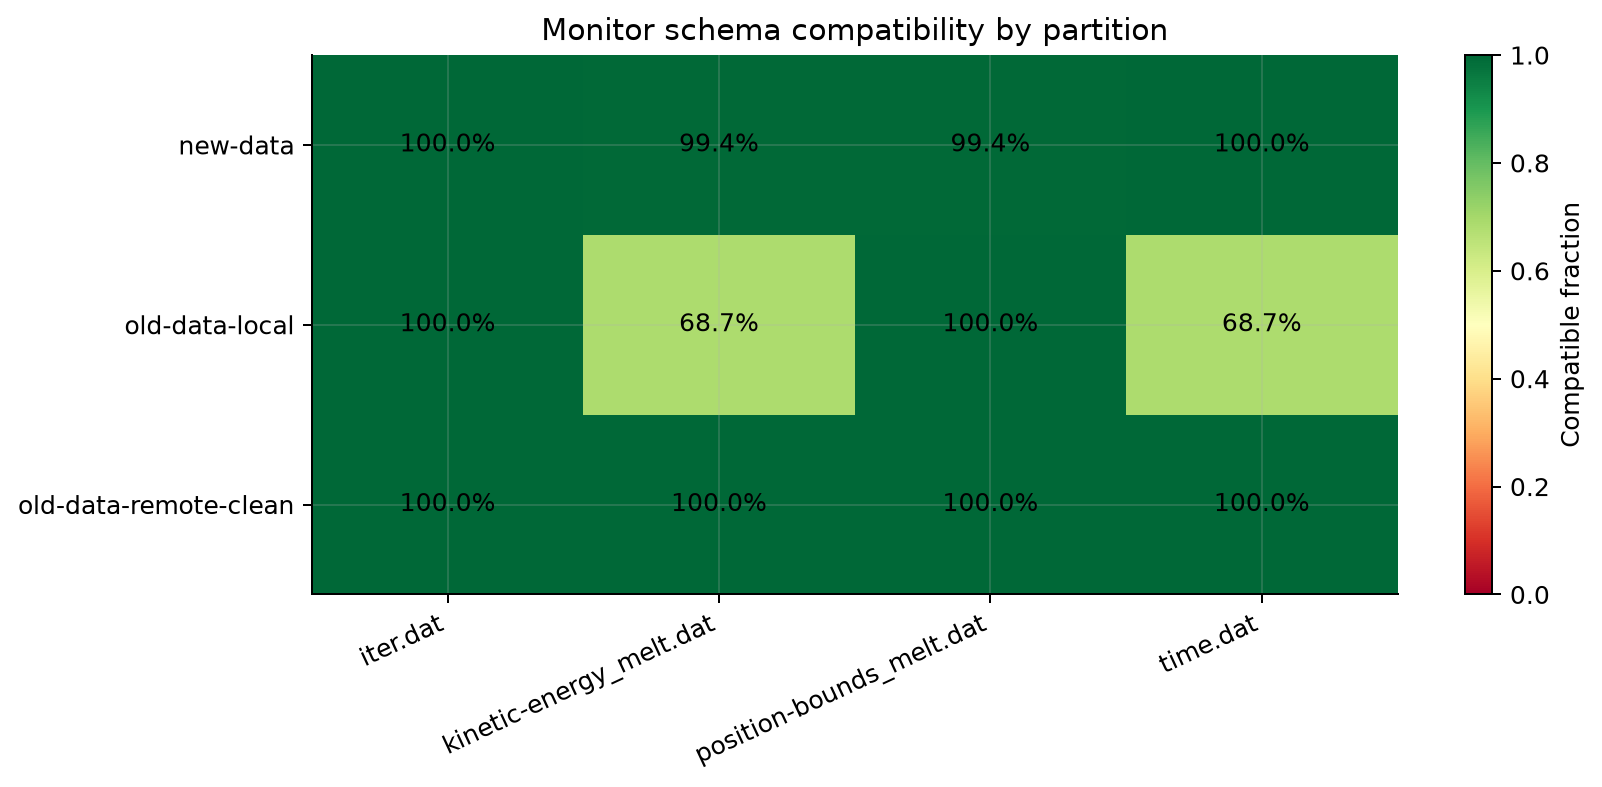

In [3]:
compatibility = pd.read_csv(OUT / "monitor_schema_compatibility.csv")
source_plan = pd.read_csv(OUT / "monitor_source_plan.csv")
domain = pd.read_csv(OUT / "domain_mapping_compatibility.csv")

display(compatibility[[
    "monitor_file", "expected_columns", "source_unit", "reported_unit_or_use",
    "timestep_or_index_interpretation", "physical_semantics",
]].drop_duplicates().sort_values("monitor_file"))
display(
    compatibility.groupby(["partition", "monitor_file"])
    .agg(
        experiments=("experiment_name", "nunique"),
        present=("remote_exists", "sum"),
        schema_compatible=("schema_compatible", "sum"),
        nonfinite_values=("nonfinite_count", "sum"),
    ).reset_index()
)
display(
    source_plan.groupby(["partition", "source_mode"])
    .size().rename("monitor_files").reset_index()
)
display(compatibility[~compatibility["remote_exists"]][[
    "partition", "experiment_name", "monitor_file", "detail"
]])
display(domain[[
    "experiment_name", "week6_simulation_id", "sph_v2_folder_domain_max_m",
    "week6_domain_max_reconstructed_m", "absolute_error_m", "mapping_matches_week6"
]].describe(include="all"))
show_figure("01_monitor_schema_compatibility.png")

**Interpretation.** Present files parse with their Week 6 schemas and their local bytes match the pinned remote Git blobs. **114 monitor files across 57 experiments are absent upstream**, so those experiments fail explicitly. For exact Week 6 identifiers, local bytes are reused only after Git-blob equality. The new domain rule `min(XF, XL) + 12 µm` reproduces the Week 6 domain end for every exact match; the 12 µm is the existing three-particle boundary-wall extension.

## 3A. Supervisor clarification: no-melt 1e38 sentinel

**What was previously flagged?** One present new-data bounds file could not be parsed because its first field was the text `s3.402823e+38`.  
**What did Ioan clarify?** Values around `1e38` are normal solver artifacts indicating that the melt is absent. They are not physical melt coordinates.  
**Why can the simulation continue?** A no-melt row is excluded, but later rows can contain valid finite melt bounds. Therefore one bad no-melt row does not require discarding the whole experiment.  
**What changed?** The parser recognizes only the exact complete field `s3.402823e+38` as the already-known positive no-melt sentinel. The unchanged Week 6 rule then rejects that row because `abs(value) >= 1e30`. No arbitrary letters are stripped, nothing is set to zero, and no interpolation is introduced.  
**Suspicious result.** Any other malformed token being repaired, a sentinel entering a width/depth/height calculation, or an unrelated previously valid target changing.

In [4]:
sentinel_audit = pd.read_csv(OUT / "sentinel_audit.csv")
correction = pd.read_csv(OUT / "supervisor_correction_before_after.csv")
readiness = pd.read_csv(OUT / "new_data_readiness_summary.csv")

raw_example = pd.DataFrame({
    "raw bounds row": [" s3.402823e+38,-3.402823e+38,3.402823e+38,-3.402823e+38,3.402823e+38,-3.402823e+38"],
    "safe interpretation": ["complete no-melt sentinel row; exclude it from finite geometry"],
})
display(raw_example)
display(sentinel_audit[[
    "token", "count", "file_count", "experiment_count", "column_location",
    "numerically_parseable", "proposed_interpretation", "parser_action",
    "evidence_supervisor_clarification",
]])

affected_names = set(
    sentinel_audit.loc[
        sentinel_audit["token"].eq("s3.402823e+38"),
        "files_experiments_affected",
    ].astype(str)
)
affected = correction[
    correction["status_changed"].astype(bool)
    | correction["experiment_name"].isin(affected_names)
]
display(affected[[
    "experiment_name", "partition_before", "target_extraction_valid_before",
    "extraction_failure_reasons_before", "target_extraction_valid_after",
    "extraction_failure_reasons_after", "status_changed",
    "changed_due_to_confirmed_sentinel_rule",
    "previous_valid_target_changed_unexpectedly", "label_context_changed",
]])
display(readiness[readiness["partition"].eq("new-data")])
display(targets[targets["partition"].eq("new-data") & ~targets["target_extraction_valid"]][[
    "experiment_name", "geometry_monitor_available", "geometry_parse_ok",
    "geometry_target_ready", "time_monitor_available",
    "kinetic_energy_monitor_available", "kinetic_energy_parse_ok",
    "kinetic_energy_target_ready", "physical_target_extraction_success",
    "extraction_failure_reason", "label_analysis_ready",
]])

assert sentinel_audit.loc[sentinel_audit["token"].eq("other numeric/textual variants near 1e38"), "count"].eq(0).all()
assert not correction["previous_valid_target_changed_unexpectedly"].astype(bool).any()
assert not correction["label_context_changed"].astype(bool).any()

,raw bounds row,safe interpretation
0,"s3.402823e+38,-3.402823e+38,3.402823e+38,-3.402823e+38,3.402823e+38,-3.402823e+38",complete no-melt sentinel row; exclude it from finite geometry


,token,count,file_count,experiment_count,column_location,numerically_parseable,proposed_interpretation,parser_action,evidence_supervisor_clarification
0,3.402823e+38,24059576,406,406,x_min=8019858; y_min=8019859; z_min=8019859,True,ordinary positive float32-max no-melt sentinel; never a physical minimum coordinate,parse normally; exclude the entire row with the unchanged abs(value)<1e30 rule,Supervisor confirmed ~1e38 means missing melt; 8019858 ordinary complete no-melt rows were ...
1,-3.402823e+38,24060282,406,406,x_max=8020094; y_max=8020094; z_max=8020094,True,ordinary negative float32-max no-melt sentinel; never a physical maximum coordinate,parse normally; exclude the entire row with the unchanged abs(value)<1e30 rule,Supervisor confirmed ~1e38 means missing melt; 235 partial-sentinel rows occur in 1 file(s)...
2,s3.402823e+38,1,1,1,P-447p413798058_VX-0p91078629156_LS-5p3177056457e-05_ST-328p907838563_M-TI64_XI-0p0002_XF-0...,False,exact textual variant of the positive no-melt sentinel,"recognize this exact complete field only as +3.402823e+38, then exclude its row; do not str...","The other five fields in the affected row are the ordinary alternating solver sentinels, fo..."
3,other numeric/textual variants near 1e38,0,0,0,none,not applicable,none,no compatibility rule; any unrelated malformed token remains a parse failure,All present pinned bounds files were parsed; no other near-1e38 numeric value was found and...


,experiment_name,partition_before,target_extraction_valid_before,extraction_failure_reasons_before,target_extraction_valid_after,extraction_failure_reasons_after,status_changed,changed_due_to_confirmed_sentinel_rule,previous_valid_target_changed_unexpectedly,label_context_changed
0,P-447p413798058_VX-0p91078629156_LS-5p3177056457e-05_ST-328p907838563_M-TI64_XI-0p0002_XF-0...,new-data,False,parse error for position-bounds_melt.dat,True,NaN,True,True,False,False


,partition,experiment_count,geometry_monitor_available_count,geometry_parse_ok_count,geometry_target_ready_count,time_monitor_available_count,time_parse_ok_count,time_target_ready_count,iteration_monitor_available_count,iteration_parse_ok_count,iteration_target_ready_count,kinetic_energy_monitor_available_count,kinetic_energy_parse_ok_count,kinetic_energy_target_ready_count,physical_target_extraction_success_count,label_analysis_ready_count
0,new-data,165,164,164,164,165,165,164,165,165,164,164,164,164,164,165


,experiment_name,geometry_monitor_available,geometry_parse_ok,geometry_target_ready,time_monitor_available,kinetic_energy_monitor_available,kinetic_energy_parse_ok,kinetic_energy_target_ready,physical_target_extraction_success,extraction_failure_reason,label_analysis_ready
44,P-204p165012598_VX-0p624752635414_LS-8p54709329997e-05_ST-334p626206985_M-TI64_XI-0p0002_XF...,False,False,False,True,False,False,False,False,missing kinetic-energy_melt.dat; missing position-bounds_melt.dat,True


**Interpretation.** The audit found exactly the three reported raw variants: ordinary positive and negative solver sentinels plus one exact `s3.402823e+38` field; no other near-`1e38` variant was found. The correction changes extraction status for **1** experiment(s). New-data physical-target readiness is now **164/165**. The remaining new-data failure is retained with machine-readable availability and readiness flags because its required monitors are absent; no data were fabricated.

## 4. Active region and T0 reconstruction

**What are we doing?** Audit the selected active interval, T0 endpoints, sample counts, fallback use, and cooling exclusion.  
**Why?** T0 was one of Week 6's most consequential choices and must not drift during repository migration.  
**Question answered.** Does each successful window lie inside valid melt activity and before the 90%-domain cutoff?  
**Suspicious result.** Cooling-only rows, a T0 outside the active interval, too few samples without fallback, or a degenerate active region.

,experiment_name,partition,active_region_start_row_index,active_region_end_row_index,active_region_sample_count,active_region_fraction_of_monitor,T0_start_row_index,T0_end_row_index,T0_sample_count,T0_fallback_last_rows_used,T0_inside_active_region,recording_ends_before_90pct_domain,flag_primary_window_unstable_week6_rule
0,P-102p928146519_VX-0p633805217924_LS-5p29394366699e-05_ST-318p223787128_M-TI64_XI-0p0002_XF...,new-data,15292.0,94731.0,79440.0,0.687197,78840.0,94731.0,15892.0,False,True,False,False
1,P-109p741517589_VX-0p915030812968_LS-7p99759662409e-05_ST-303p804431165_M-TI64_XI-0p0002_XF...,new-data,10775.0,65606.0,54832.0,0.474325,54636.0,65606.0,10971.0,False,True,False,False
2,P-111p098510779_VX-0p492021331775_LS-4p80108469254e-05_ST-345p911753718_M-TI64_XI-0p0002_XF...,new-data,19525.0,115599.0,96075.0,0.831099,96382.0,115599.0,19218.0,False,True,True,False
3,P-113p729503671_VX-0p646987288946_LS-8p28088886776e-05_ST-328p878079062_M-TI64_XI-0p0002_XF...,new-data,14851.0,92800.0,77950.0,0.674308,77207.0,92800.0,15594.0,False,True,False,False
4,P-115p973342836_VX-0p629021136955_LS-5p81694798744e-05_ST-308p264473639_M-TI64_XI-0p0002_XF...,new-data,15167.0,95452.0,80286.0,0.694516,79392.0,95452.0,16061.0,False,True,False,False
5,P-117p204089079_VX-0p299188895548_LS-6p61946140465e-05_ST-399p004242061_M-TI64_XI-0p0002_XF...,new-data,30904.0,115599.0,84696.0,0.732664,98660.0,115599.0,16940.0,False,True,True,False
6,P-118p239150472_VX-0p728951155133_LS-5p59862781201e-05_ST-395p421202378_M-TI64_XI-0p0002_XF...,new-data,13130.0,82362.0,69233.0,0.598901,68512.0,82362.0,13851.0,False,True,False,False
7,P-119p523515535_VX-0p859779155666_LS-6p70931710444e-05_ST-392p874711106_M-TI64_XI-0p0002_XF...,new-data,11166.0,69824.0,58659.0,0.507431,58088.0,69824.0,11737.0,False,True,False,False
8,P-120p079917874_VX-0p610410046914_LS-8p29242579558e-05_ST-398p6729924_M-TI64_XI-0p0002_XF-0...,new-data,15499.0,98363.0,82865.0,0.716825,81788.0,98363.0,16576.0,False,True,False,False
9,P-120p906267006_VX-0p64748664338_LS-6p03748750968e-05_ST-359p518818343_M-TI64_XI-0p0002_XF-...,new-data,14660.0,92729.0,78070.0,0.675346,77112.0,92729.0,15618.0,False,True,False,False


,active_region_sample_count,active_region_fraction_of_monitor,T0_sample_count
count,350.000000,350.000000,350.000000
mean,74828.265714,0.677412,14969.105714
std,15629.652410,0.150593,3124.945851
min,25621.000000,0.372420,5124.000000
25%,60051.500000,0.534027,12015.250000
50%,75322.000000,0.693391,15068.500000
75%,89375.750000,0.801535,17876.750000
max,99038.000000,0.998910,19811.000000


,diagnostic,experiments
0,T0 fallback used,0
1,T0 outside active region,-700
2,cooling rows selected,0
3,Week 6 CV instability flag,16
4,recording ended before cutoff,141


**02_active_region_diagnostics.png**

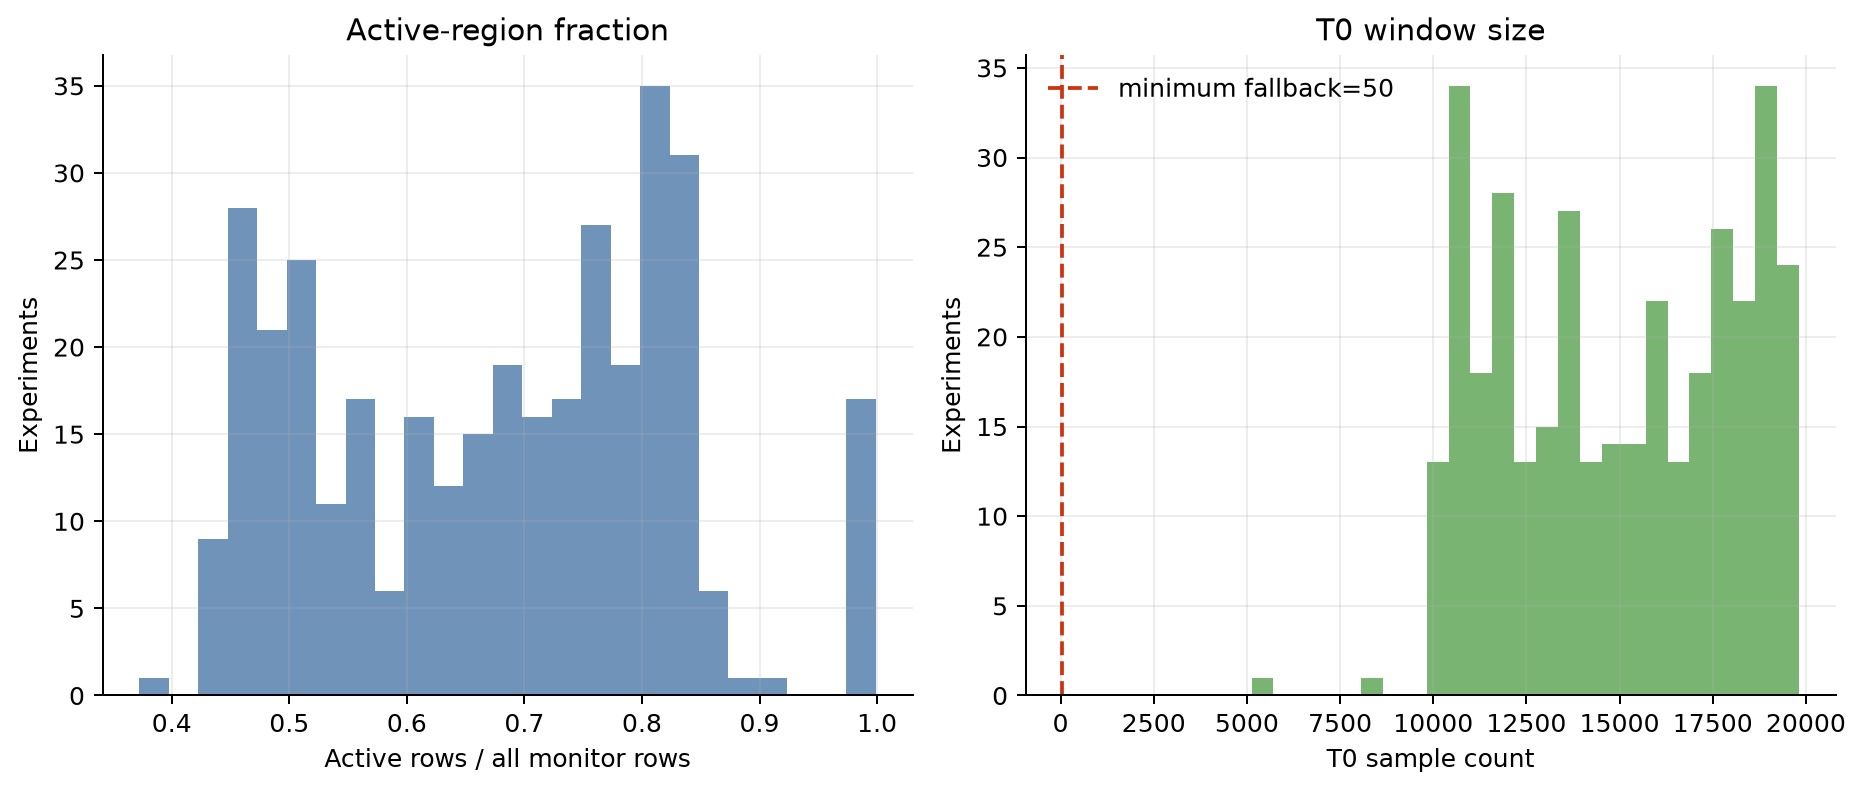

In [5]:
active = pd.read_csv(OUT / "active_region_diagnostics.csv")
valid_active = active[active["target_extraction_valid"]]
valid_targets = targets[targets["target_extraction_valid"]]
display(valid_active[[
    "experiment_name", "partition", "active_region_start_row_index",
    "active_region_end_row_index", "active_region_sample_count",
    "active_region_fraction_of_monitor", "T0_start_row_index", "T0_end_row_index",
    "T0_sample_count", "T0_fallback_last_rows_used", "T0_inside_active_region",
    "recording_ends_before_90pct_domain", "flag_primary_window_unstable_week6_rule",
]].head(12))
display(valid_active[[
    "active_region_sample_count", "active_region_fraction_of_monitor", "T0_sample_count"
]].describe())
display(pd.DataFrame({
    "diagnostic": ["T0 fallback used", "T0 outside active region", "cooling rows selected", "Week 6 CV instability flag", "recording ended before cutoff"],
    "experiments": [
        int(valid_active["T0_fallback_last_rows_used"].sum()),
        int((~valid_active["T0_inside_active_region"]).sum()),
        int(valid_targets["cooling_rows_selected_in_T0"].sum()),
        int(valid_active["flag_primary_window_unstable_week6_rule"].sum()),
        int(valid_active["recording_ends_before_90pct_domain"].sum()),
    ],
}))
show_figure("02_active_region_diagnostics.png")

**Interpretation.** All **350 successful extractions** keep T0 inside the Week 6 active interval and select zero cooling-only rows. The target table preserves fallback, short-active, recording-end, and within-window CV flags per experiment. These diagnostics test implementation and stability; they do not redefine T0.

## 5. Representative physical time series

**What are we doing?** Plot width, depth, total height, and kinetic energy for deterministic representatives covering every partition, Keyhole/non-Keyhole status, low/high LS, low/high ST, and a suspicious depth case.  
**Why?** Scalar validations can pass while a selected window still looks physically implausible.  
**Question answered.** Do the active/T0 overlays and median targets behave as intended across ordinary and edge cases?  
**Suspicious result.** Cherry-picking only clean traces, hiding the cutoff, or failing to show a selected-median line.

,experiment_name,partition,has_keyhole,selection_reason
0,P-367p938083726_VX-0p695829187084_LS-4p35800266683e-05_ST-364p389584597_M-TI64_XI-0p0002_XF...,new-data,True,new-data; Keyhole; median T0 depth
1,P-273p06384474_VX-0p951903552318_LS-4p77154604482e-05_ST-314p535783501_M-TI64_XI-0p0002_XF-...,new-data,False,new-data; non-Keyhole; median T0 depth
2,P-140p119887795_VX-0p222892199661_LS-4p5e-05_ST-300_M-TI64_XI--0p0002_XF-0p0012_XL-0p0014_T...,old-data-local,True,old-data-local; Keyhole; median T0 depth
3,P-196p954129245_VX-0p972458485112_LS-5p85340423111e-05_ST-310p387913302_M-TI64_XI-0p0002_XF...,old-data-local,False,old-data-local; non-Keyhole; median T0 depth
4,P-240p318887809_VX-0p361018894241_LS-4p85509578057e-05_ST-398p513006139_M-TI64_XI-0p0002_XF...,old-data-remote-clean,True,old-data-remote-clean; Keyhole; median T0 depth
5,P-121p661876009_VX-0p281641526906_LS-7p16631028882e-05_ST-330p429005364_M-TI64_XI-0p0002_XF...,old-data-remote-clean,False,old-data-remote-clean; non-Keyhole; median T0 depth
6,P-355p313197397_VX-0p977425276438_LS-4p00293473664e-05_ST-317p253821106_M-TI64_XI-0p0002_XF...,new-data,True,lowest LS
7,P-80p5741190929_VX-0p403249617425_LS-8p97039861056e-05_ST-397p637850573_M-TI64_XI-0p0002_XF...,old-data-remote-clean,False,highest LS
8,P-101p127472137_VX-0p52394730996_LS-4p5e-05_ST-300_M-TI64_XI--0p0002_XF-0p0012_XL-0p0014_TE...,old-data-local,False,lowest ST
9,P-326p931045044_VX-0p255856443683_LS-6p48737236991e-05_ST-399p817710522_M-TI64_XI-0p0002_XF...,new-data,True,highest ST


,figure,question,experiment_name
12,representative_01_5eeb2e6aeb.png,Does extraction look plausible for new-data; Keyhole; median T0 depth?,P-367p938083726_VX-0p695829187084_LS-4p35800266683e-05_ST-364p389584597_M-TI64_XI-0p0002_XF...
13,representative_02_9dc739a4ab.png,Does extraction look plausible for new-data; non-Keyhole; median T0 depth?,P-273p06384474_VX-0p951903552318_LS-4p77154604482e-05_ST-314p535783501_M-TI64_XI-0p0002_XF-...
14,representative_03_f5f5a83cc1.png,Does extraction look plausible for old-data-local; Keyhole; median T0 depth?,P-140p119887795_VX-0p222892199661_LS-4p5e-05_ST-300_M-TI64_XI--0p0002_XF-0p0012_XL-0p0014_T...
15,representative_04_5986271222.png,Does extraction look plausible for old-data-local; non-Keyhole; median T0 depth?,P-196p954129245_VX-0p972458485112_LS-5p85340423111e-05_ST-310p387913302_M-TI64_XI-0p0002_XF...
16,representative_05_fc1cea6b44.png,Does extraction look plausible for old-data-remote-clean; Keyhole; median T0 depth?,P-240p318887809_VX-0p361018894241_LS-4p85509578057e-05_ST-398p513006139_M-TI64_XI-0p0002_XF...
17,representative_06_dbb434ccf1.png,Does extraction look plausible for old-data-remote-clean; non-Keyhole; median T0 depth?,P-121p661876009_VX-0p281641526906_LS-7p16631028882e-05_ST-330p429005364_M-TI64_XI-0p0002_XF...
18,representative_07_a9a3a78b56.png,Does extraction look plausible for lowest LS?,P-355p313197397_VX-0p977425276438_LS-4p00293473664e-05_ST-317p253821106_M-TI64_XI-0p0002_XF...
19,representative_08_878e896c75.png,Does extraction look plausible for highest LS?,P-80p5741190929_VX-0p403249617425_LS-8p97039861056e-05_ST-397p637850573_M-TI64_XI-0p0002_XF...
20,representative_09_4d85567eeb.png,Does extraction look plausible for lowest ST?,P-101p127472137_VX-0p52394730996_LS-4p5e-05_ST-300_M-TI64_XI--0p0002_XF-0p0012_XL-0p0014_TE...
21,representative_10_ee10d29872.png,Does extraction look plausible for highest ST?,P-326p931045044_VX-0p255856443683_LS-6p48737236991e-05_ST-399p817710522_M-TI64_XI-0p0002_XF...


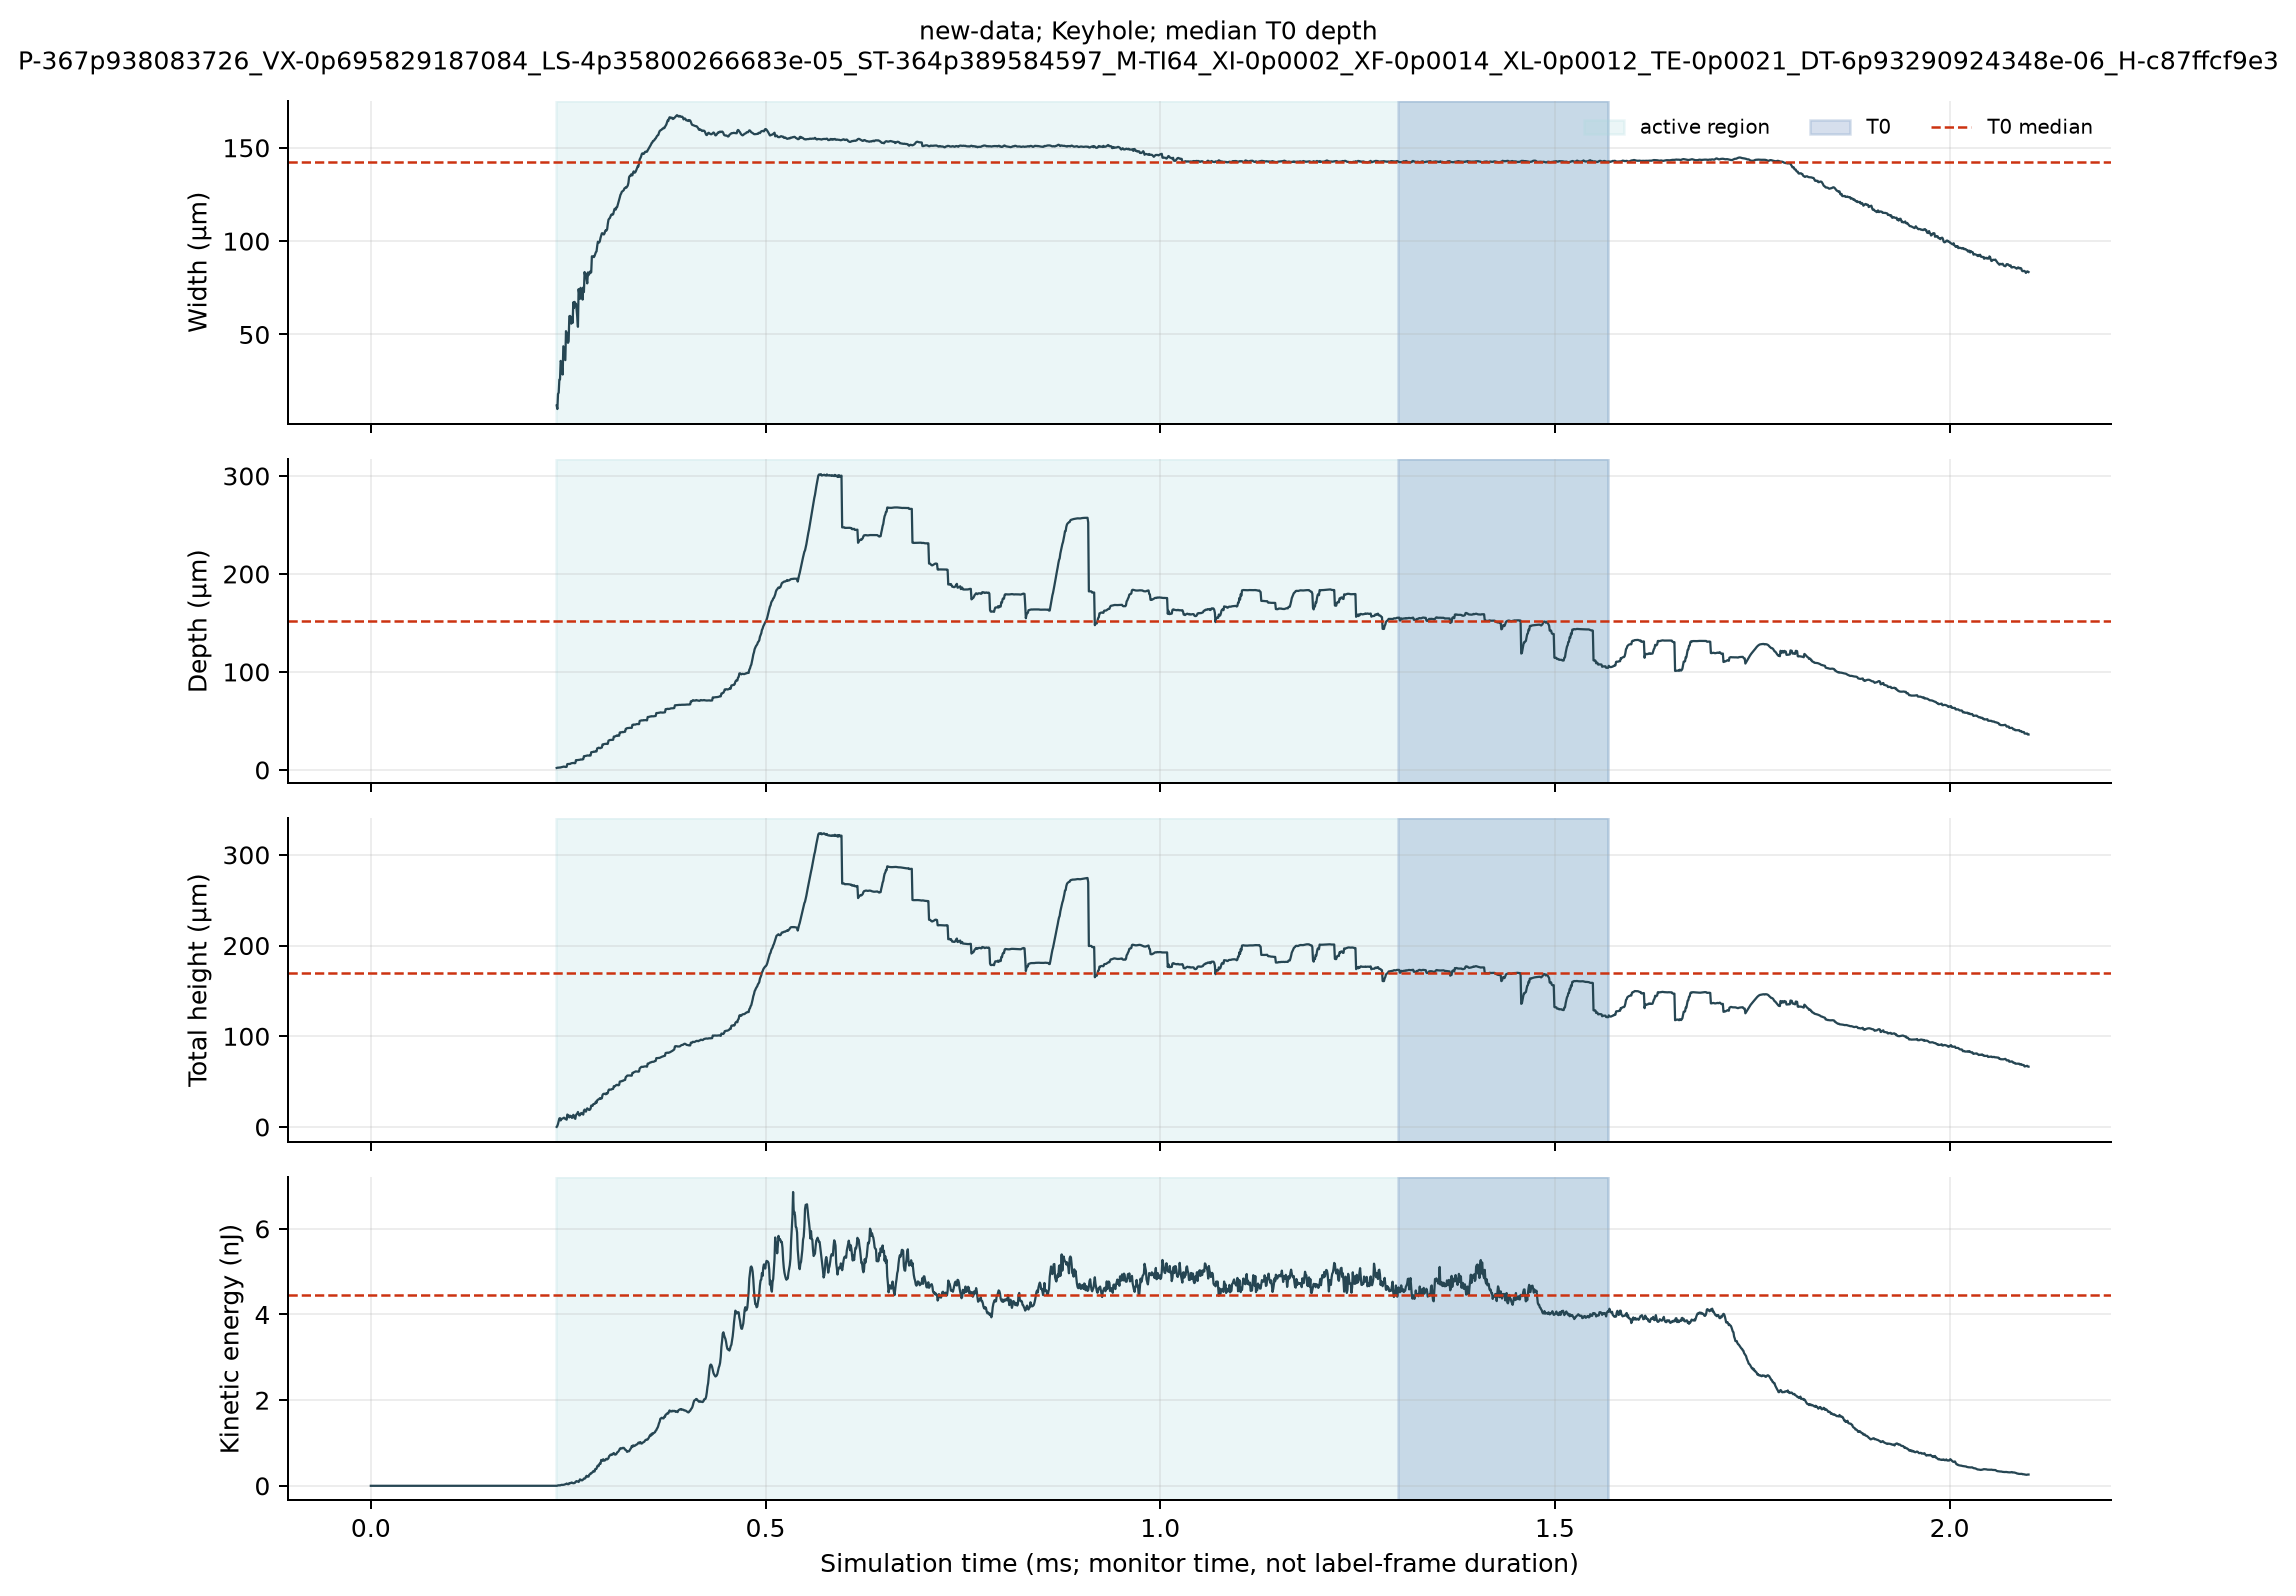

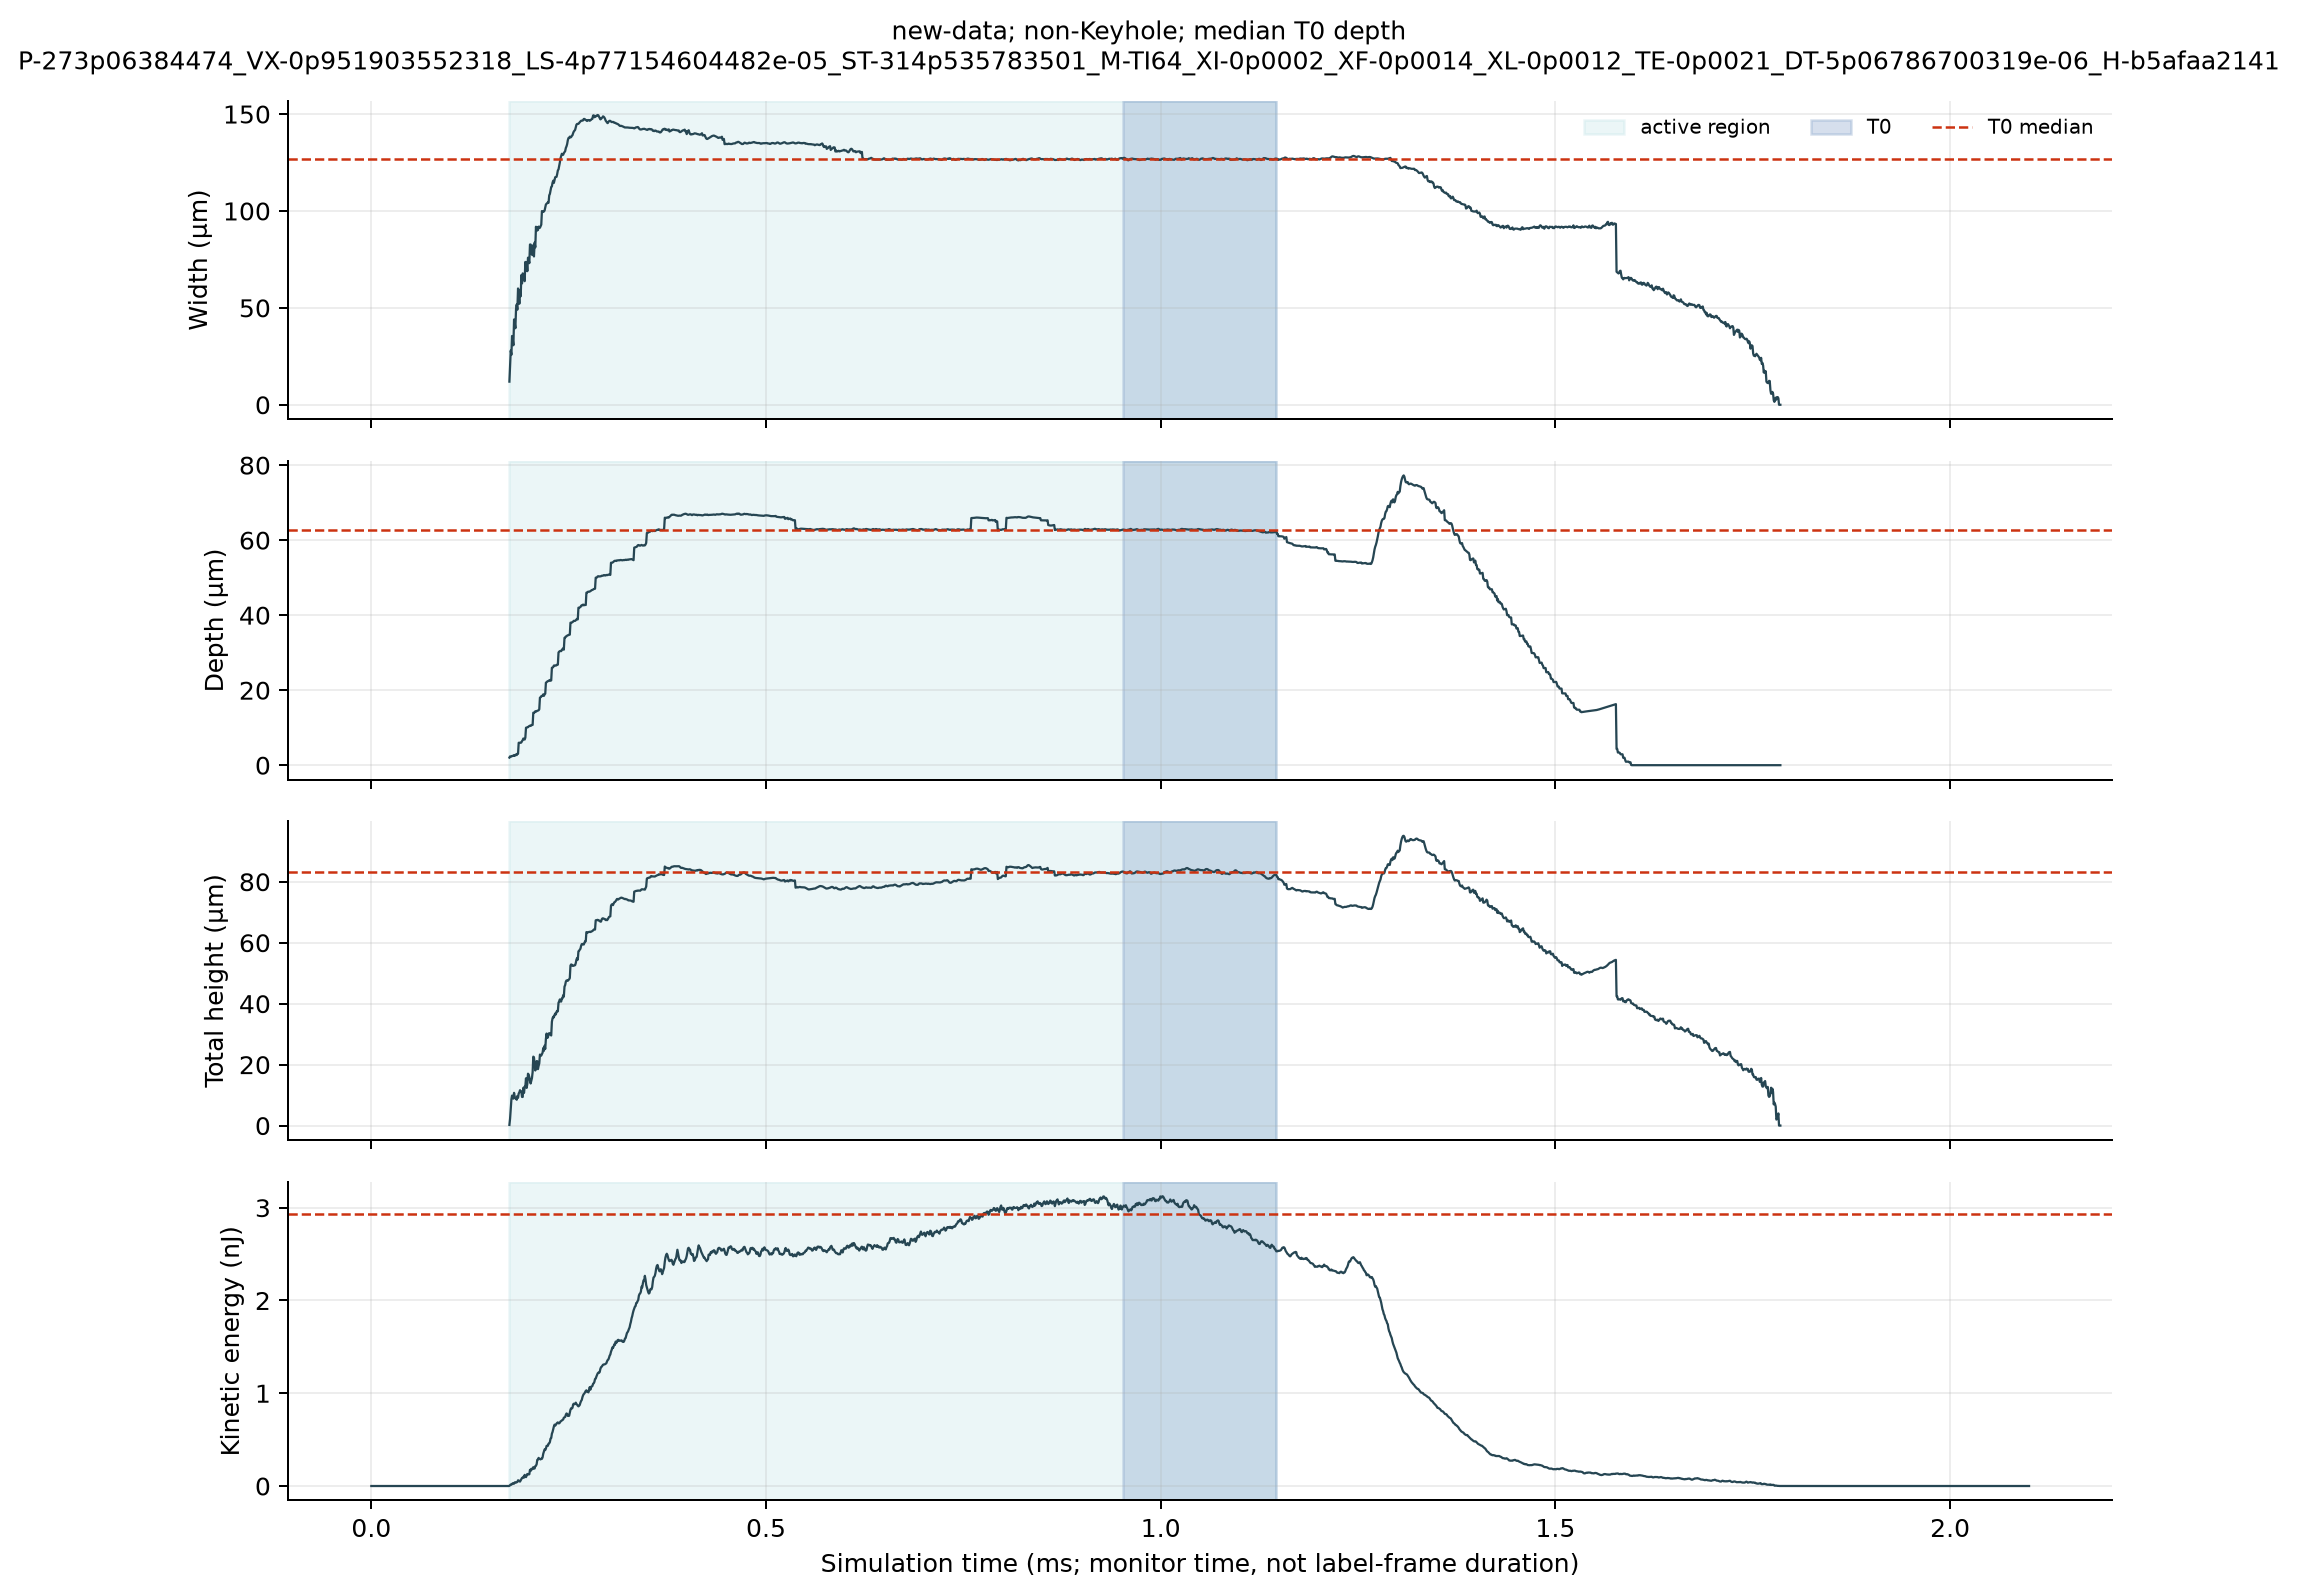

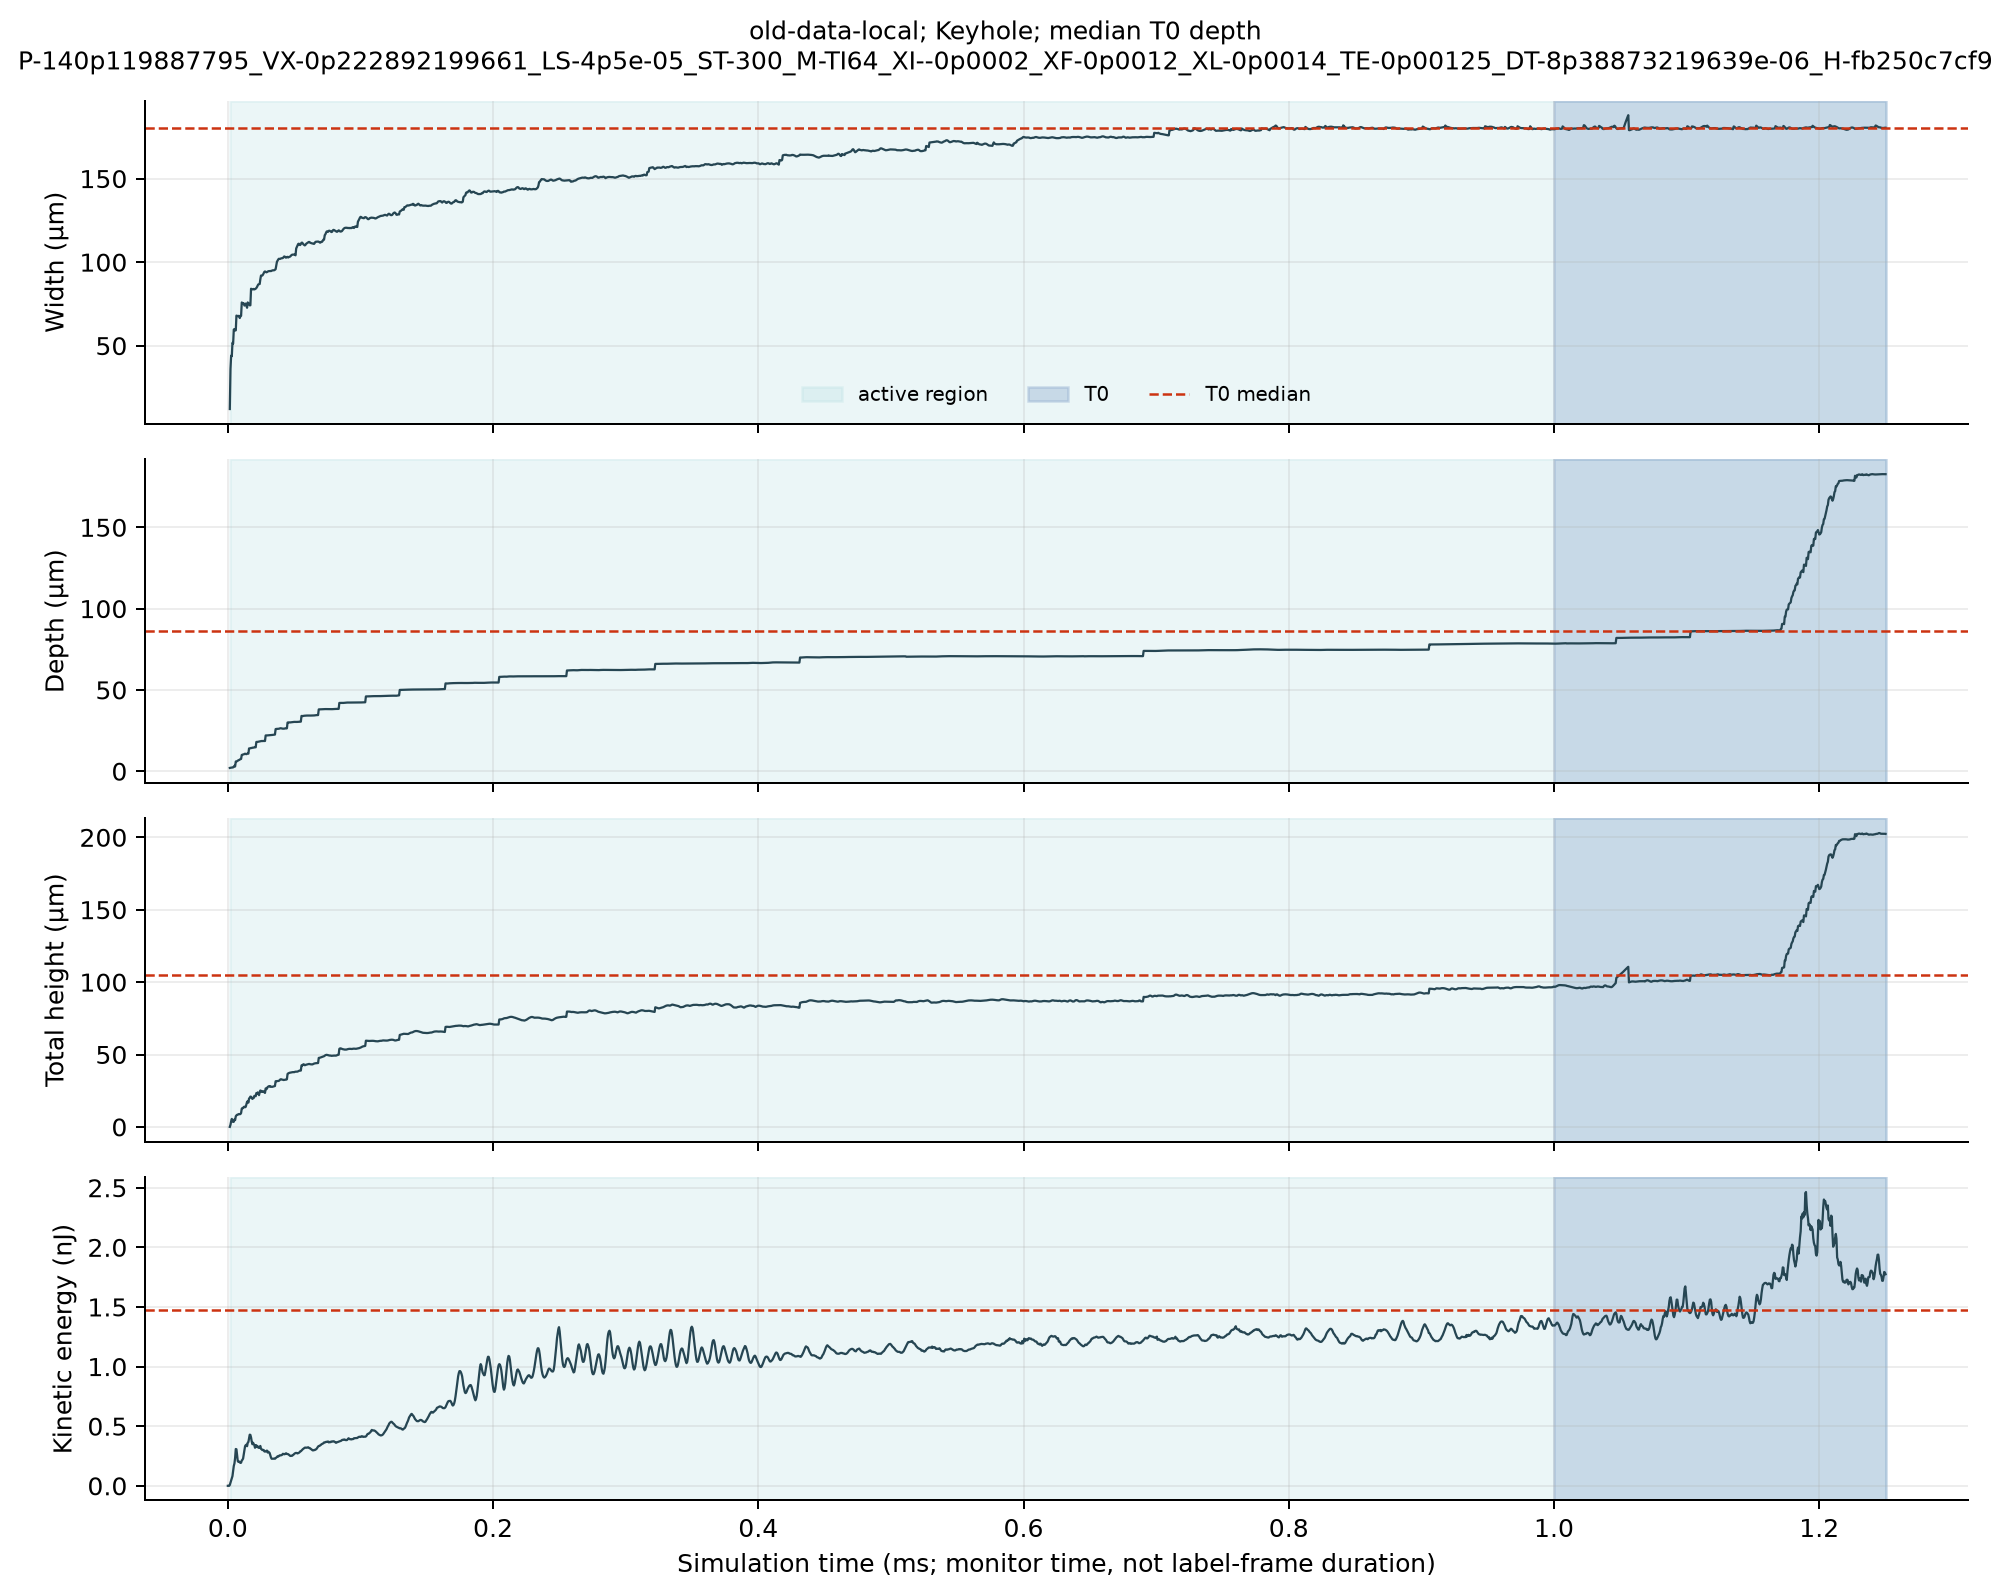

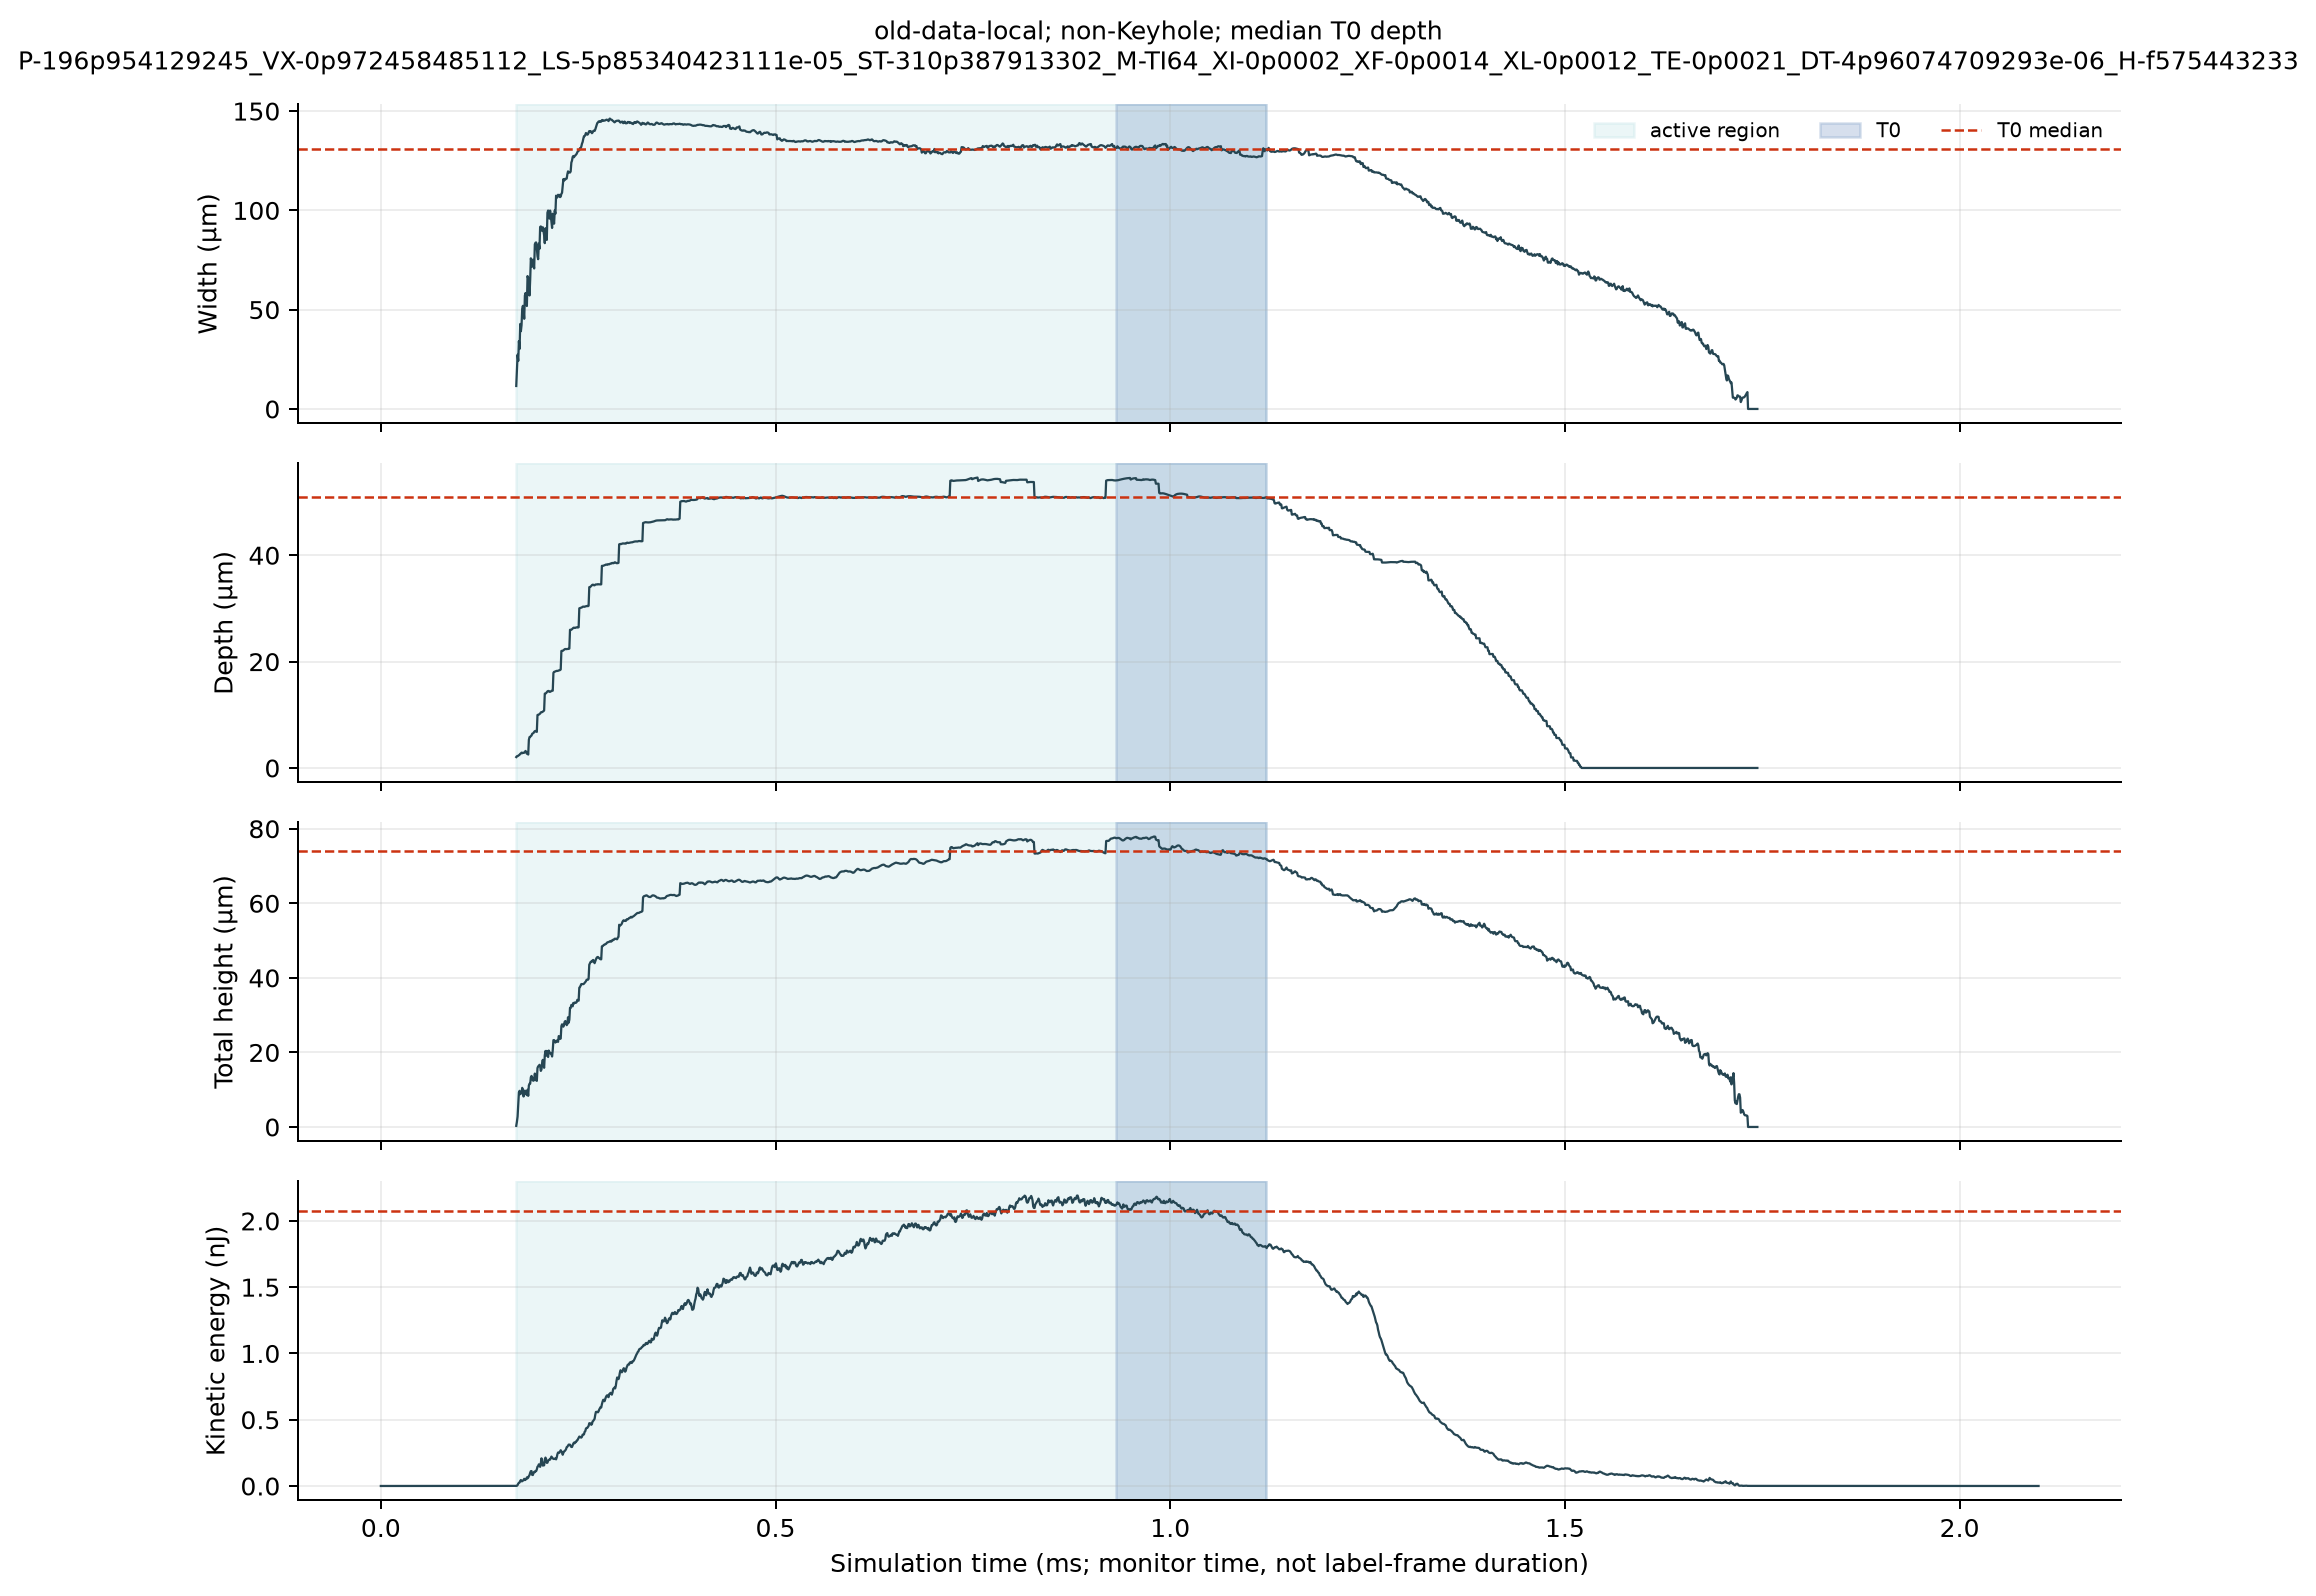

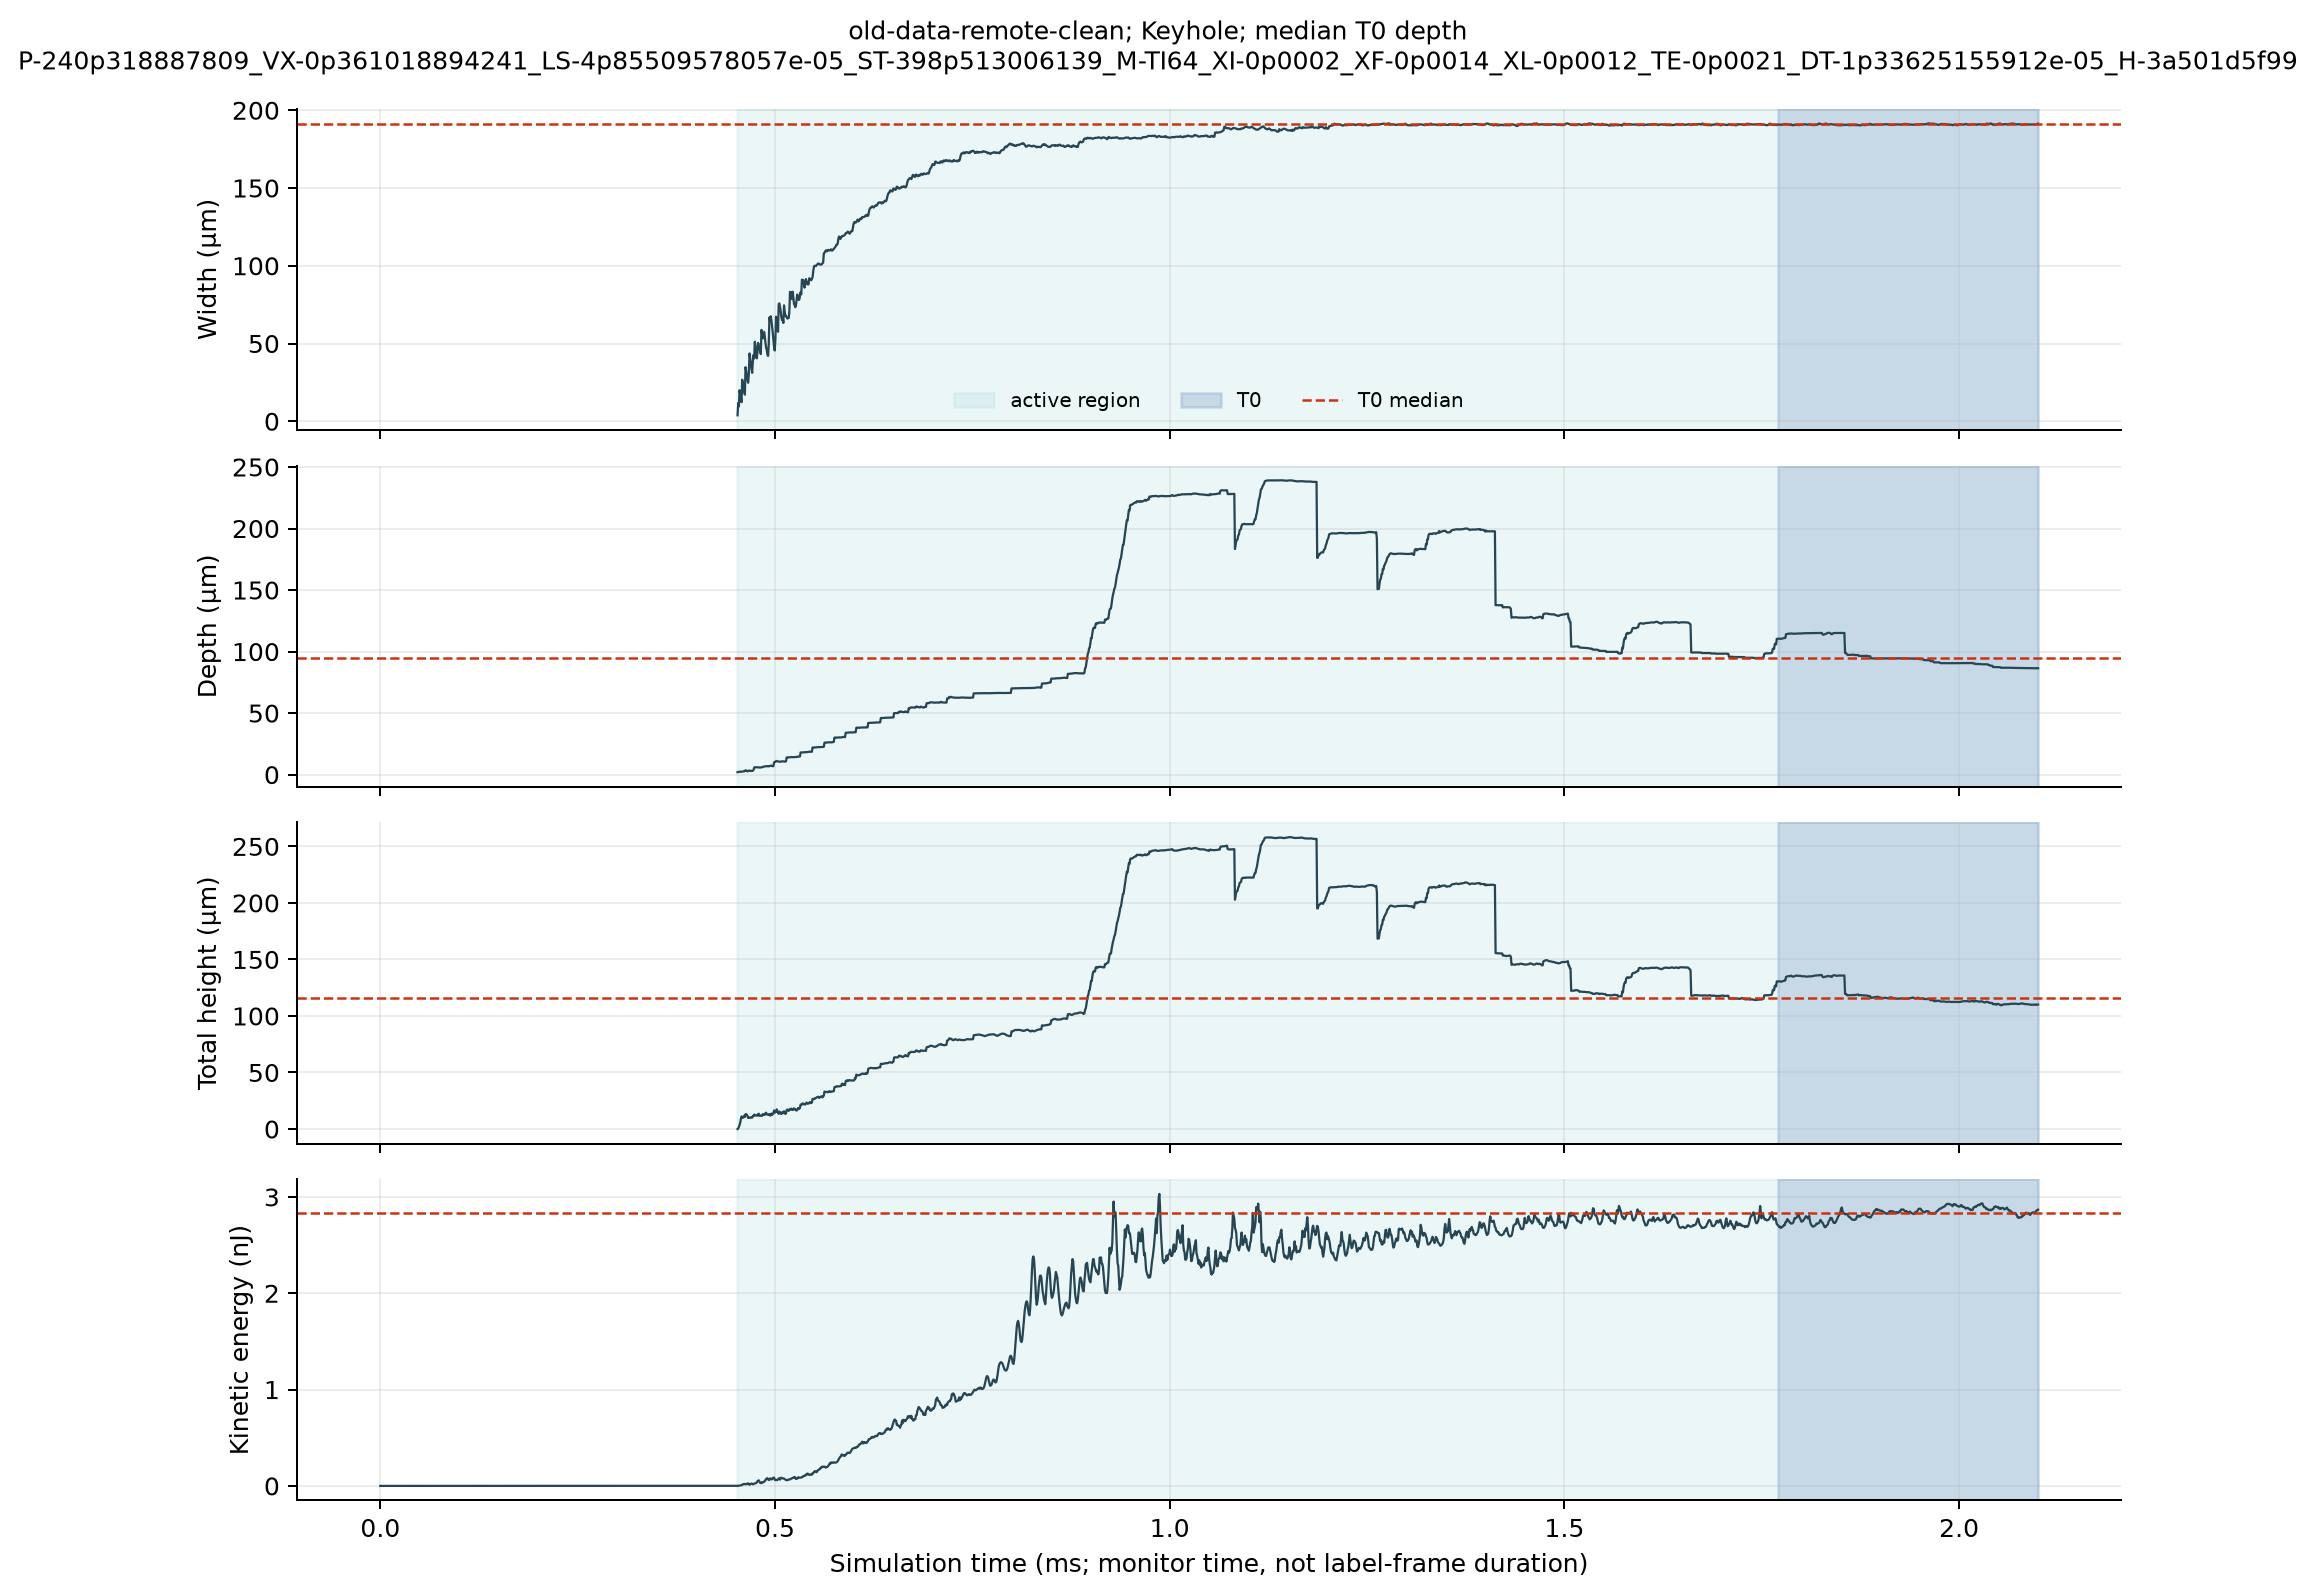

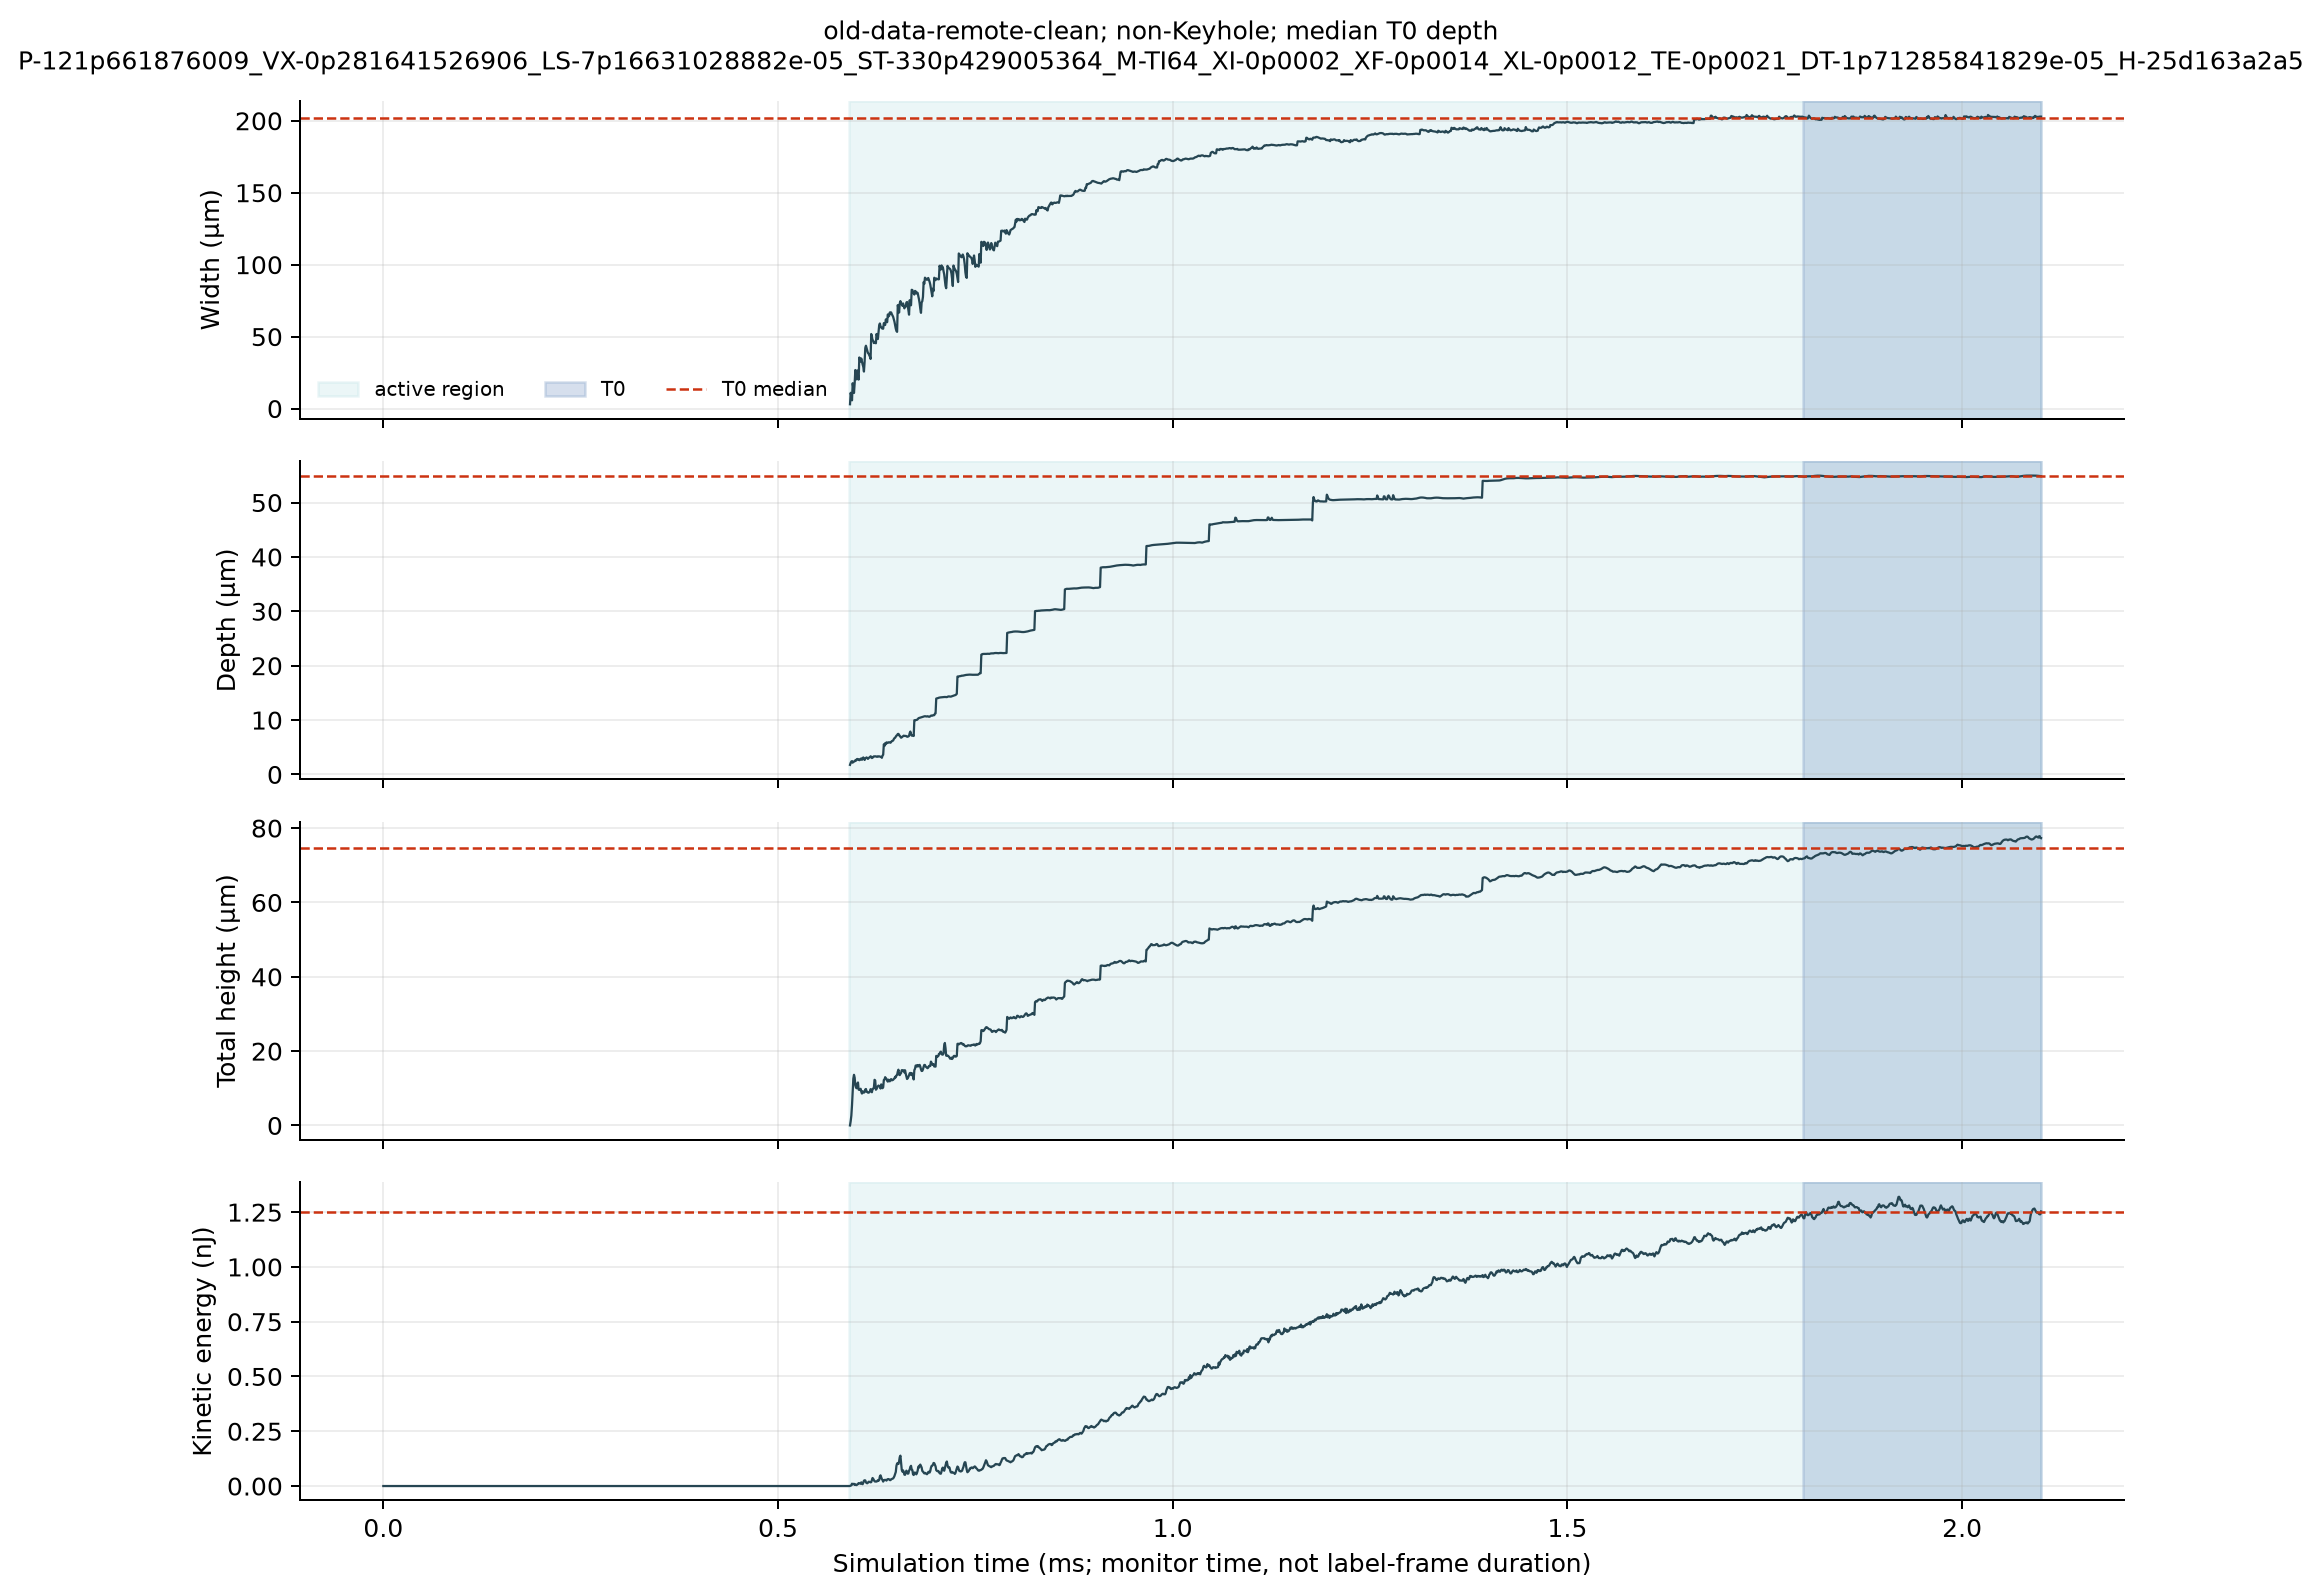

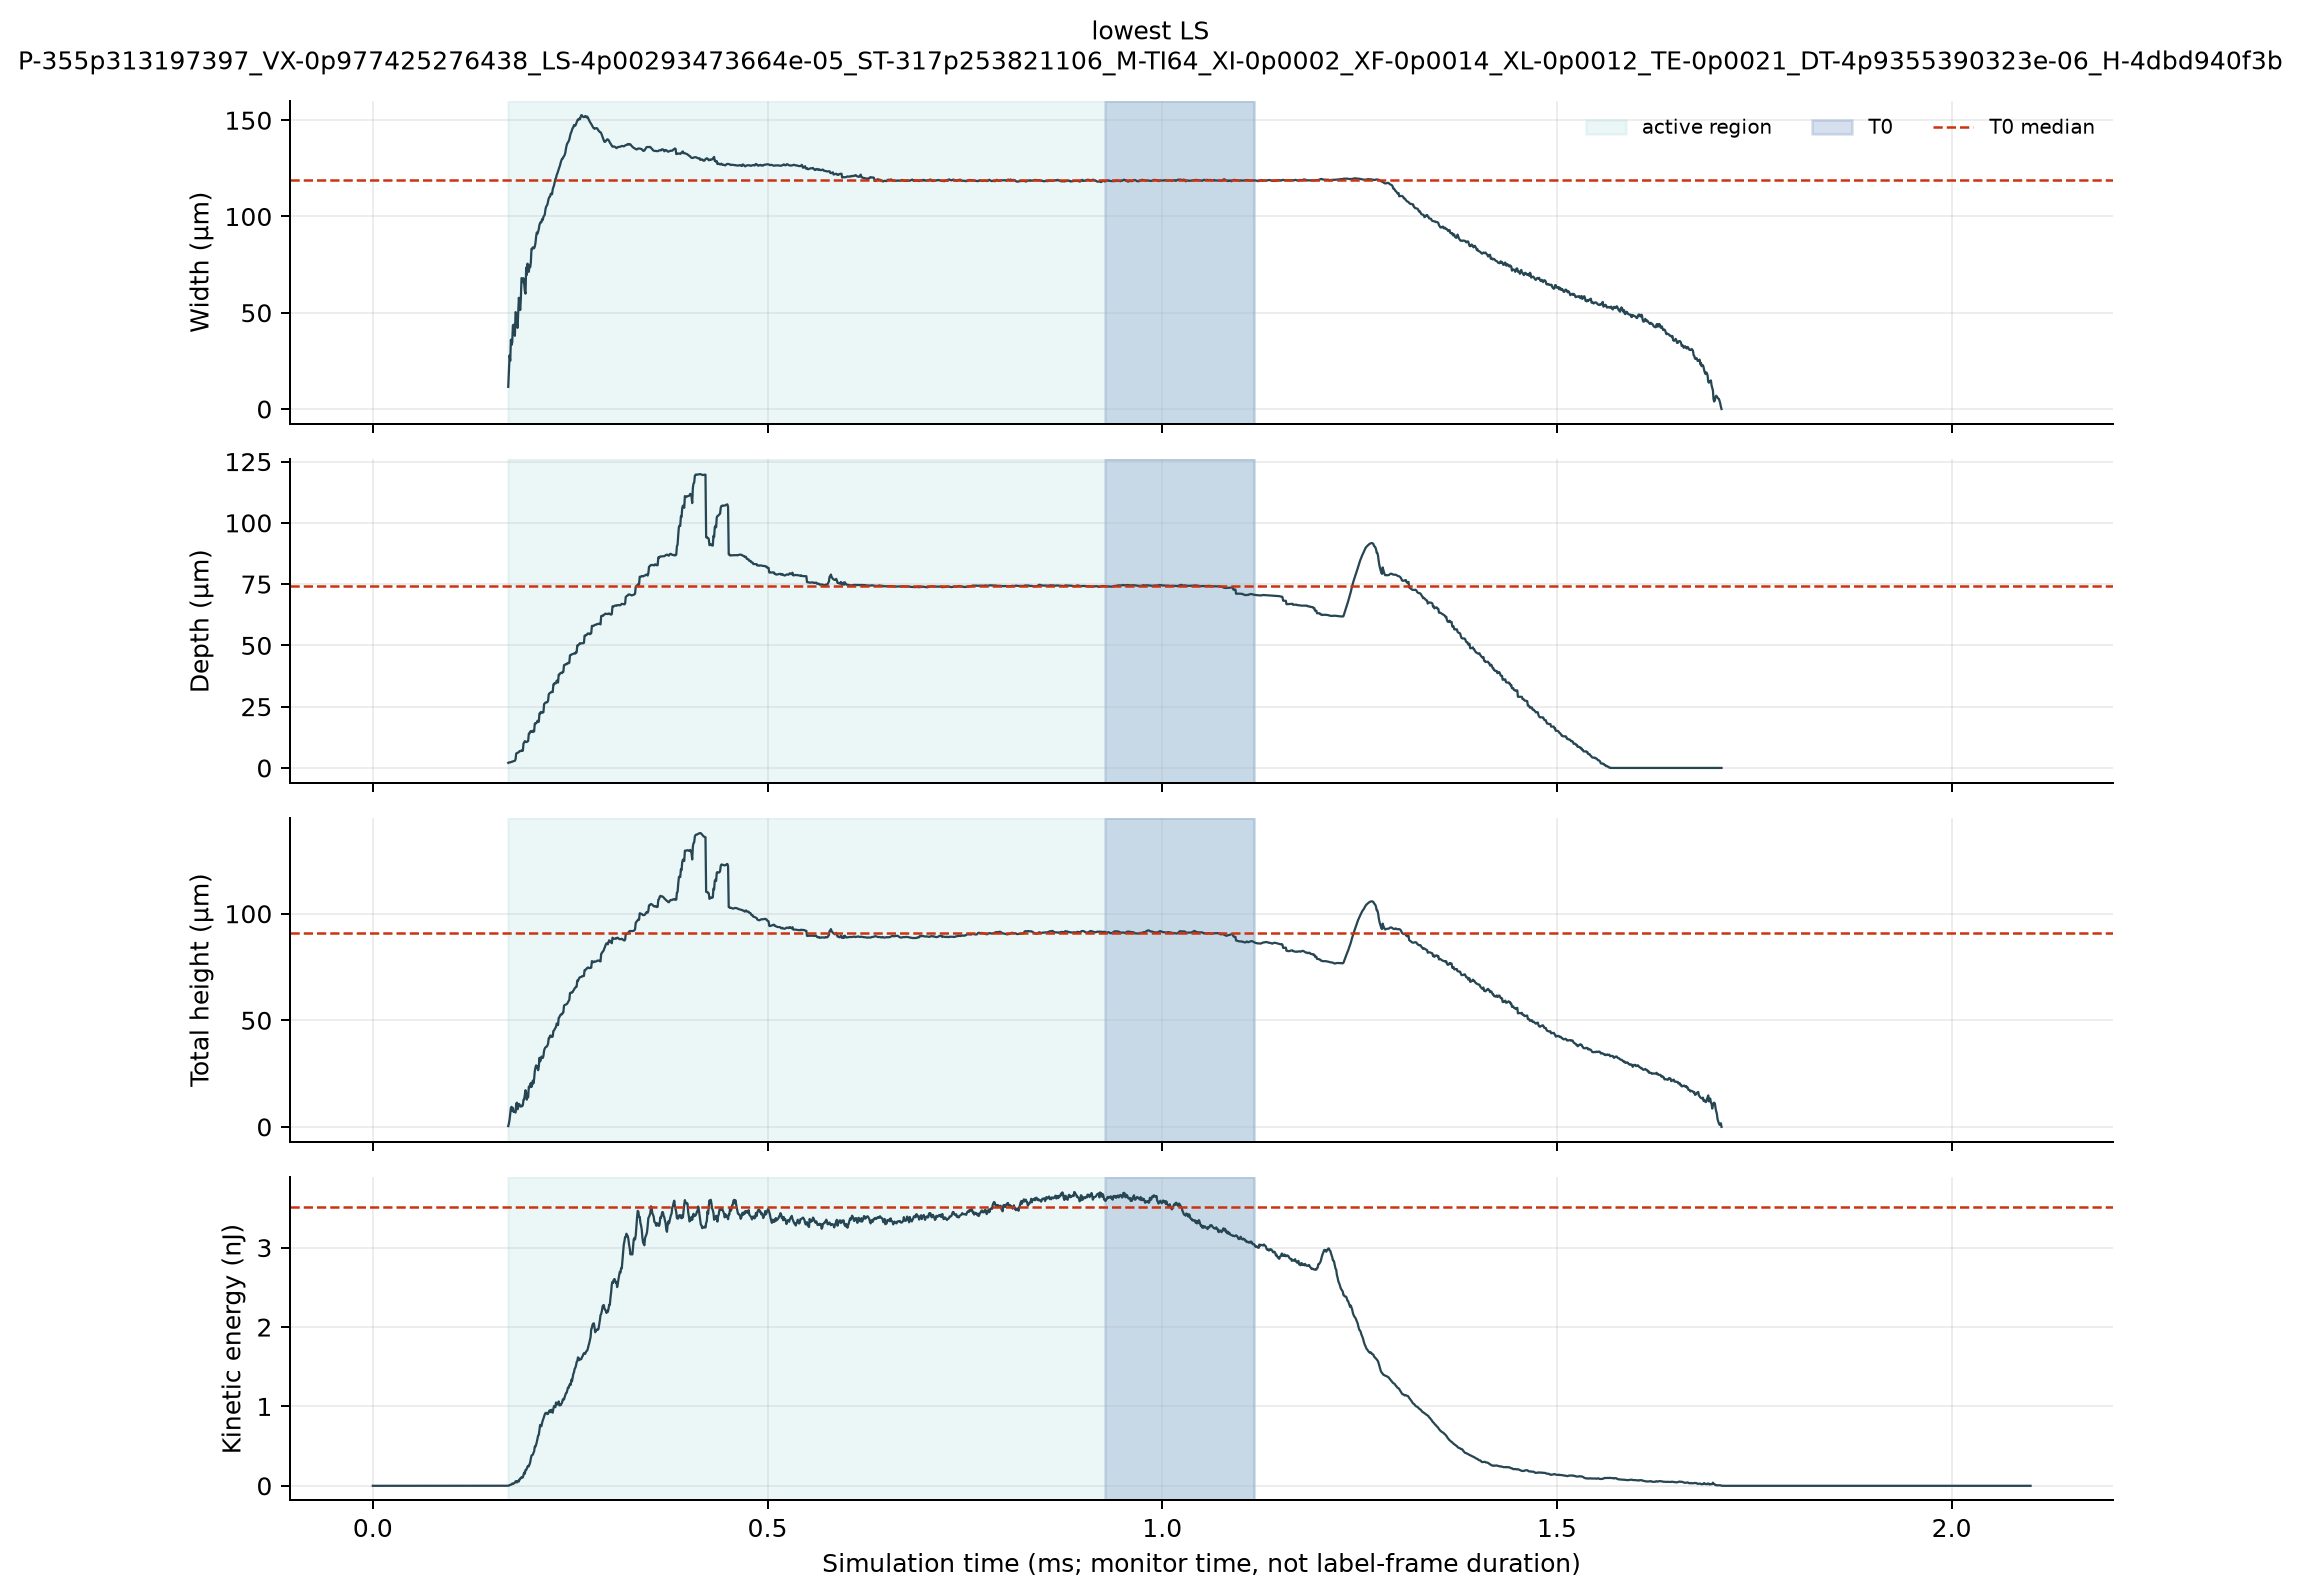

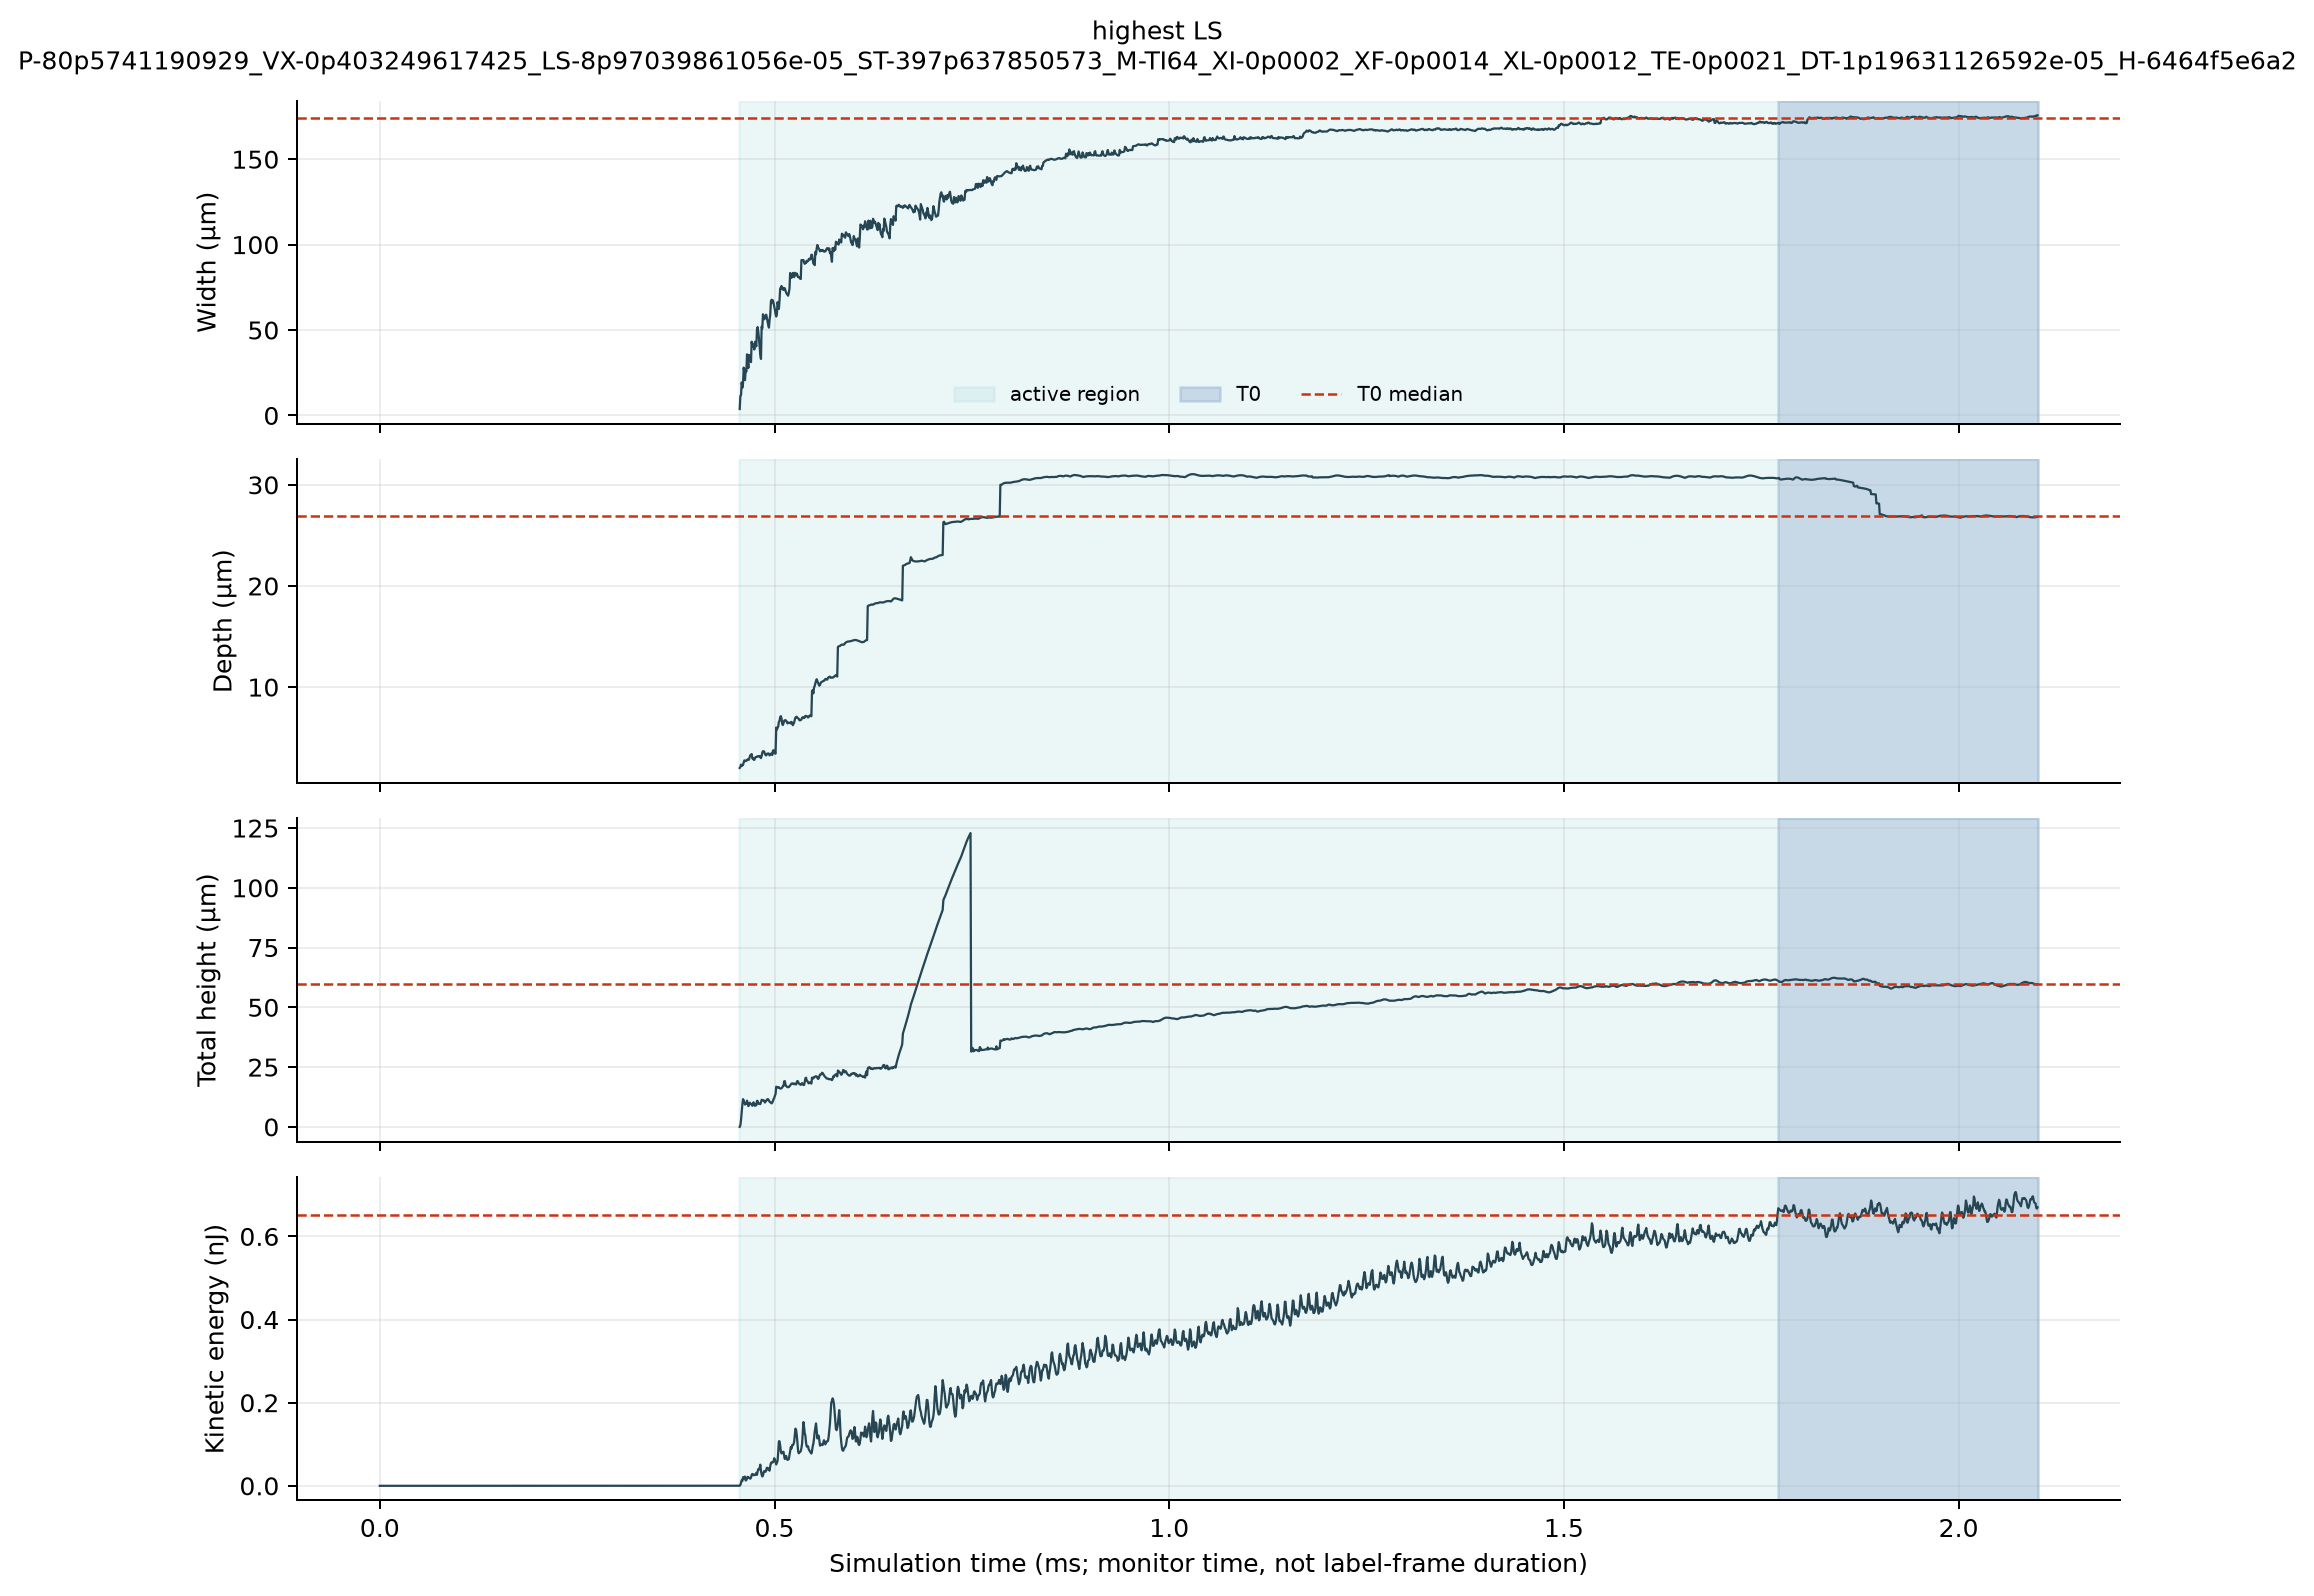

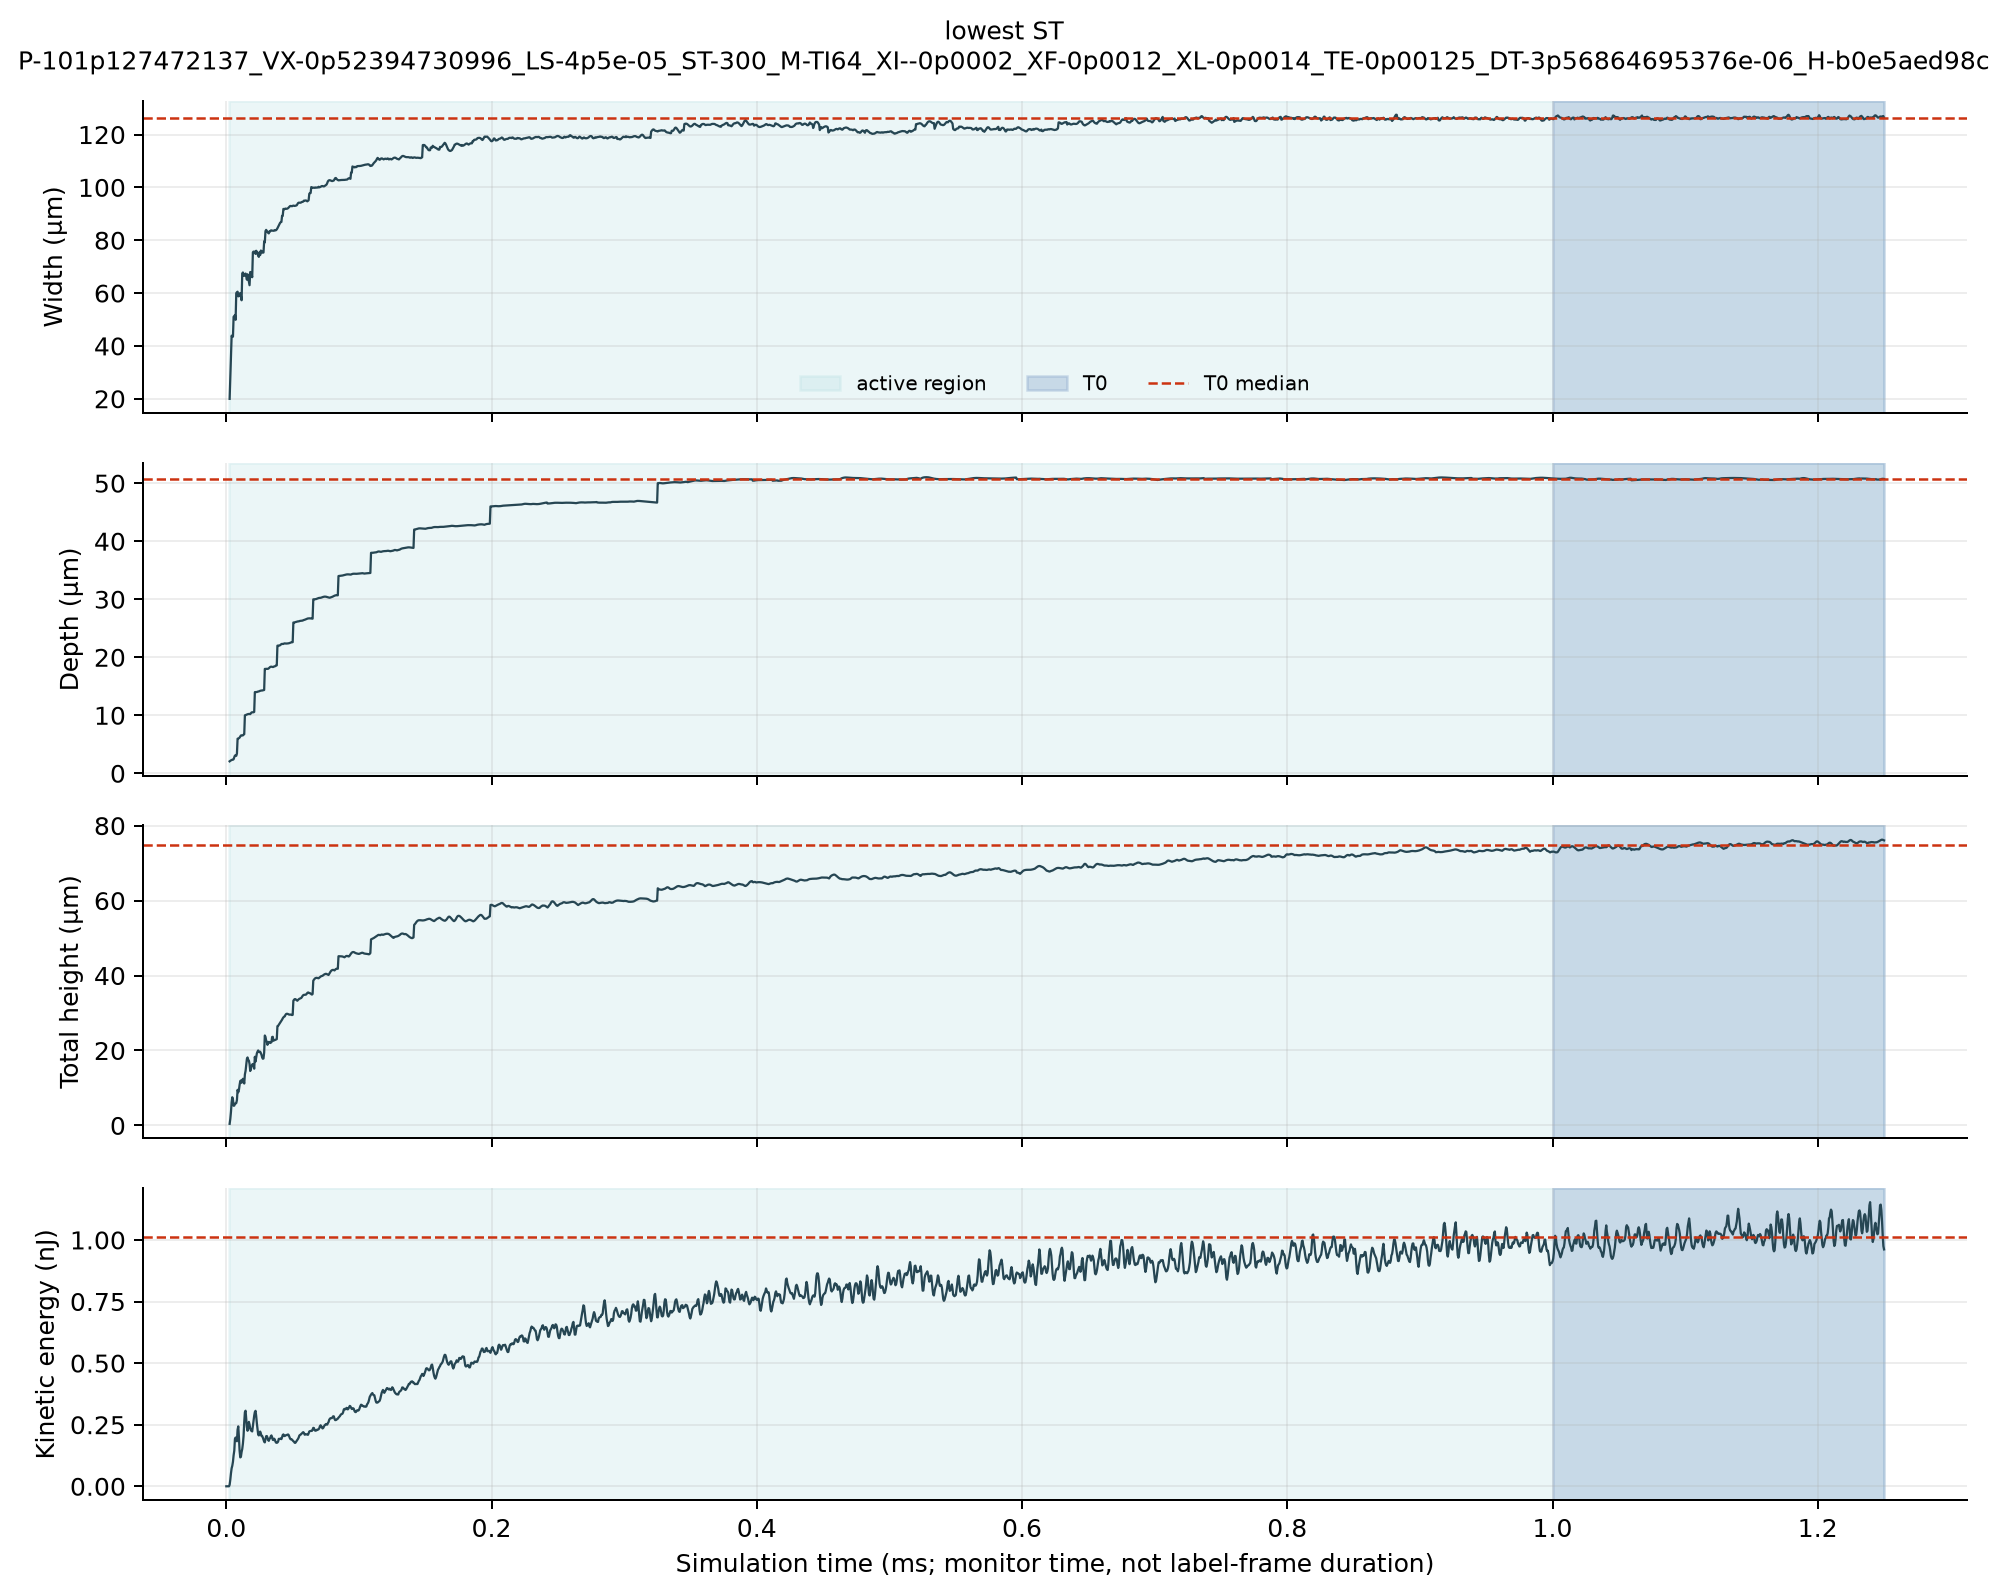

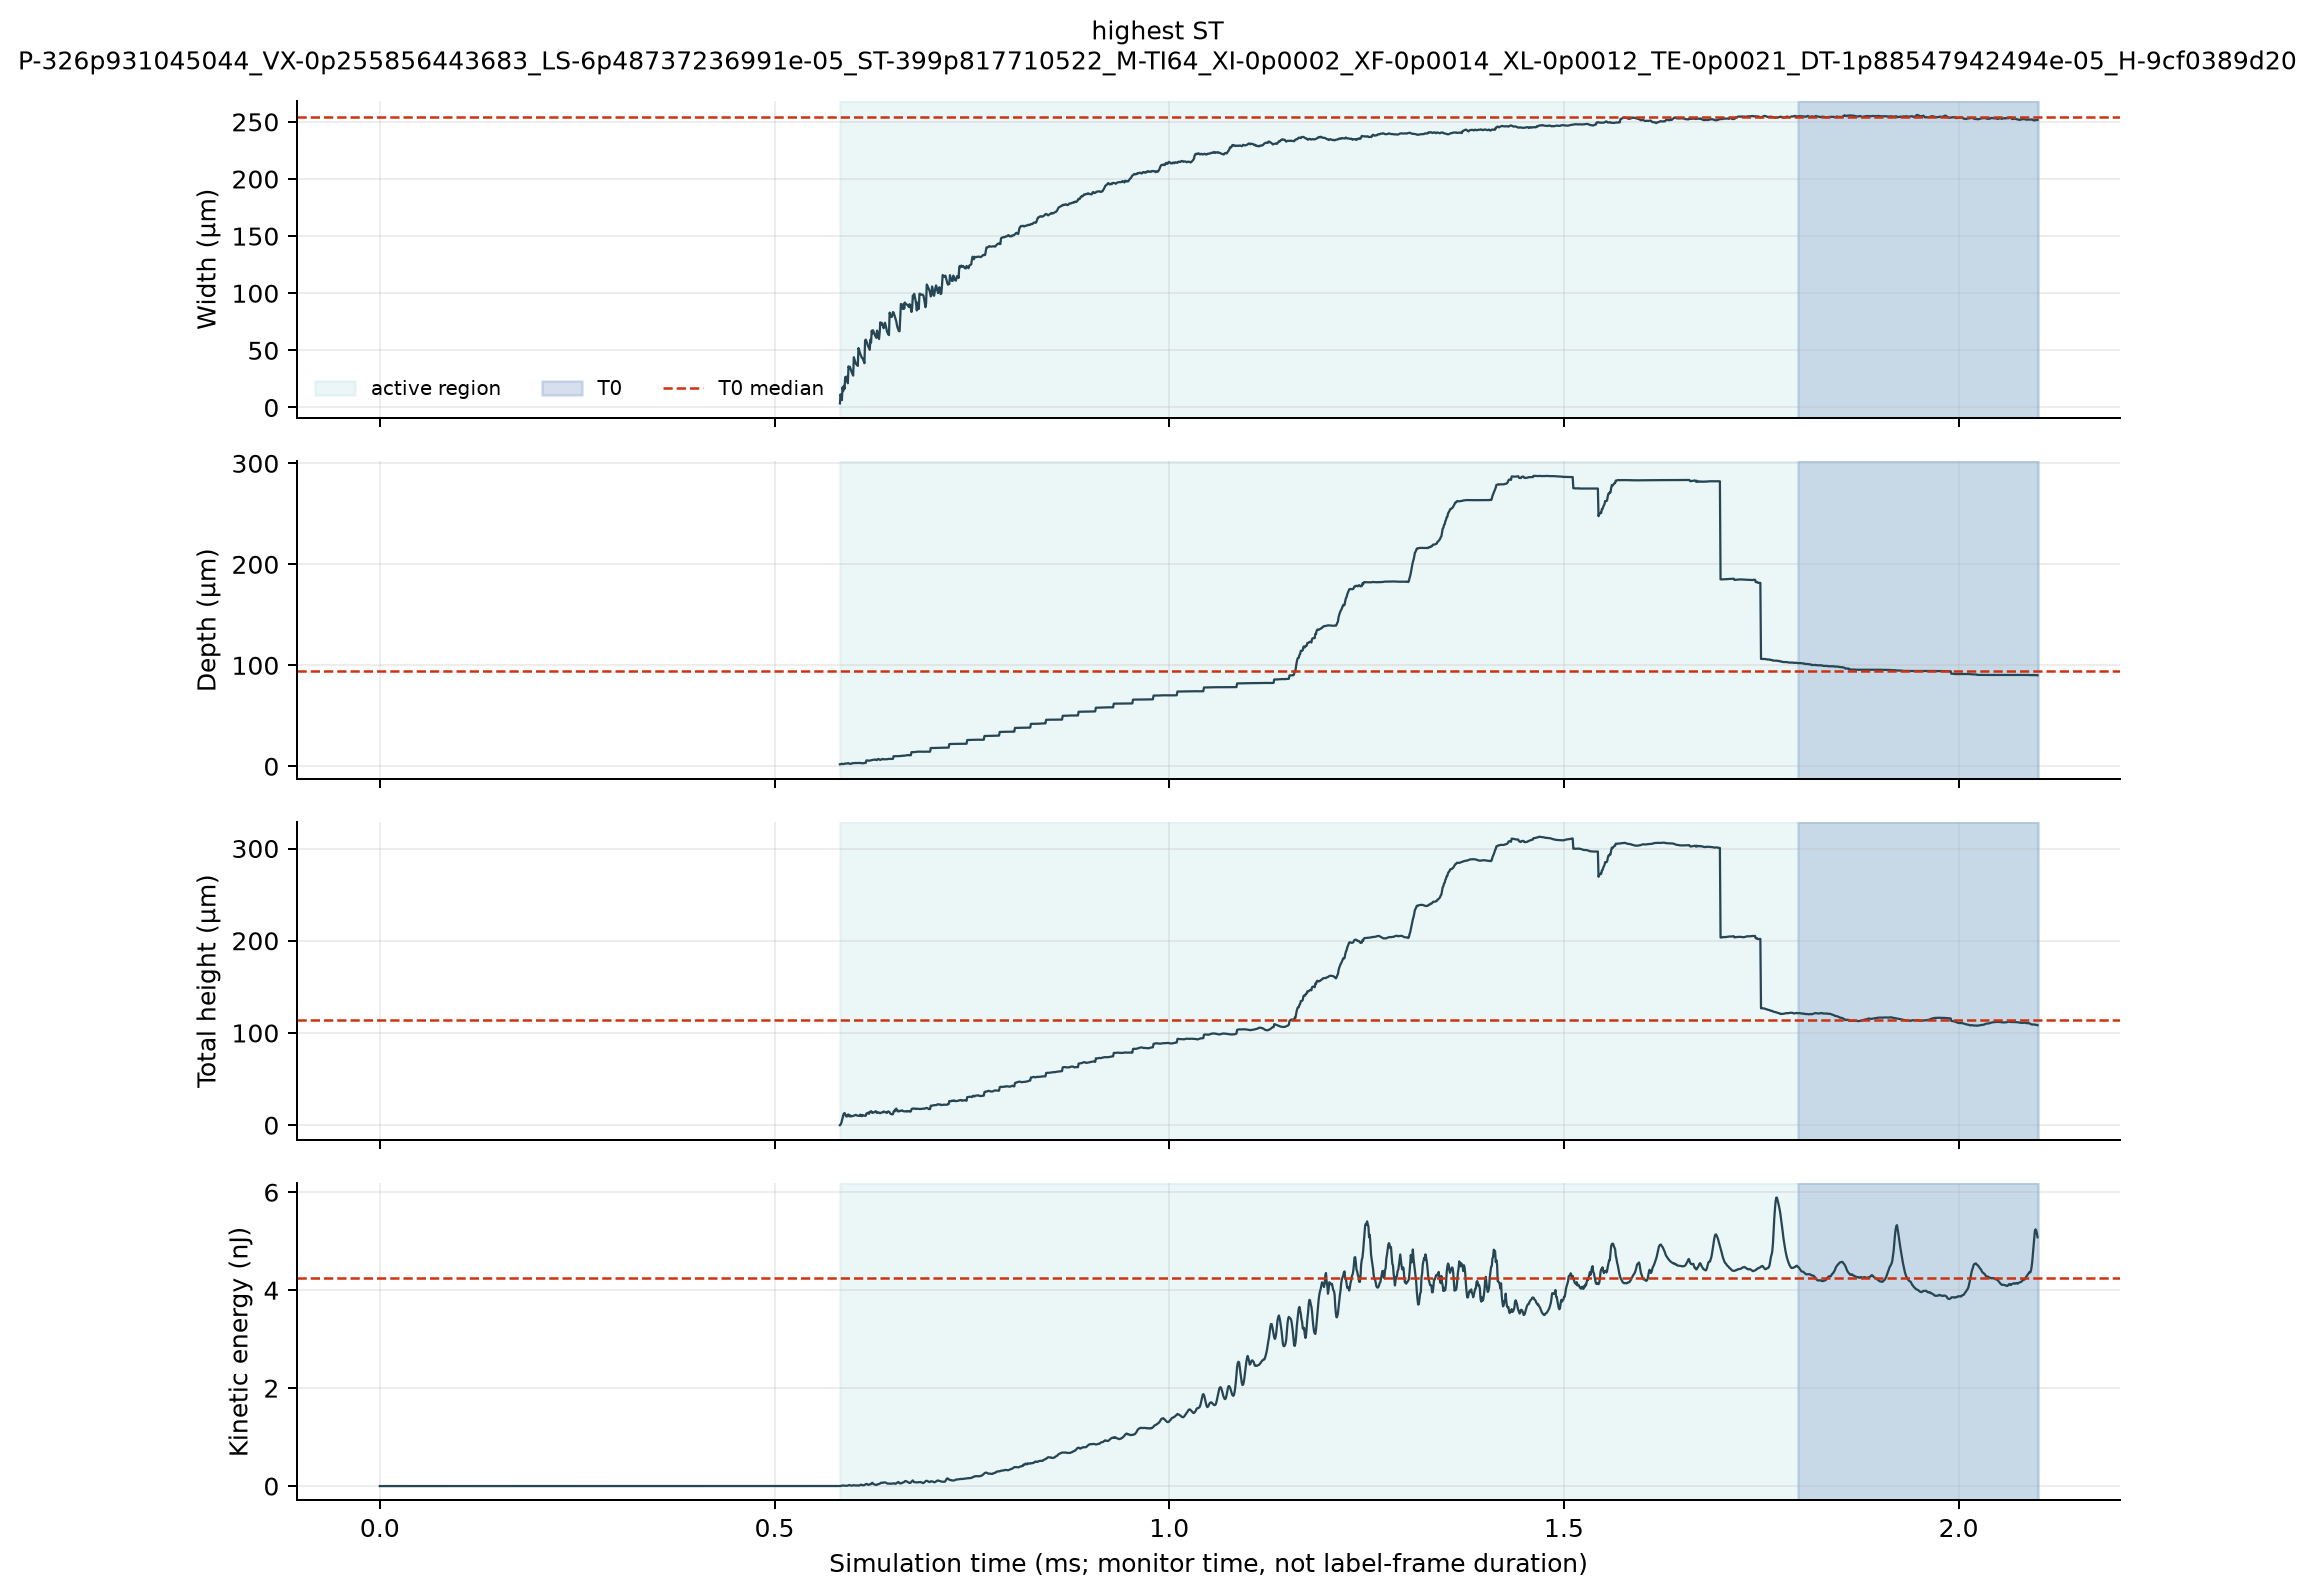

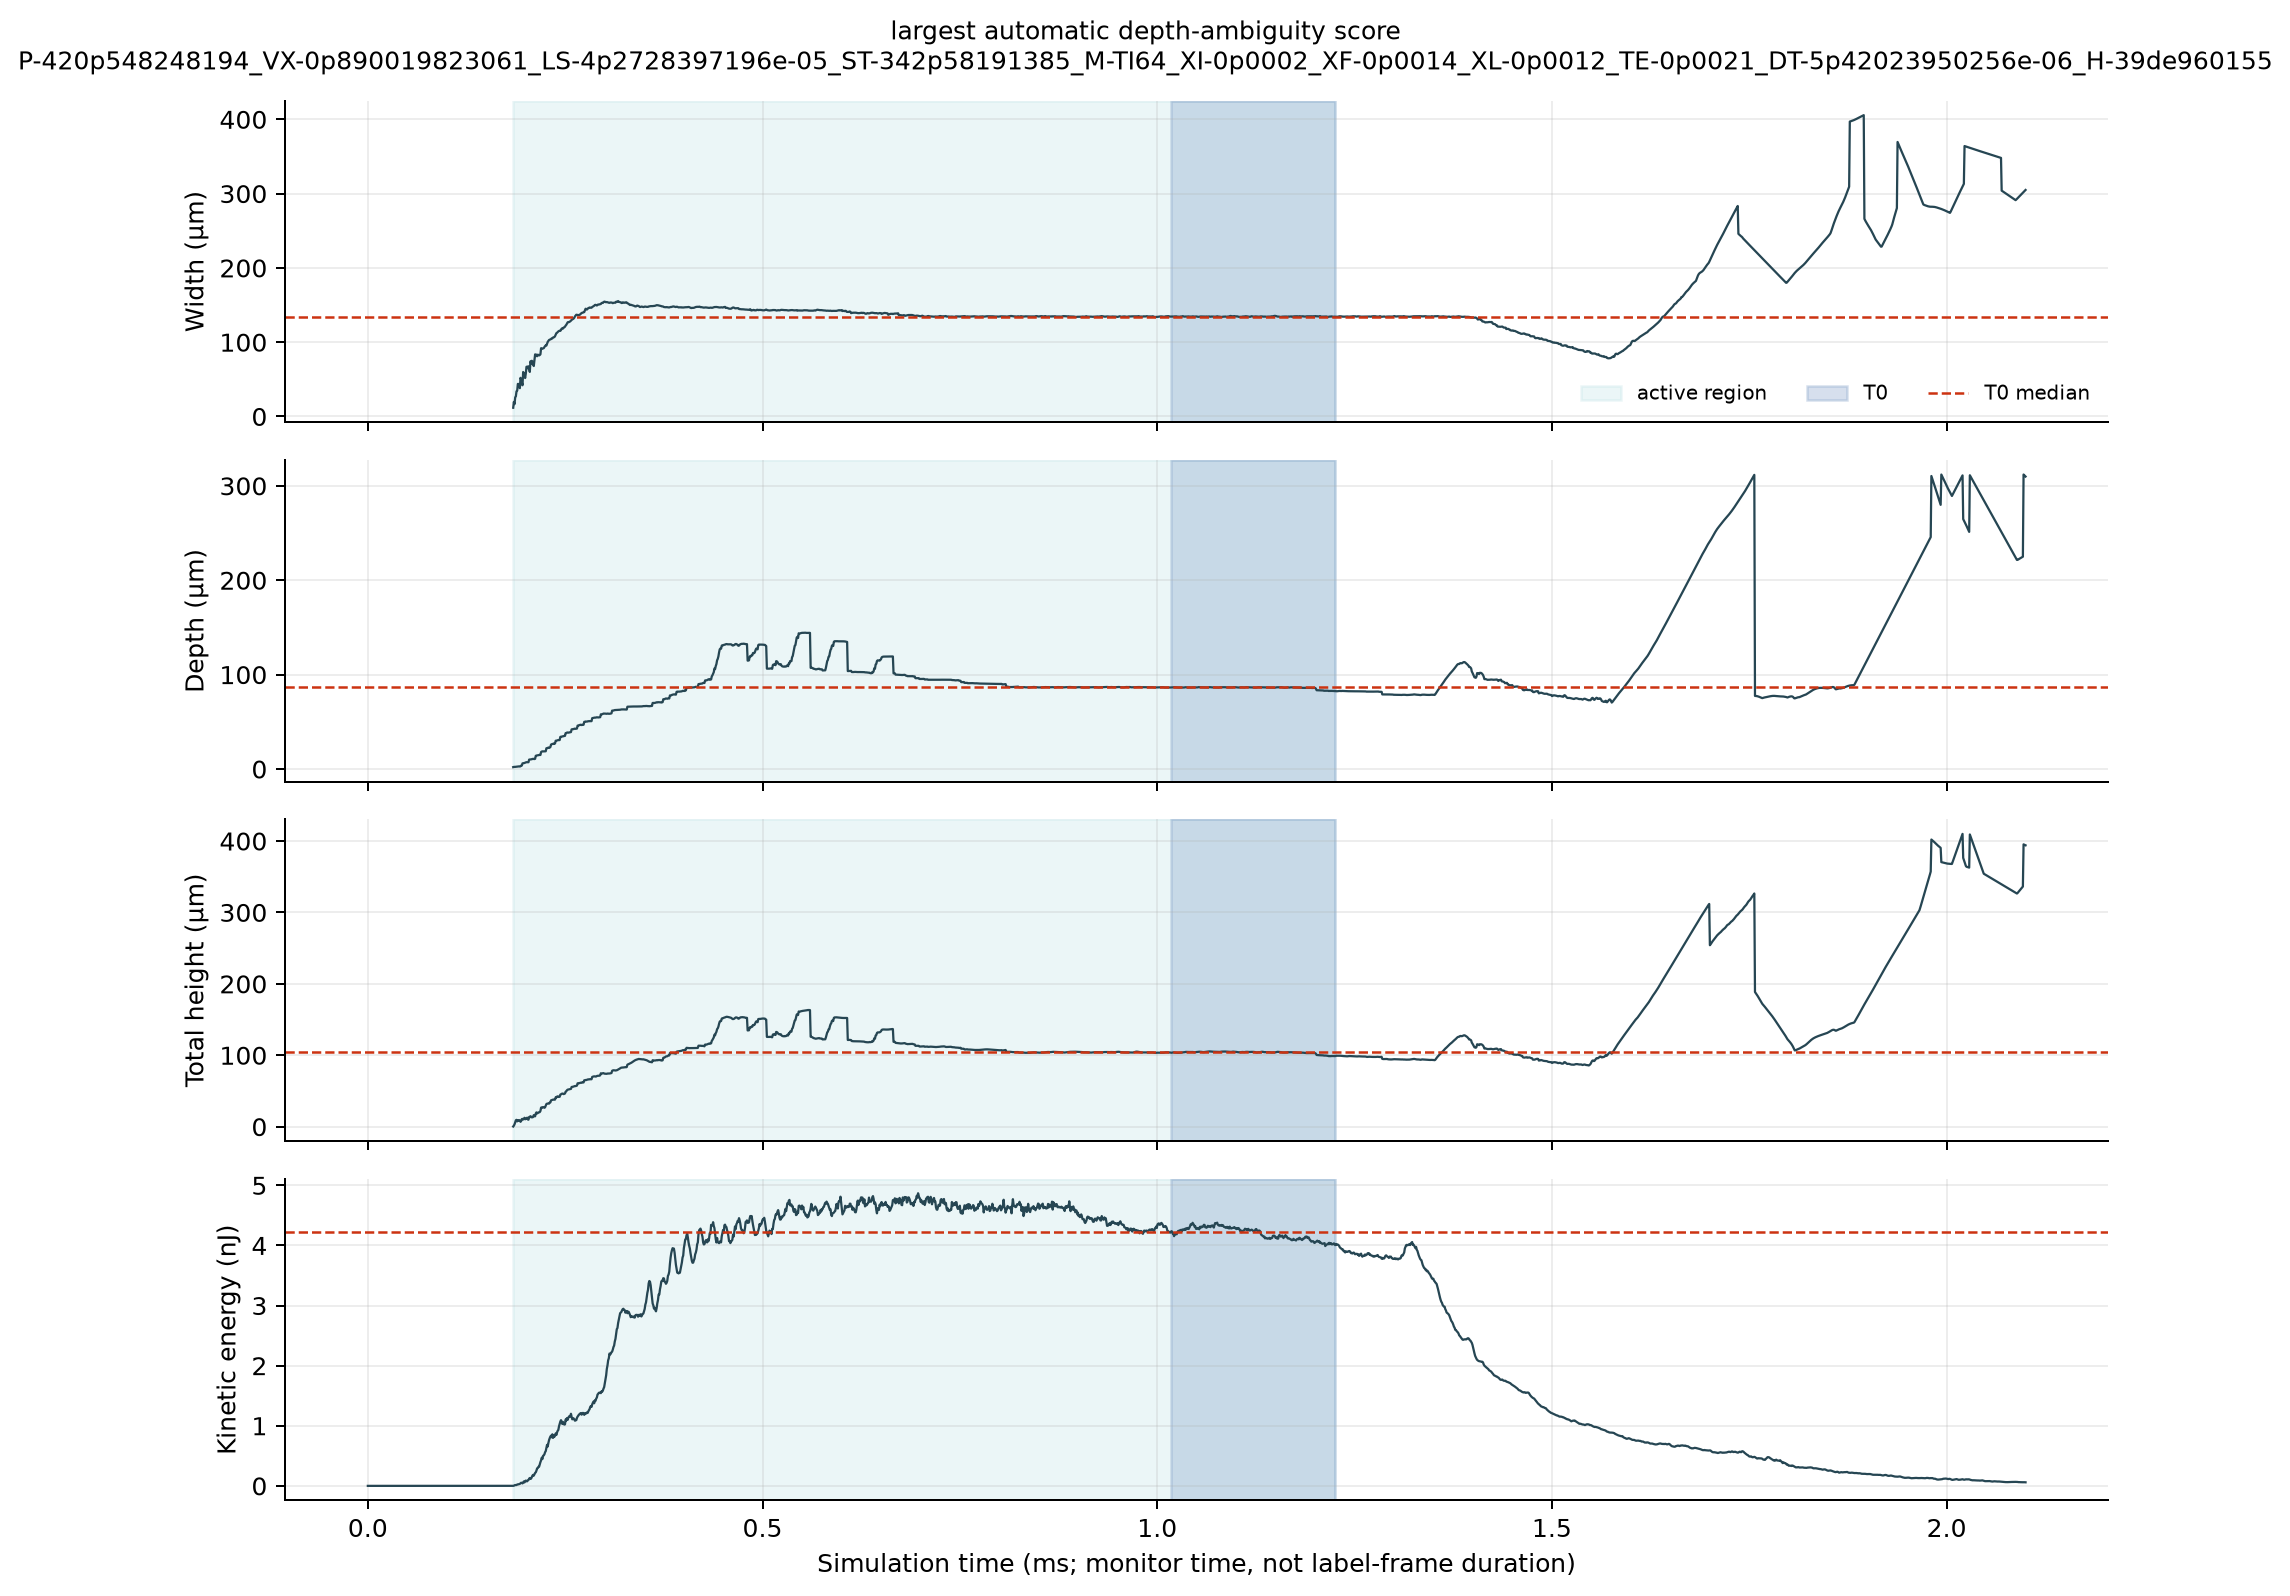

In [6]:
representatives = pd.read_csv(OUT / "representative_simulation_selection.csv")
manifest = pd.read_csv(OUT / "figure_manifest.csv")
display(representatives)
representative_figures = manifest[manifest["figure"].str.startswith("representative_")]
display(representative_figures[["figure", "question", "experiment_name"]])
for path in representative_figures["path"]:
    display(Image(filename=str(ROOT / path), width=980))

**Interpretation.** The **12** selections are rule-based, not hand-picked for attractive behaviour. Each plot shows the full monitor-time context, the active interval, T0, and the selected median for all four primary responses. The explicit failed case remains listed even though no physical trace can be constructed without its missing inputs.

## 6. Simulation-level physical-target table

**What are we doing?** Inspect the one-row-per-experiment CSV/Parquet table and recompute descriptive summaries with the reusable function.  
**Why?** Later phases need one transparent interface containing inputs, labels, targets, extrema, uncertainty/stability diagnostics, and failure reasons.  
**Question answered.** Which rows are physically usable and which quantities are retained for exact Week 6 continuity?  
**Suspicious result.** Dropped failures, missing revision/partition, negative dimensions, non-finite successful targets, or length promoted as a primary response.

In [7]:
targets = pd.read_csv(OUT / "sph_v2_simulation_level_targets.csv")
valid = targets[targets["target_extraction_valid"]]
target_summary_now = descriptive_target_summary(targets)
stored_target_summary = pd.read_csv(OUT / "target_distribution_summary.csv")
display(targets[[
    "experiment_name", "partition", "exact_sph_v2_revision", "P_W", "VX_m_per_s",
    "LS_um", "ST_K", "has_conduction", "has_keyhole", "T0_width_um",
    "T0_depth_um", "T0_total_height_um", "T0_kinetic_energy_nJ", "max_depth_um",
    "max_total_height_um", "max_kinetic_energy_nJ", "G3_persistent_depth_um",
    "R3_persistent_depth_width_ratio", "target_extraction_valid", "extraction_status",
    "geometry_monitor_available", "geometry_parse_ok", "geometry_target_ready",
    "time_monitor_available", "kinetic_energy_monitor_available",
    "kinetic_energy_parse_ok", "kinetic_energy_target_ready",
    "physical_target_extraction_success", "extraction_failure_reason",
    "label_analysis_ready",
]].head(12))
display(targets.groupby(["partition", "target_extraction_valid"]).size().rename("experiments").reset_index())
display(target_summary_now[target_summary_now["group"].eq("overall")])
assert targets["length_is_primary_target"].fillna(False).eq(False).all()
assert targets["simulation_silently_removed"].eq(False).all()

,experiment_name,partition,exact_sph_v2_revision,P_W,VX_m_per_s,LS_um,ST_K,has_conduction,has_keyhole,T0_width_um,T0_depth_um,T0_total_height_um,T0_kinetic_energy_nJ,max_depth_um,max_total_height_um,max_kinetic_energy_nJ,G3_persistent_depth_um,R3_persistent_depth_width_ratio,target_extraction_valid,extraction_status,geometry_monitor_available,geometry_parse_ok,geometry_target_ready,time_monitor_available,kinetic_energy_monitor_available,kinetic_energy_parse_ok,kinetic_energy_target_ready,physical_target_extraction_success,extraction_failure_reason,label_analysis_ready
0,P-102p928146519_VX-0p633805217924_LS-5p29394366699e-05_ST-318p223787128_M-TI64_XI-0p0002_XF...,new-data,d69dac5bda8b622bc0de316b112815c6056c06ec,102.928147,0.633805,52.939437,318.223787,True,False,125.250690,38.979610,61.817415,0.733964,43.09636,67.79005,0.902175,42.87279,0.343406,True,PASS,True,True,True,True,True,True,True,True,NaN,True
1,P-109p741517589_VX-0p915030812968_LS-7p99759662409e-05_ST-303p804431165_M-TI64_XI-0p0002_XF...,new-data,d69dac5bda8b622bc0de316b112815c6056c06ec,109.741518,0.915031,79.975966,303.804431,True,False,120.963440,26.909320,51.444150,0.885511,27.37239,53.40922,1.018489,27.06171,0.234919,True,PASS,True,True,True,True,True,True,True,True,NaN,True
2,P-111p098510779_VX-0p492021331775_LS-4p80108469254e-05_ST-345p911753718_M-TI64_XI-0p0002_XF...,new-data,d69dac5bda8b622bc0de316b112815c6056c06ec,111.098511,0.492021,48.010847,345.911754,True,False,136.117510,46.872595,72.033330,0.932796,54.88141,77.87564,1.103063,54.67908,0.405187,True,PASS,True,True,True,True,True,True,True,True,NaN,True
3,P-113p729503671_VX-0p646987288946_LS-8p28088886776e-05_ST-328p878079062_M-TI64_XI-0p0002_XF...,new-data,d69dac5bda8b622bc0de316b112815c6056c06ec,113.729504,0.646987,82.808889,328.878079,True,False,155.367745,34.473155,64.026220,0.907924,35.40171,131.94279,1.120391,34.87481,0.228077,True,PASS,True,True,True,True,True,True,True,True,NaN,True
4,P-115p973342836_VX-0p629021136955_LS-5p81694798744e-05_ST-308p264473639_M-TI64_XI-0p0002_XF...,new-data,d69dac5bda8b622bc0de316b112815c6056c06ec,115.973343,0.629021,58.169480,308.264474,True,False,135.672030,42.717450,67.868990,0.925643,47.09942,73.31245,1.104970,46.86994,0.347461,True,PASS,True,True,True,True,True,True,True,True,NaN,True
5,P-117p204089079_VX-0p299188895548_LS-6p61946140465e-05_ST-399p004242061_M-TI64_XI-0p0002_XF...,new-data,d69dac5bda8b622bc0de316b112815c6056c06ec,117.204089,0.299189,66.194614,399.004242,True,False,194.974095,54.719100,75.535020,1.295771,54.98240,79.45821,1.370362,54.80900,0.294261,True,PASS,True,True,True,True,True,True,True,True,NaN,True
6,P-118p239150472_VX-0p728951155133_LS-5p59862781201e-05_ST-395p421202378_M-TI64_XI-0p0002_XF...,new-data,d69dac5bda8b622bc0de316b112815c6056c06ec,118.239150,0.728951,55.986278,395.421202,True,False,127.484670,42.712630,66.764440,0.972180,46.94477,72.32555,1.211175,46.76281,0.367414,True,PASS,True,True,True,True,True,True,True,True,NaN,True
7,P-119p523515535_VX-0p859779155666_LS-6p70931710444e-05_ST-392p874711106_M-TI64_XI-0p0002_XF...,new-data,d69dac5bda8b622bc0de316b112815c6056c06ec,119.523516,0.859779,67.093171,392.874711,True,False,127.620460,38.078260,62.805030,1.009012,38.90503,64.33786,1.163798,38.77427,0.304445,True,PASS,True,True,True,True,True,True,True,True,NaN,True
8,P-120p079917874_VX-0p610410046914_LS-8p29242579558e-05_ST-398p6729924_M-TI64_XI-0p0002_XF-0...,new-data,d69dac5bda8b622bc0de316b112815c6056c06ec,120.079918,0.610410,82.924258,398.672992,True,False,165.552355,38.589385,68.734410,1.026728,39.06833,135.50848,1.232477,38.92551,0.241786,True,PASS,True,True,True,True,True,True,True,True,NaN,True
9,P-120p906267006_VX-0p64748664338_LS-6p03748750968e-05_ST-359p518818343_M-TI64_XI-0p0002_XF-...,new-data,d69dac5bda8b622bc0de316b112815c6056c06ec,120.906267,0.647487,60.374875,359.518818,True,False,137.926200,43.112790,68.845880,1.008313,47.09125,74.44075,1.205732,46.90477,0.338315,True,PASS,True,True,True,True,True,True,True,True,Na

,partition,target_extraction_valid,experiments
0,new-data,False,1
1,new-data,True,164
2,old-data-local,False,56
3,old-data-local,True,123
4,old-data-remote-clean,True,63


,group,target,row_count,finite_count,missing_count,min,q05,q25,median,mean,q75,q95,max,std
0,overall,T0_width_um,407,350,57,86.308950,112.105712,135.347119,159.932973,165.134623,187.927808,232.095840,300.269850,37.467429
1,overall,T0_depth_um,407,350,57,15.102660,30.100815,46.900534,62.544680,77.605330,78.578683,221.951783,300.529900,57.355889
2,overall,T0_total_height_um,407,350,57,41.274050,54.250041,72.959468,87.955205,102.376684,104.360183,242.647020,322.614550,56.175474
3,overall,T0_kinetic_energy_nJ,407,350,57,0.338959,0.625464,1.292610,2.141471,2.478588,3.222585,5.402497,8.876052,1.576727
4,overall,max_depth_um,407,350,57,19.030580,31.108970,51.024608,63.151695,97.363845,88.502675,302.831320,311.999900,83.574537
5,overall,max_total_height_um,407,350,57,42.540950,58.860312,80.166585,99.119325,130.251331,131.657382,329.850695,422.248100,85.126918
6,overall,max_kinetic_energy_nJ,407,350,57,0.394467,0.743081,1.436338,2.355878,587.738631,3.563489,9.453351,198078.100000,10589.080375


C:\Users\ozgur\AppData\Local\Temp\ipykernel_2956\3676518835.py:19: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  assert targets["length_is_primary_target"].fillna(False).eq(False).all()


**Interpretation.** The table retains **407 rows**: **350 successful** and **57 explicit failures**. Availability, parse, target-readiness, physical-extraction, and label-readiness fields are derived from each rerun rather than a fixed exclusion list, so future upstream repairs can make rows eligible automatically. Successful T0/extreme responses are finite and non-negative, and total height is never below penetration depth under the stored definitions. Length remains diagnostic. G3/R3 are carried forward only for continuity and depth-ambiguity diagnostics—not as a new target choice.

## 7. Exact matched Week 6 versus `sph_v2` targets

**What are we doing?** Match only exact semantic folder identifiers from Week 6 metadata and compare T0 targets and window endpoints.  
**Why?** Old-data partitions provide a direct semantic-regression test of the migration.  
**Question answered.** Did the same bytes and definitions reproduce Week 6 numerical targets?  
**Suspicious result.** Fuzzy matches, changed endpoints, material numerical differences, or correlations used to hide offsets.

,experiment_name,week6_simulation_id,week6_original_hash,week6_metadata_path,week6_metadata_sha256,week6_dataset_revision
0,P-101p127472137_VX-0p52394730996_LS-4p5e-05_ST-300_M-TI64_XI--0p0002_XF-0p0012_XL-0p0014_TE...,sim_00001,b0e5aed98c,C:\Users\ozgur\Documents\thesis-week6-melt-pool-audit\data\raw\huggingface\sph_dataset\fina...,2e5e4903fcd152c8475af1c12a15c844034552bf2d1dfe80b9a46ffcc022ff07,0e859b748fdbc8454f66e58e101e333ac0479d42
1,P-104p101541641_VX-0p916529700054_LS-8p82882842693e-05_ST-394p968412652_M-TI64_XI-0p0002_XF...,sim_00002,6014a1f9c3,C:\Users\ozgur\Documents\thesis-week6-melt-pool-audit\data\raw\huggingface\sph_dataset\fina...,81712ff57206bc4f4b1cf6616ded6f4f65c18a677085ca793b7e4012ce30b223,0e859b748fdbc8454f66e58e101e333ac0479d42
2,P-105p276295276_VX-0p639039009111_LS-7p6636834293e-05_ST-367p44858305_M-TI64_XI-0p0002_XF-0...,sim_00003,bf889bf790,C:\Users\ozgur\Documents\thesis-week6-melt-pool-audit\data\raw\huggingface\sph_dataset\fina...,558cd295a33e631639fda136a46c49dfde58401b61ecb437577c1035713ab6dd,0e859b748fdbc8454f66e58e101e333ac0479d42
3,P-107p176159755_VX-0p320752066655_LS-8p75302281584e-05_ST-393p859643937_M-TI64_XI-0p0002_XF...,sim_00004,8daf8adcd4,C:\Users\ozgur\Documents\thesis-week6-melt-pool-audit\data\raw\huggingface\sph_dataset\fina...,b847029c681bb934b228aaba9e9e564d591dc265da28bf5ca37dc3afccfea332,0e859b748fdbc8454f66e58e101e333ac0479d42
4,P-109p759946449_VX-0p241926176876_LS-4p5e-05_ST-300_M-TI64_XI--0p0002_XF-0p0012_XL-0p0014_T...,sim_00005,fb250c7cf9,C:\Users\ozgur\Documents\thesis-week6-melt-pool-audit\data\raw\huggingface\sph_dataset\fina...,04516f8337d3dbc7a7224dc559b1829e60225ac47a50a39ae8886256018dfe82,0e859b748fdbc8454f66e58e101e333ac0479d42


,mapping guard,value
0,rows,241
1,unique semantic identifiers,241
2,unique Week 6 simulation IDs,241
3,metadata hashes recorded,241


,target,exact_match_count,pearson_correlation,maximum_absolute_difference,median_absolute_difference,identical_within_tolerance_count,materially_changed_count
0,width_um,186,1.0,1.000160e-10,0.0,186,0
1,depth_um,186,1.0,1.421085e-14,0.0,186,0
2,total_height_um,186,1.0,1.000018e-10,0.0,186,0
3,kinetic_energy_nJ,186,1.0,4.440892e-16,0.0,186,0


,experiment_name,partition,week6_simulation_id,new_T0_start_row_index,old_T0_start_row_index,new_T0_end_row_index,old_T0_end_row_index,new_T0_start_time_s,old_T0_start_time_s,new_T0_end_time_s,old_T0_end_time_s,new_width_um,old_width_um,difference_width_um,relative_difference_width_um,identical_within_tolerance_width_um,new_depth_um,old_depth_um,difference_depth_um,relative_difference_depth_um,identical_within_tolerance_depth_um,new_total_height_um,old_total_height_um,difference_total_height_um,relative_difference_total_height_um,identical_within_tolerance_total_height_um,new_kinetic_energy_nJ,old_kinetic_energy_nJ,difference_kinetic_energy_nJ,relative_difference_kinetic_energy_nJ,identical_within_tolerance_kinetic_energy_nJ,window_endpoints_identical
0,P-101p127472137_VX-0p52394730996_LS-4p5e-05_ST-300_M-TI64_XI--0p0002_XF-0p0012_XL-0p0014_TE...,old-data-local,sim_00001,55052.0,55052,68795.0,68795,0.001000,0.001000,0.001250,0.001250,126.261440,126.261440,0.000000e+00,0.000000e+00,True,50.710190,50.710190,0.000000e+00,0.000000e+00,True,74.865795,74.865795,0.000000e+00,0.000000e+00,True,1.011336,1.011336,0.000000e+00,0.000000e+00,True,True
1,P-104p101541641_VX-0p916529700054_LS-8p82882842693e-05_ST-394p968412652_M-TI64_XI-0p0002_XF...,old-data-local,sim_00002,54593.0,54593,65498.0,65498,0.000992,0.000992,0.001190,0.001190,126.328725,126.328725,0.000000e+00,0.000000e+00,True,26.660185,26.660185,0.000000e+00,0.000000e+00,True,92.055570,92.055570,-1.421085e-14,-1.543726e-16,True,0.861813,0.861813,1.110223e-16,1.288242e-16,True,True
2,P-105p276295276_VX-0p639039009111_LS-7p6636834293e-05_ST-367p44858305_M-TI64_XI-0p0002_XF-0...,old-data-local,sim_00003,58064.0,58064,68795.0,68795,0.001055,0.001055,0.001250,0.001250,127.941225,127.941225,1.000018e-10,7.816228e-13,True,34.838855,34.838855,-7.105427e-15,-2.039512e-16,True,62.371975,62.371975,-7.105427e-15,-1.139202e-16,True,0.759724,0.759724,0.000000e+00,0.000000e+00,True,True
3,P-109p759946449_VX-0p241926176876_LS-4p5e-05_ST-300_M-TI64_XI--0p0002_XF-0p0012_XL-0p0014_T...,old-data-local,sim_00005,55050.0,55050,68795.0,68795,0.001000,0.001000,0.001250,0.001250,166.993245,166.993245,0.000000e+00,0.000000e+00,True,66.619015,66.619015,0.000000e+00,0.000000e+00,True,84.099600,84.099600,0.000000e+00,0.000000e+00,True,1.031931,1.031931,0.000000e+00,0.000000e+00,True,True
4,P-110p642328299_VX-0p274154737479_LS-7p4676600105e-05_ST-358p612942181_M-TI64_XI-0p0002_XF-...,old-data-local,sim_00007,99232.0,99232,115599.0,115599,0.001803,0.001803,0.002100,0.002100,202.288750,202.288750,0.000000e+00,0.000000e+00,True,50.785830,50.785830,0.000000e+00,0.000000e+00,True,69.703175,69.703175,-1.421085e-14,-2.038767e-16,True,1.123971,1.123971,2.220446e-16,1.975536e-16,True,True
5,P-113p286681534_VX-0p56768277259_LS-5p80401726566e-05_ST-302p148970527_M-TI64_XI-0p0002_XF-...,old-data-local,sim_00010,58392.0,58392,68795.0,68795,0.001061,0.001061,0.001250,0.001250,133.948070,133.948070,2.842171e-14,2.121845e-16,True,46.822900,46.822900,7.105427e-15,1.517511e-16,True,67.953605,67.953605,0.000000e+00,0.000000e+00,True,0.931285,0.931285,-1.110223e-16,-1.192141e-16,True,True
6,P-115p281467344_VX-0p424433079834_LS-5p4086019252e-05_ST-352p652659088_M-TI64_XI-0p0002_XF-...,old-data-local,sim_00012,96939.0,96939,115599.0,115599,0.001761,0.001761,0.002100,0.002100,157.777810,157.777810,0.000000e+00,0.000000e+00,True,54.700130,54.700130,-7.105427e-15,-1.298978e-16,True,80.953800,80.953800,0.000000e+00,0.000000e+00,True,1.104152,1.104152,0.000000e+00,0.000000e+00,True,True
7,P-116p440418649_VX-0p621036488786_LS-7p33150072515e-05_ST-327p034160515_M-TI64_XI-0p0002_XF...,old-data-local,sim_00013,80398.0,80398,96679.0,96679,0.001461,0.001461,0.001756,0.001756,151.418870,151.418870,2.842171e-14,1.877026e-16,True,38.692790,38.692790,0.000000e+00,0.000000e+00,True,67.602270,67.602270,0.000000e+00,0.000000e+00,True,0.944144,0.944144,-1.110223e-16,-1.175904e-16,True,True
8,P-118p4900546_VX-0p535113778256_LS-4p79907961621e-05_ST-38

,check,value
0,exact identifiers in target table,241
1,comparable exact matches,186
2,all endpoints identical,True
3,materially changed target values,0


**11_exact_old_vs_new_target_comparison.png**

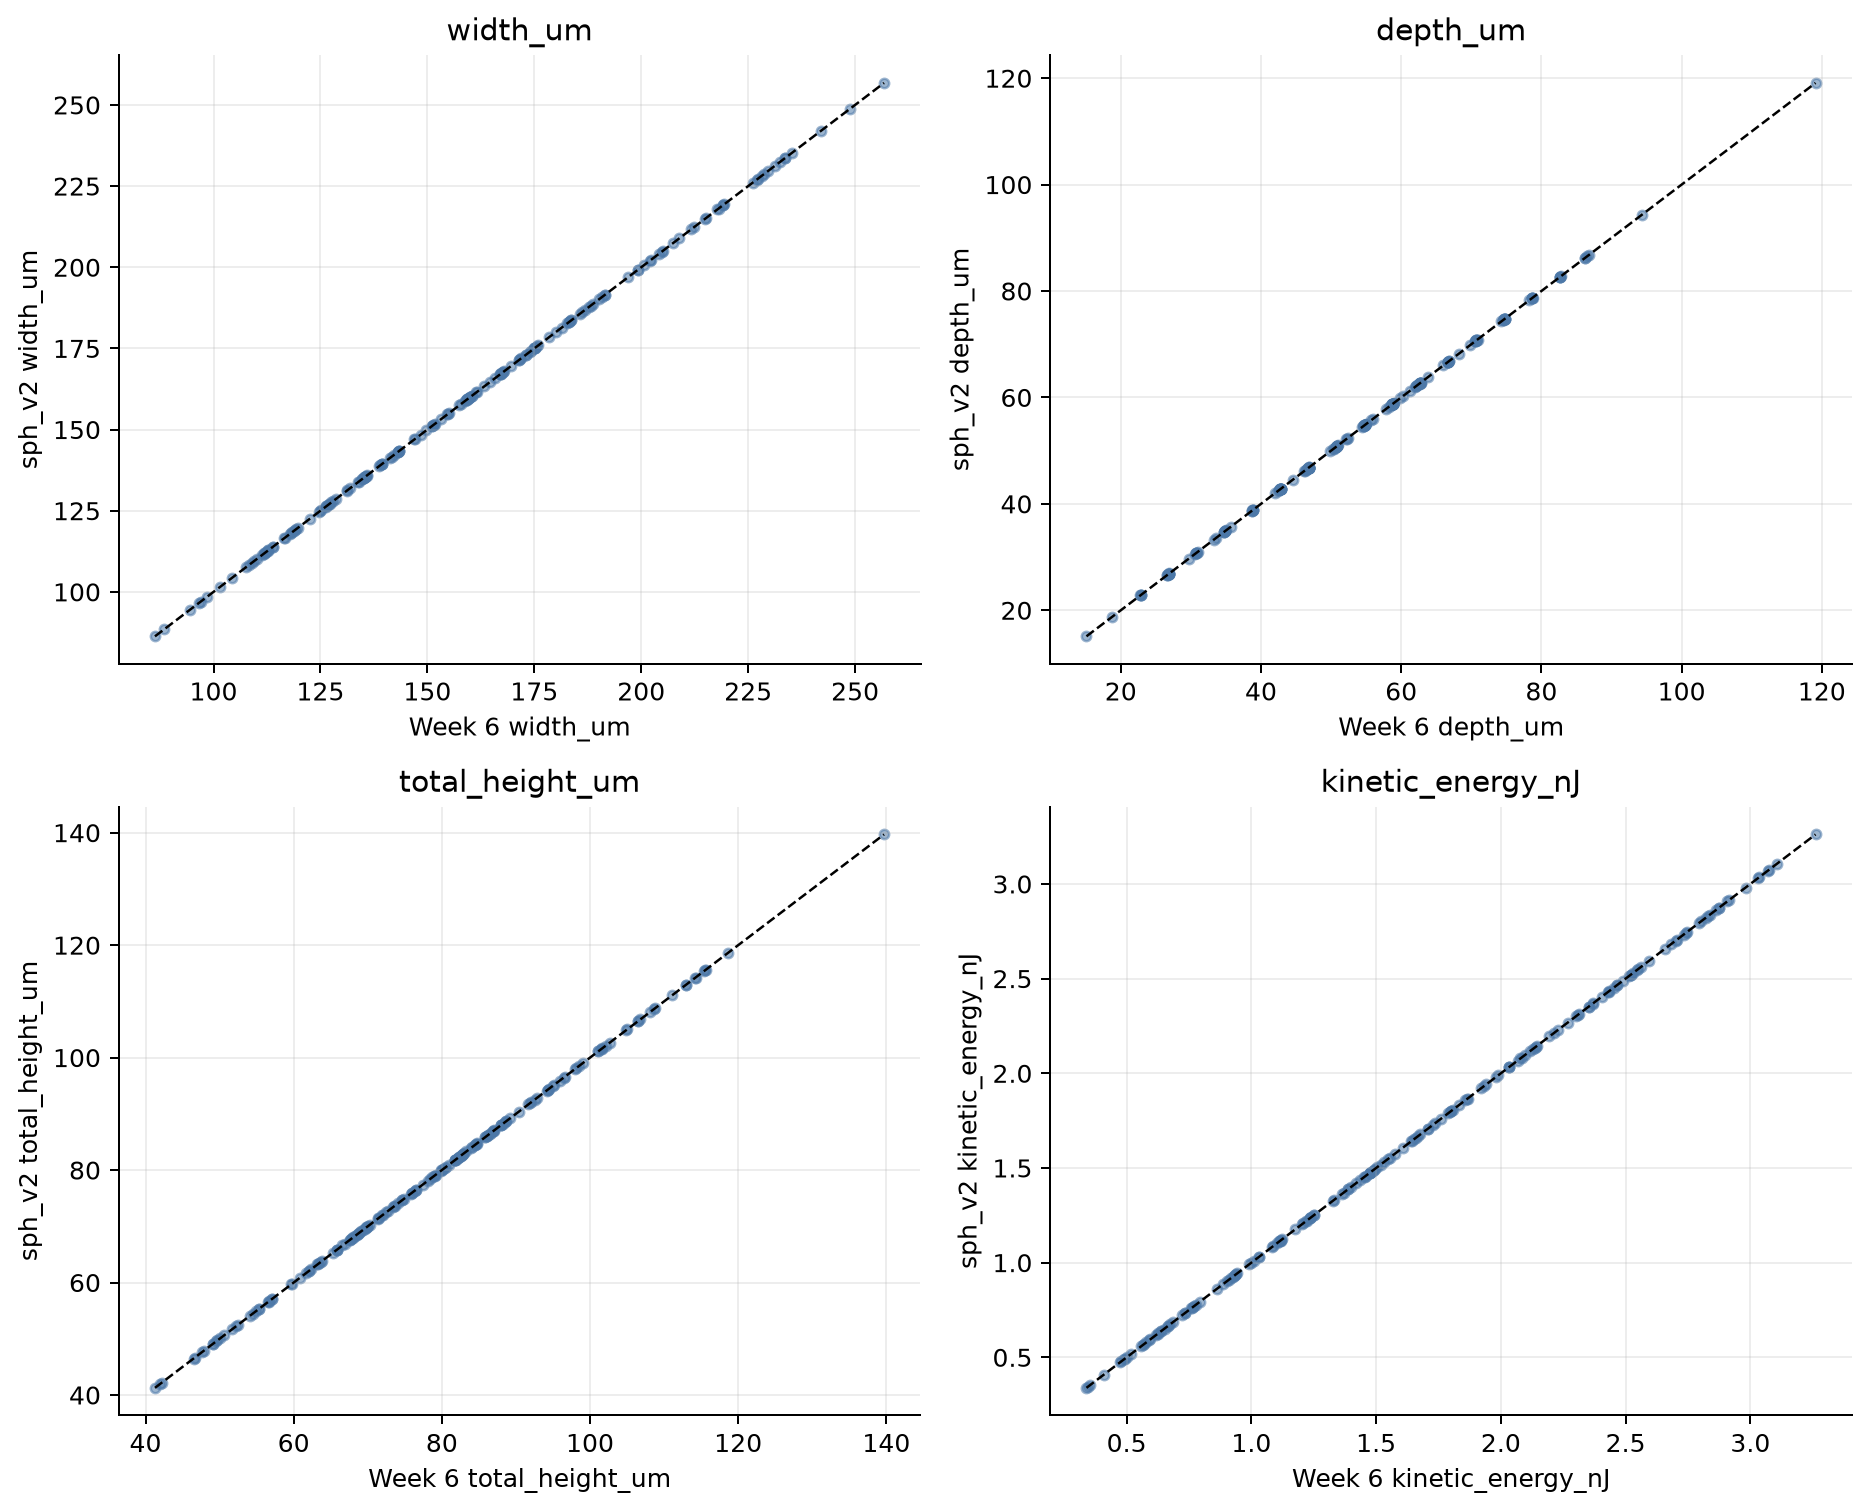

In [8]:
comparison = pd.read_csv(OUT / "exact_old_new_target_comparison.csv")
comparison_summary = pd.read_csv(OUT / "exact_old_new_target_comparison_summary.csv")
identifier_map = pd.read_csv(OUT / "week6_exact_identifier_map.csv")
display(identifier_map.head())
display(pd.DataFrame({
    "mapping guard": ["rows", "unique semantic identifiers", "unique Week 6 simulation IDs", "metadata hashes recorded"],
    "value": [
        len(identifier_map), identifier_map["experiment_name"].nunique(),
        identifier_map["week6_simulation_id"].nunique(),
        identifier_map["week6_metadata_sha256"].notna().sum(),
    ],
}))
display(comparison_summary)
display(comparison.head(12))
display(pd.DataFrame({
    "check": ["exact identifiers in target table", "comparable exact matches", "all endpoints identical", "materially changed target values"],
    "value": [
        int(targets["week6_simulation_id"].fillna("").str.len().gt(0).sum()),
        len(comparison),
        bool(comparison["window_endpoints_identical"].all()),
        int(comparison_summary["materially_changed_count"].sum()),
    ],
}))
show_figure("11_exact_old_vs_new_target_comparison.png")

**Interpretation.** **241 exact Week 6 identifiers** are present; **186** have all required monitors in the pinned `sph_v2` snapshot and can be compared. Every comparable width, depth, height, kinetic-energy value and T0 endpoint reproduces Week 6 within the declared near-machine-precision tolerances; **0** material changes are detected. Unmatched/new experiments are never fuzzily paired.

## 8. Descriptive target distributions

**What are we doing?** Compare successful target distributions overall, by partition, and by observed Keyhole presence.  
**Why?** Distribution plots can reveal unit, scale, or extraction mistakes before any modelling.  
**Question answered.** Are width, depth, height, and energy numerically plausible, and do labelled groups occupy different observed ranges?  
**Suspicious result.** Negative values, implausible orders of magnitude, or causal claims from group differences.

,group,target,row_count,finite_count,missing_count,min,q05,q25,median,mean,q75,q95,max,std
0,overall,T0_width_um,407,350,57,86.308950,112.105712,135.347119,159.932973,165.134623,187.927808,232.095840,300.269850,37.467429
1,overall,T0_depth_um,407,350,57,15.102660,30.100815,46.900534,62.544680,77.605330,78.578683,221.951783,300.529900,57.355889
2,overall,T0_total_height_um,407,350,57,41.274050,54.250041,72.959468,87.955205,102.376684,104.360182,242.647020,322.614550,56.175474
3,overall,T0_kinetic_energy_nJ,407,350,57,0.338959,0.625464,1.292610,2.141471,2.478588,3.222585,5.402497,8.876052,1.576727
4,overall,max_depth_um,407,350,57,19.030580,31.108970,51.024608,63.151695,97.363845,88.502675,302.831320,311.999900,83.574537
5,overall,max_total_height_um,407,350,57,42.540950,58.860312,80.166585,99.119325,130.251331,131.657382,329.850695,422.248100,85.126918
6,overall,max_kinetic_energy_nJ,407,350,57,0.394467,0.743081,1.436338,2.355878,587.738631,3.563489,9.453351,198078.100000,10589.080375
7,partition=new-data,T0_width_um,165,164,1,111.529485,126.473848,142.735450,166.656785,171.418665,191.146151,240.755535,300.269850,36.546741
8,partition=new-data,T0_depth_um,165,164,1,26.909320,42.726849,58.759201,74.741470,104.539754,100.742600,297.469710,300.529900,73.040791
9,partition=new-data,T0_total_height_um,165,164,1,51.444150,68.129958,88.299790,100.628758,128.880788,125.705817,316.758393,322.614550,71.140331


**03_T0_width_um_distribution.png**

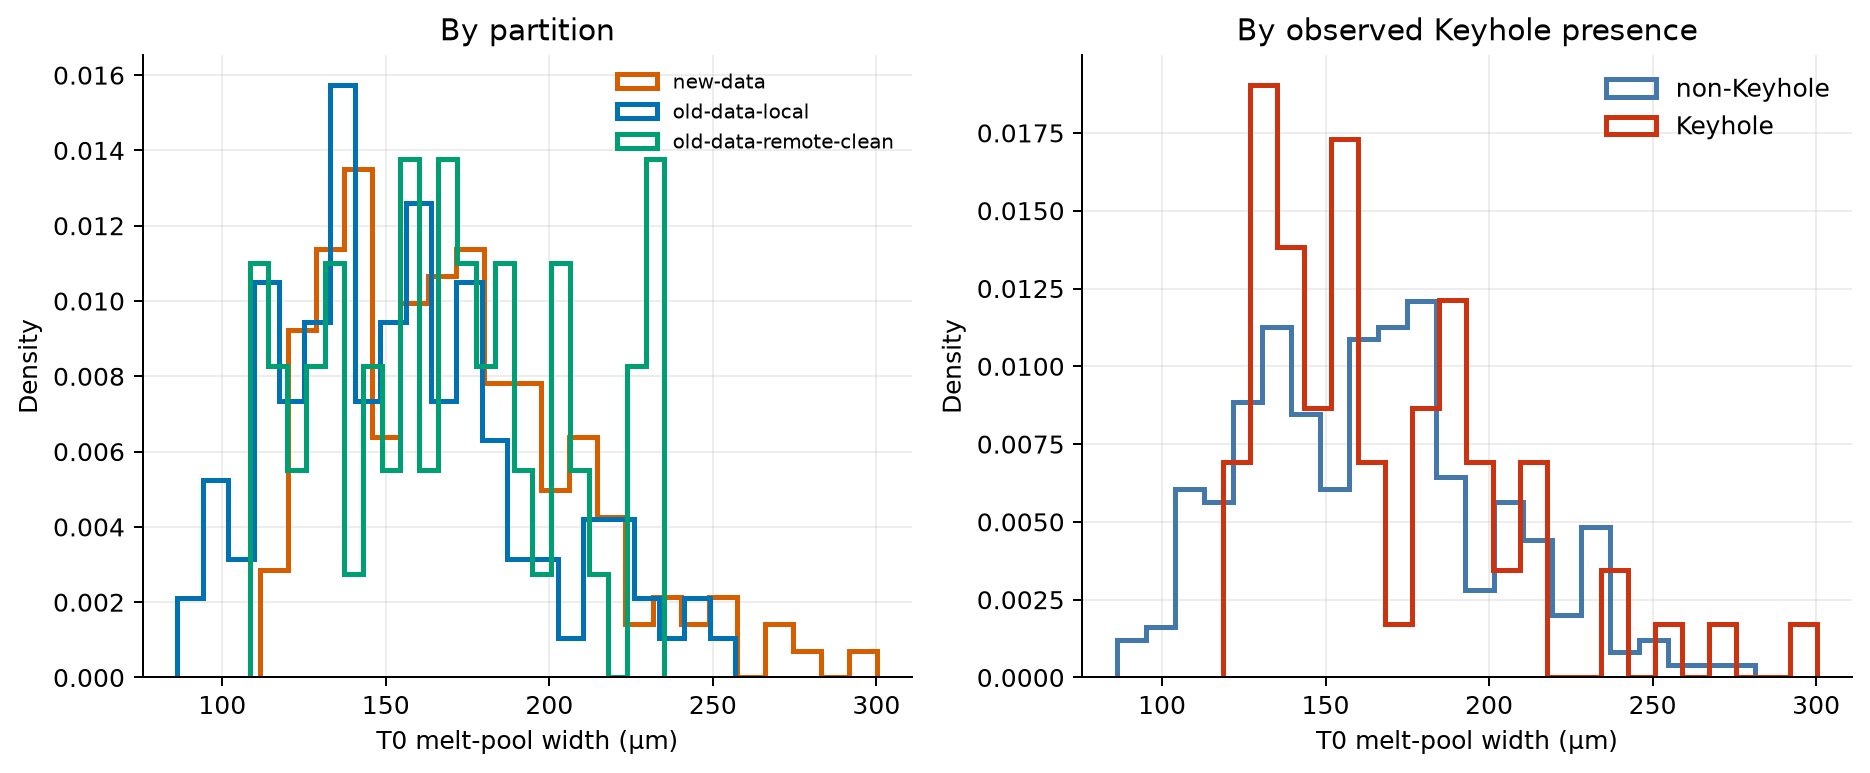

**04_T0_depth_um_distribution.png**

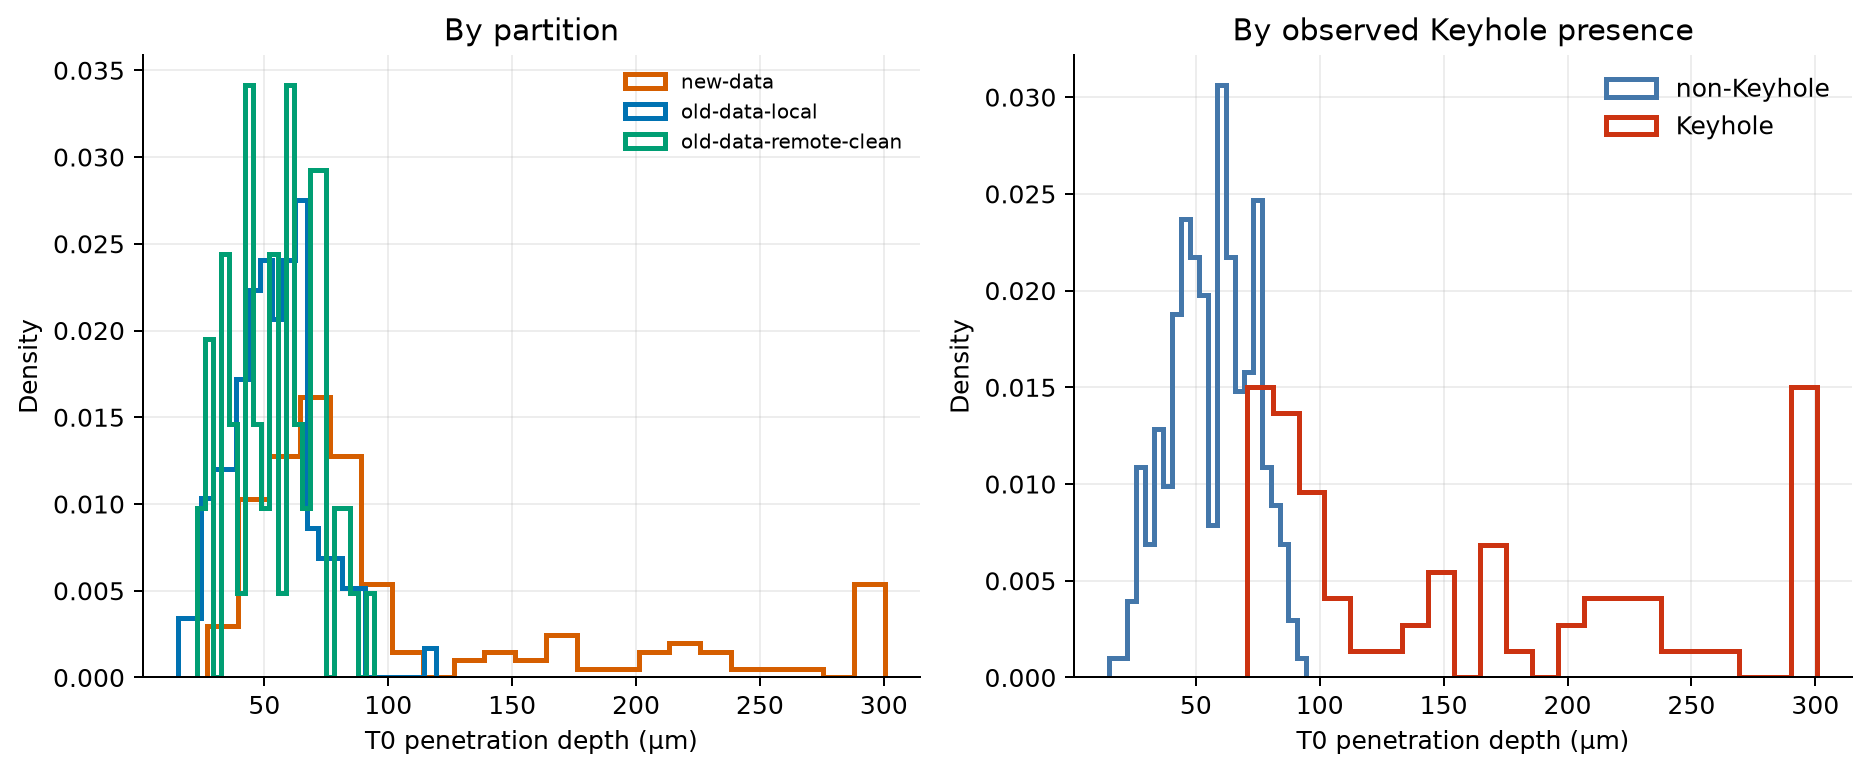

**05_T0_total_height_um_distribution.png**

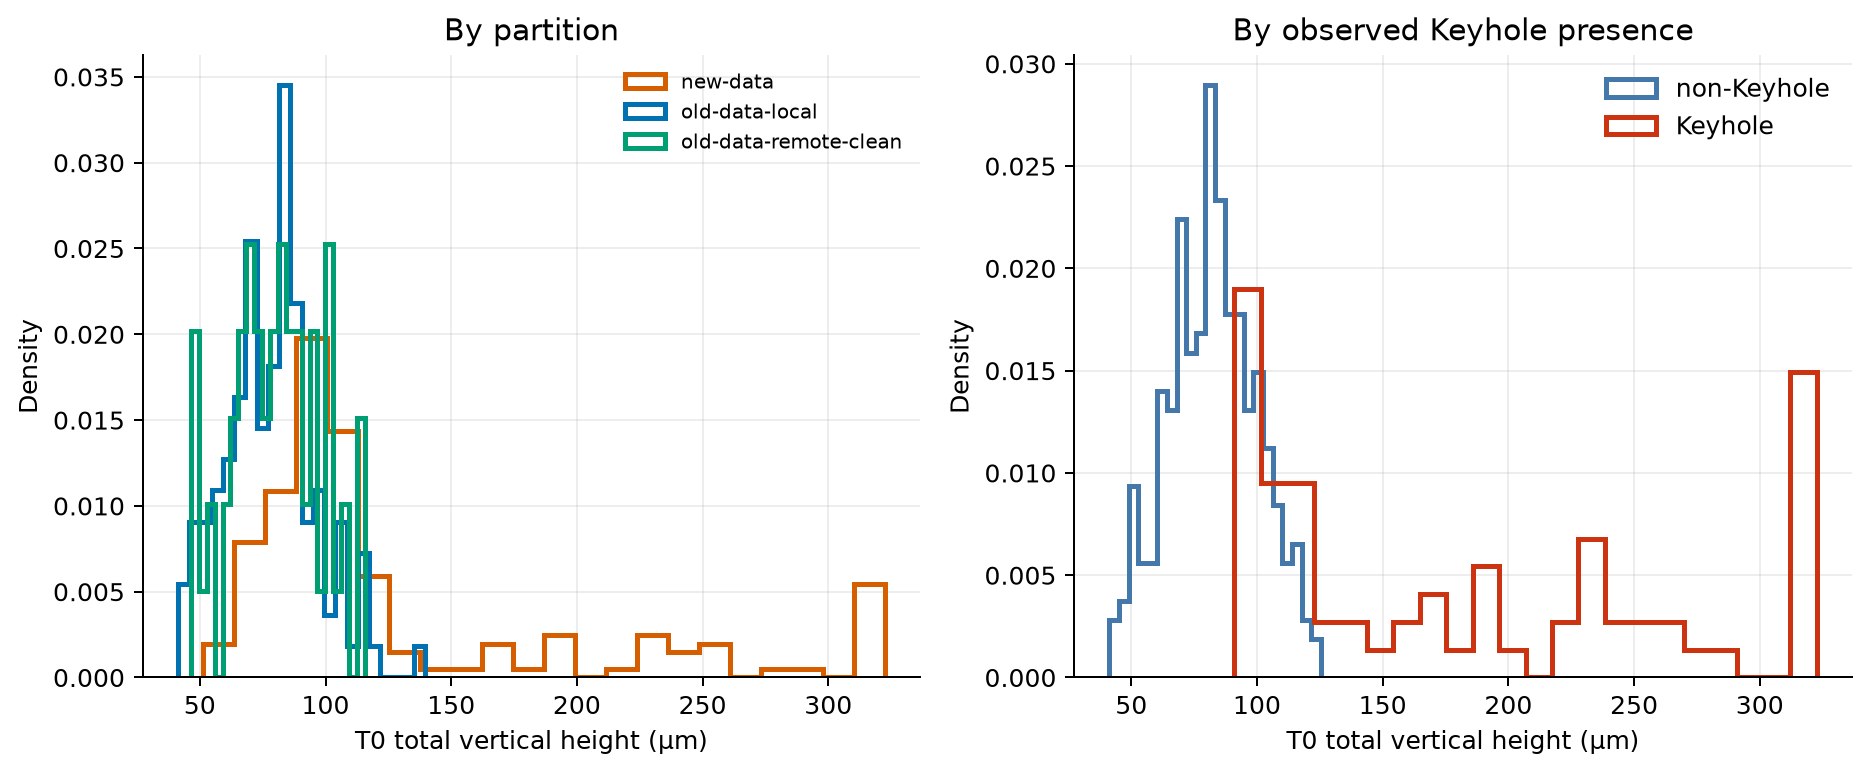

**06_T0_kinetic_energy_nJ_distribution.png**

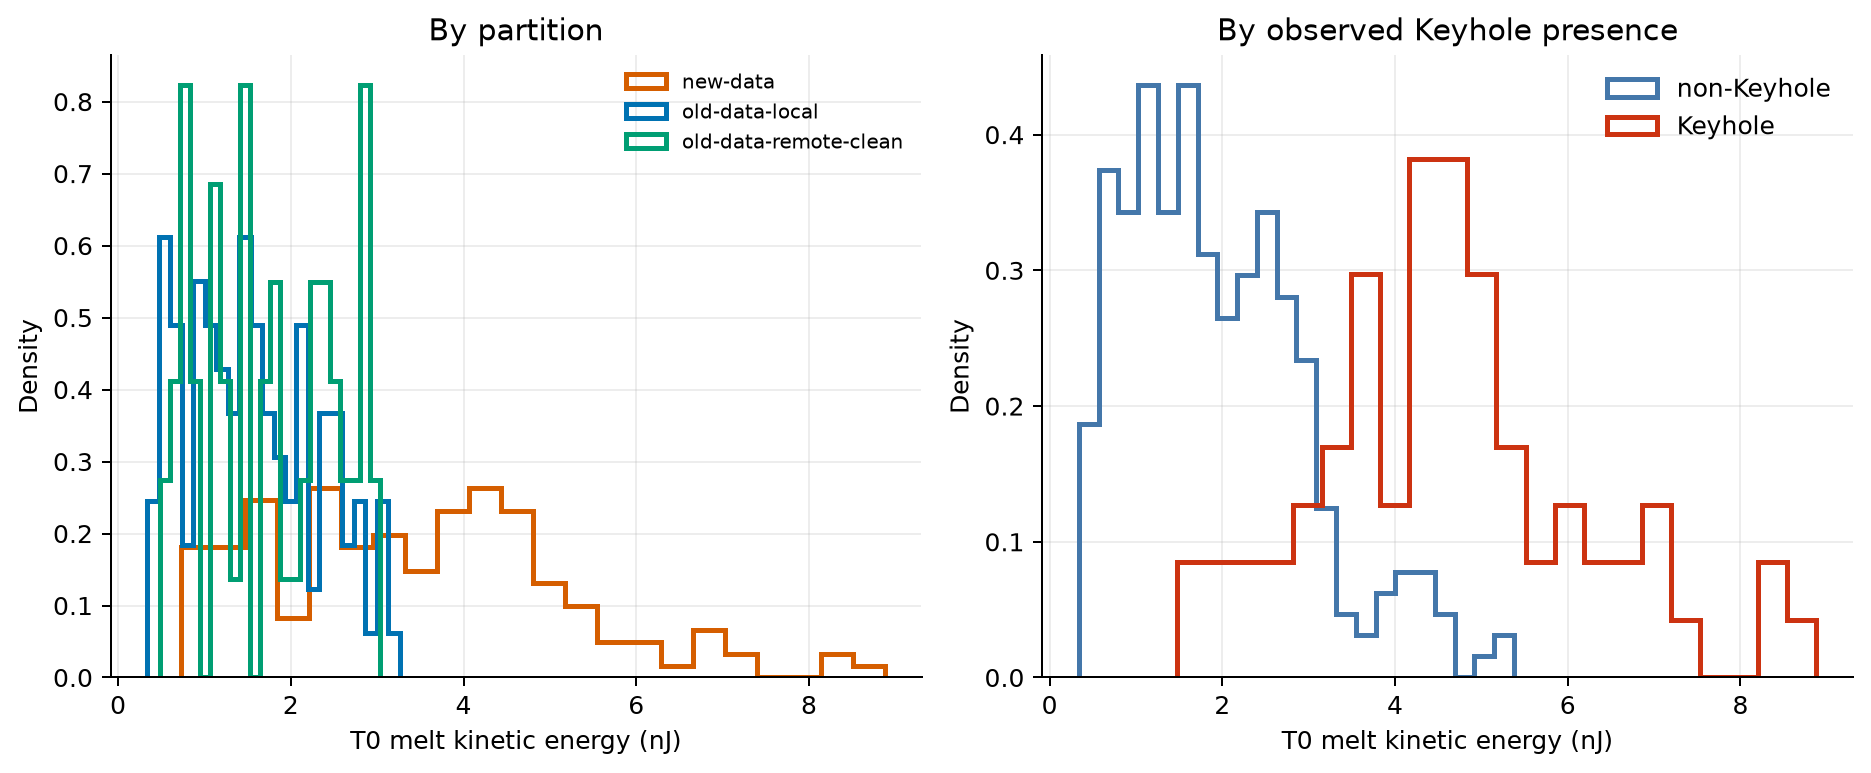

In [9]:
target_summary = pd.read_csv(OUT / "target_distribution_summary.csv")
display(target_summary)
for filename in [
    "03_T0_width_um_distribution.png",
    "04_T0_depth_um_distribution.png",
    "05_T0_total_height_um_distribution.png",
    "06_T0_kinetic_energy_nJ_distribution.png",
]:
    show_figure(filename)

**Interpretation.** The primary responses have coherent units and finite successful rows. Partition and Keyhole-group differences are descriptive evidence only. They can reflect the strongly shifted input design as well as physical-regime differences; this notebook does not fit a predictor or claim causation.

## 9. T0 versus maxima and transient Keyhole timing

**What are we doing?** Locate maximum depth/height/energy relative to T0 and align saved Keyhole timesteps exactly with `iter.dat`.  
**Why?** T0 describes typical late-active behaviour, whereas a brief Keyhole or extreme response may occur earlier.  
**Question answered.** How often does T0 exclude extrema or all saved Keyhole frames?  
**Suspicious result.** Treating this diagnostic as permission to redefine T0, or interpolating unmatched label timesteps silently.

,maximum depth location,experiments
0,before T0,246
1,inside T0,68
2,after T0,36


,keyhole_timing_relative_to_T0,experiments
0,spans_multiple_T0_regions,46
1,before_T0,22
2,NaN,3
3,inside_T0,2


,experiment_name,partition,T0_depth_um,max_depth_um,max_depth_relative_to_T0,keyhole_frames_before_T0,keyhole_frames_inside_T0,keyhole_frames_after_T0,keyhole_overlaps_T0
46,P-208p096600196_VX-0p256636148953_LS-4p52492384214e-05_ST-395p602757306_M-TI64_XI-0p0002_XF...,new-data,74.71056,158.3638,before_T0,14.0,0.0,0.0,False
53,P-212p944274192_VX-0p351323873231_LS-4p80439392259e-05_ST-351p894554175_M-TI64_XI-0p0002_XF...,new-data,78.70302,119.0752,before_T0,7.0,0.0,0.0,False
58,P-227p095146149_VX-0p485569900572_LS-4p61845747353e-05_ST-309p475761642_M-TI64_XI-0p0002_XF...,new-data,138.57590,207.3806,before_T0,106.0,37.0,0.0,True
69,P-243p042265843_VX-0p642372627708_LS-5p19118052277e-05_ST-314p809567363_M-TI64_XI-0p0002_XF...,new-data,74.52087,112.2186,before_T0,4.0,0.0,0.0,False
81,P-264p370573209_VX-0p395776293281_LS-4p78236029631e-05_ST-378p311267492_M-TI64_XI-0p0002_XF...,new-data,214.14570,302.1039,before_T0,80.0,29.0,0.0,True
85,P-270p660461155_VX-0p506275452772_LS-4p55363433165e-05_ST-392p157982605_M-TI64_XI-0p0002_XF...,new-data,171.73115,301.7339,before_T0,116.0,38.0,0.0,True
88,P-277p972333632_VX-0p331196372511_LS-4p5620211888e-05_ST-324p411035281_M-TI64_XI-0p0002_XF-...,new-data,107.62050,301.7815,before_T0,61.0,23.0,0.0,True
90,P-282p804328276_VX-0p543976889672_LS-5p22197252327e-05_ST-303p777238342_M-TI64_XI-0p0002_XF...,new-data,146.44625,197.1042,before_T0,115.0,39.0,11.0,True
94,P-293p648784497_VX-0p426690912013_LS-5p33940457289e-05_ST-351p677261216_M-TI64_XI-0p0002_XF...,new-data,236.99555,270.6234,before_T0,83.0,31.0,0.0,True
103,P-326p931045044_VX-0p255856443683_LS-6p48737236991e-05_ST-399p817710522_M-TI64_XI-0p0002_XF...,new-data,94.37197,287.6517,before_T0,27.0,0.0,0.0,False


**07_T0_vs_max_penetration_depth.png**

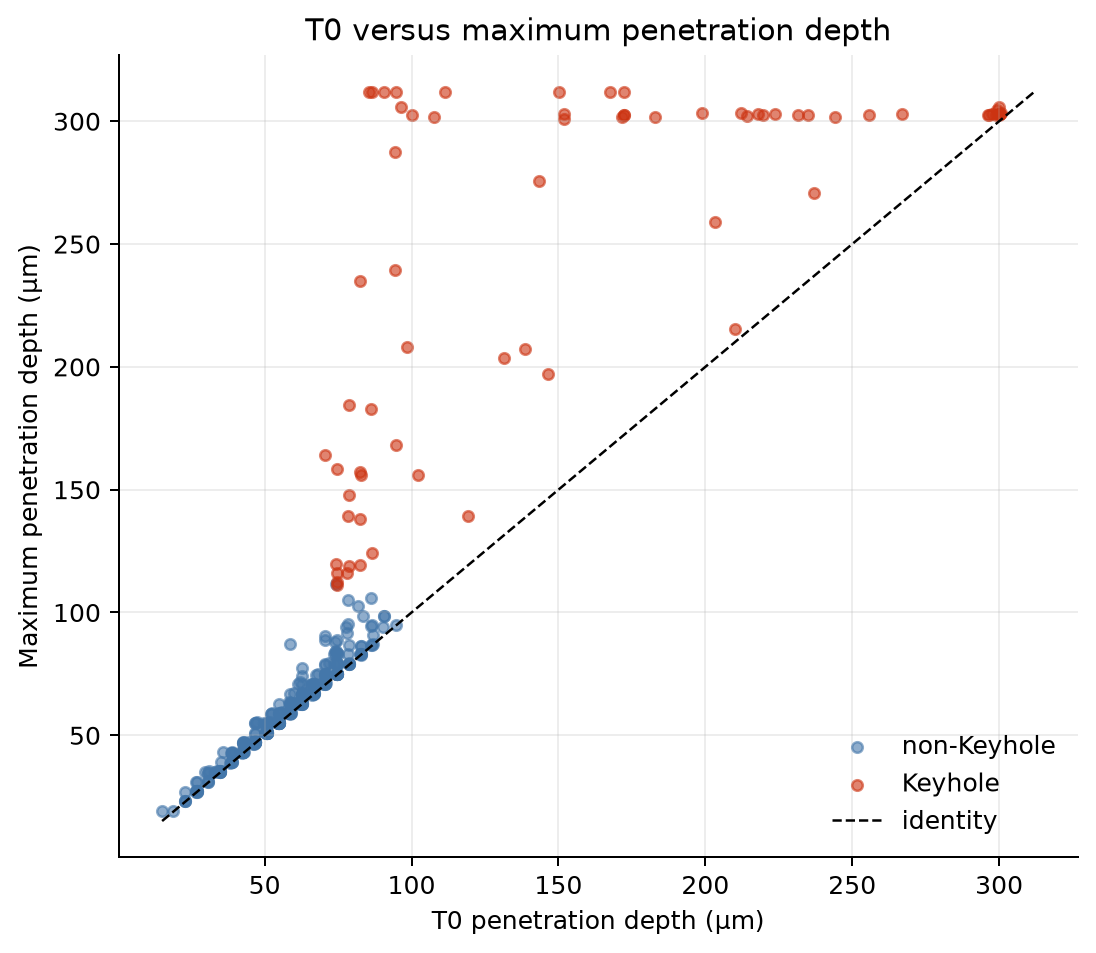

**08_T0_vs_max_total_height.png**

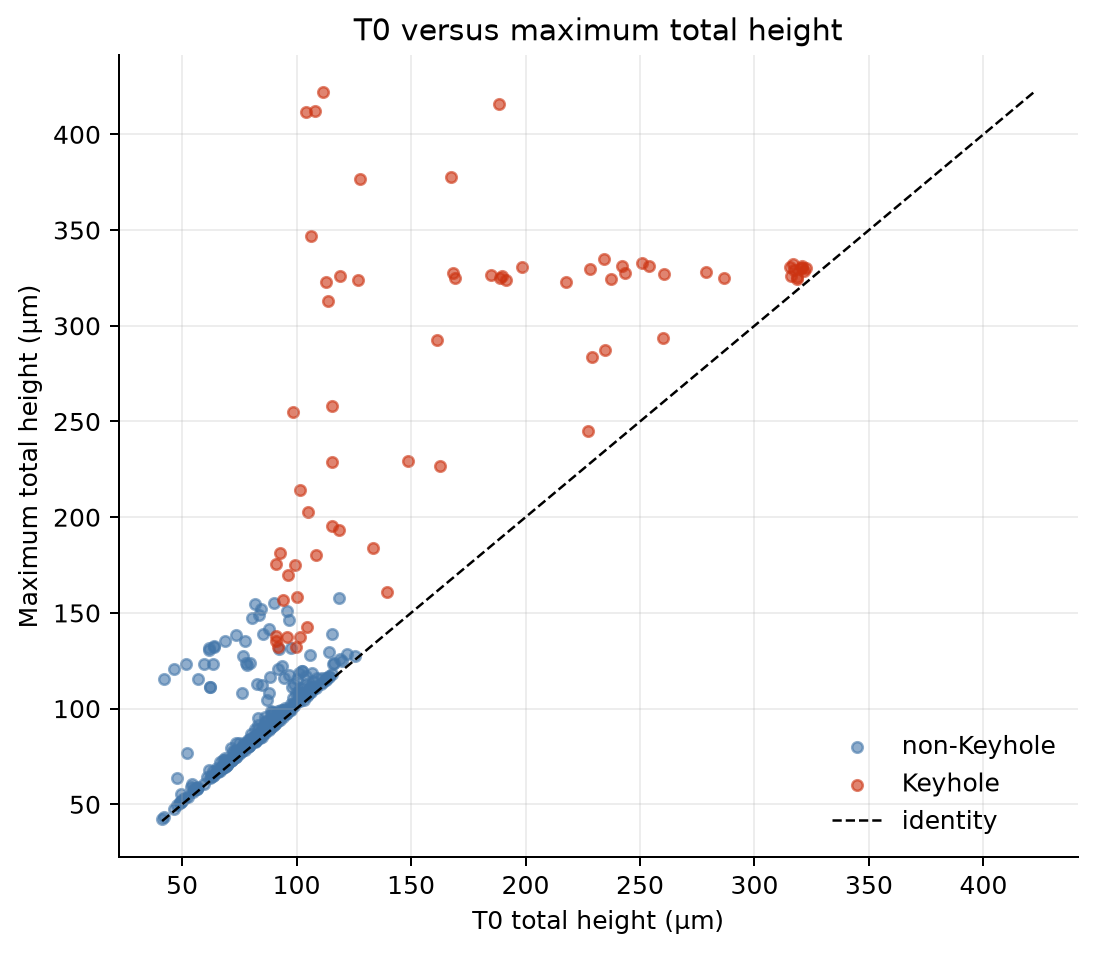

**09_T0_vs_max_kinetic_energy.png**

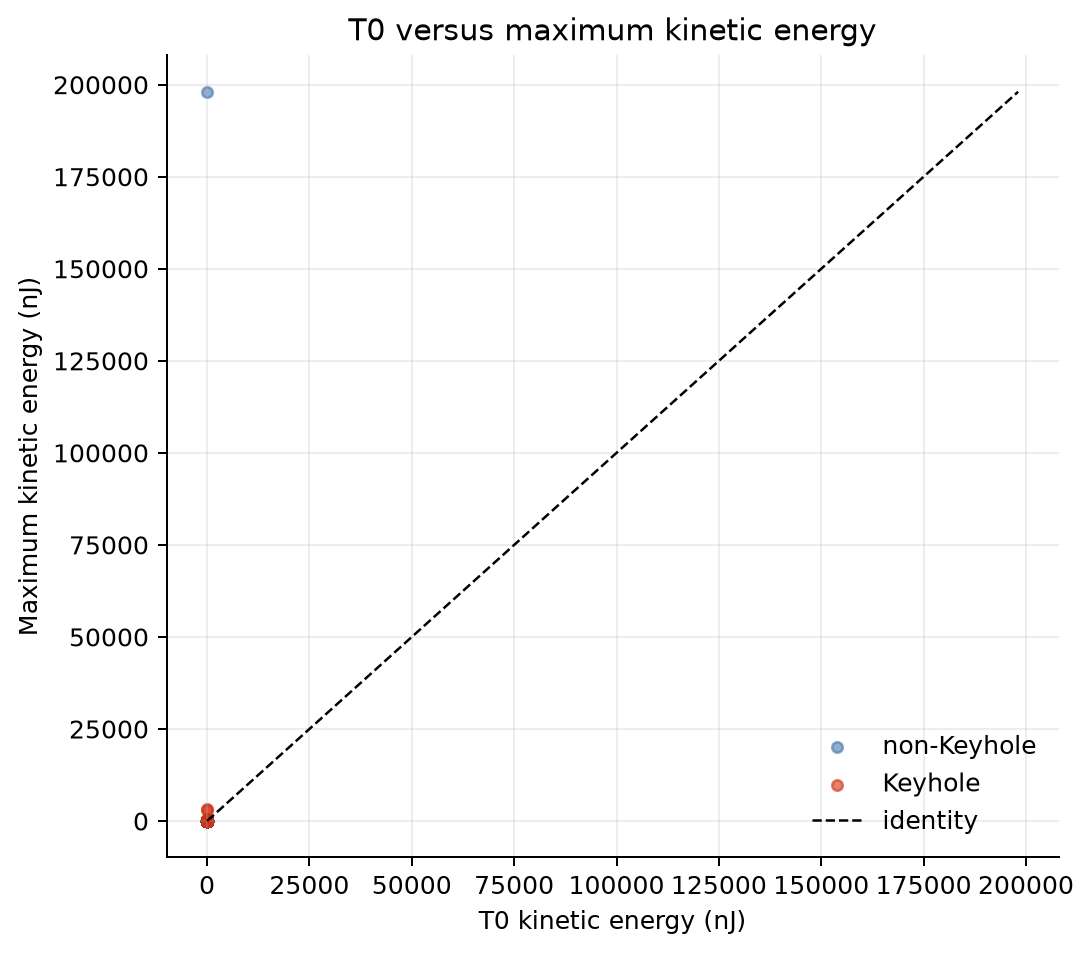

**10_keyhole_timing_relative_to_T0.png**

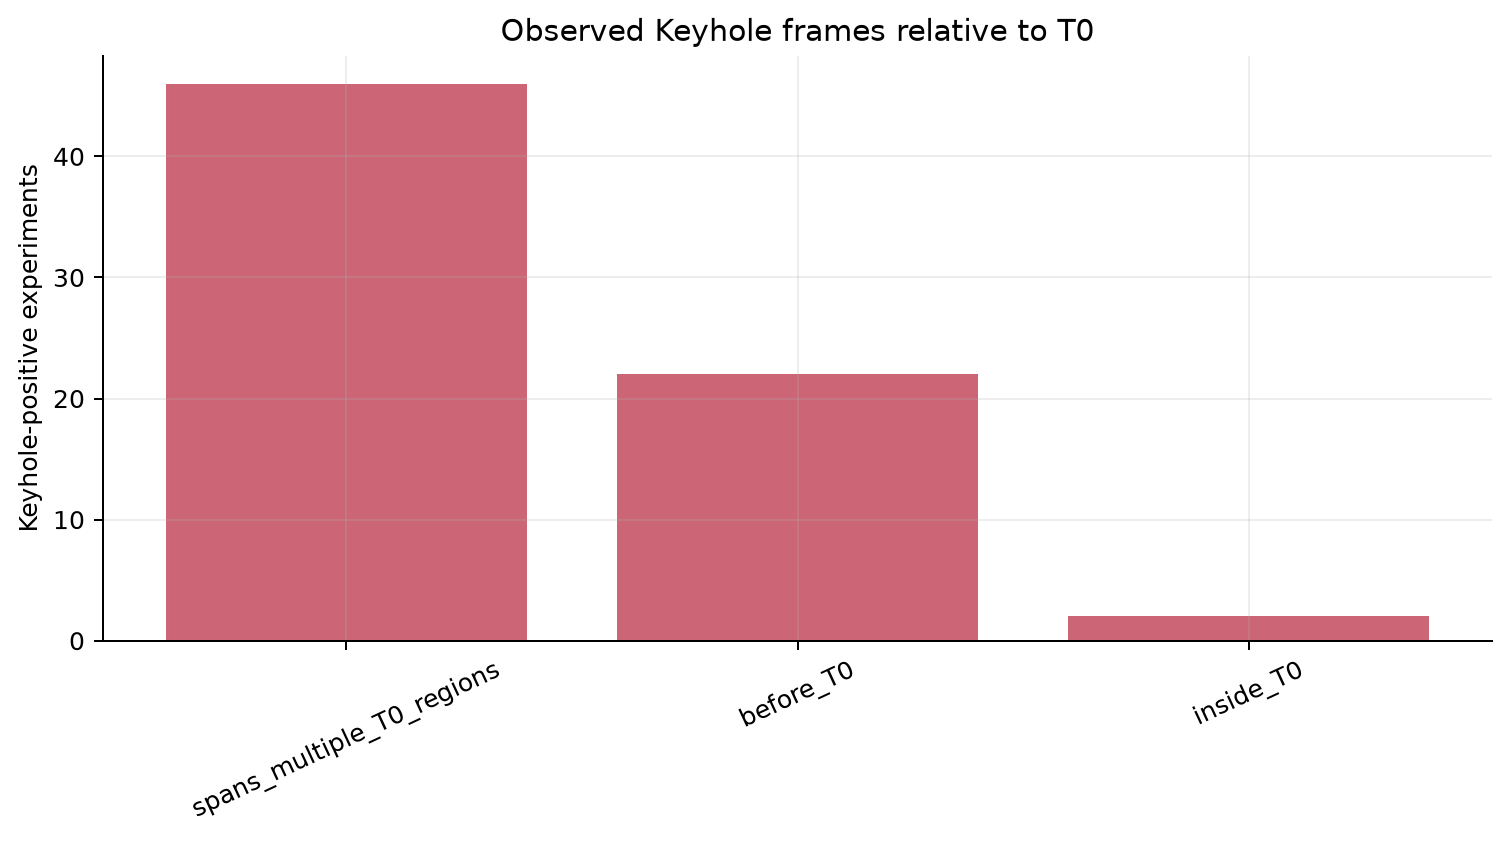

In [10]:
extreme = pd.read_csv(OUT / "t0_extreme_event_diagnostics.csv")
display(pd.DataFrame({
    "maximum depth location": ["before T0", "inside T0", "after T0"],
    "experiments": [
        int(extreme["max_depth_relative_to_T0"].eq("before_T0").sum()),
        int(extreme["max_depth_relative_to_T0"].eq("inside_T0").sum()),
        int(extreme["max_depth_relative_to_T0"].eq("after_T0").sum()),
    ],
}))
display(
    extreme[extreme["has_keyhole"]]["keyhole_timing_relative_to_T0"]
    .value_counts(dropna=False).rename("experiments").reset_index()
)
display(extreme[extreme["has_keyhole"]][[
    "experiment_name", "partition", "T0_depth_um", "max_depth_um",
    "max_depth_relative_to_T0", "keyhole_frames_before_T0",
    "keyhole_frames_inside_T0", "keyhole_frames_after_T0", "keyhole_overlaps_T0",
]].head(15))
for filename in [
    "07_T0_vs_max_penetration_depth.png",
    "08_T0_vs_max_total_height.png",
    "09_T0_vs_max_kinetic_energy.png",
    "10_keyhole_timing_relative_to_T0.png",
]:
    show_figure(filename)

**Interpretation.** Maximum depth occurs before T0 in **246/350 successful experiments (70.3%)**. Among **70 successful Keyhole-positive experiments**, **22 (31.4%)** have no stored Keyhole frame inside T0. This does **not** make T0 wrong: T0 and extrema answer different physical questions. It is evidence for a later target discussion, which is deliberately not made here.

## 10. Disconnected lower-region (“blue-dot”) diagnostic

**What are we doing?** Rank bounding-box depth spikes relative to persistent G3, fetch at most four side views at the pinned revision, and record a human visual review.  
**Why?** Bounding boxes cannot identify connected components; a deep disconnected lower particle can inflate maximum depth.  
**Question answered.** Do the most justified candidates visibly warrant later sensitivity analysis?  
**Suspicious result.** Assuming Week 6's old list applies, downloading all GIFs, or permanently excluding a case from one image.

,visual_review_rank,partition,experiment_name,has_keyhole,max_depth_um,T0_depth_um,G3_persistent_depth_um,max_depth_minus_G3_um,max_depth_over_G3,flag_depth_bounding_box_ambiguity_candidate,nearest_saved_frame_timestep,gif_path_in_repository,visual_review_status,visual_review_note,permanently_excluded
0,1.0,new-data,P-420p548248194_VX-0p890019823061_LS-4p2728397196e-05_ST-342p58191385_M-TI64_XI-0p0002_XF-0...,True,311.9998,86.40669,131.71315,180.28665,2.368782,True,109799.0,P-420p548248194_VX-0p890019823061_LS-4p2728397196e-05_ST-342p58191385_M-TI64_XI-0p0002_XF-0...,REVIEWED,The nearest saved side frame shows no clearly visible red melt component at the numerical m...,False
1,2.0,new-data,P-339p704237738_VX-0p701398887747_LS-5p24684299583e-05_ST-300p218383071_M-TI64_XI-0p0002_XF...,True,311.9999,85.48333,150.43270,161.56720,2.074016,True,110173.0,P-339p704237738_VX-0p701398887747_LS-5p24684299583e-05_ST-300p218383071_M-TI64_XI-0p0002_XF...,REVIEWED,The nearest saved side frame shows one continuous red melt region and no obvious detached l...,False
2,3.0,new-data,P-400p342090514_VX-0p84724542505_LS-4p08786684736e-05_ST-395p5494372_M-TI64_XI-0p0002_XF-0p...,True,311.9905,90.50685,151.18835,160.80215,2.063588,True,99040.0,P-400p342090514_VX-0p84724542505_LS-4p08786684736e-05_ST-395p5494372_M-TI64_XI-0p0002_XF-0p...,REVIEWED,The nearest saved side frame shows no clearly visible red melt component. The visual eviden...,False
3,4.0,old-data-local,P-140p119887795_VX-0p222892199661_LS-4p5e-05_ST-300_M-TI64_XI--0p0002_XF-0p0012_XL-0p0014_T...,True,182.7274,86.16420,78.00964,104.71776,2.342369,True,68329.0,P-140p119887795_VX-0p222892199661_LS-4p5e-05_ST-300_M-TI64_XI--0p0002_XF-0p0012_XL-0p0014_T...,REVIEWED,Two small colored components are clearly separated below the main red melt region in the ne...,False


**12_depth_visual_review_contact_sheet.png**

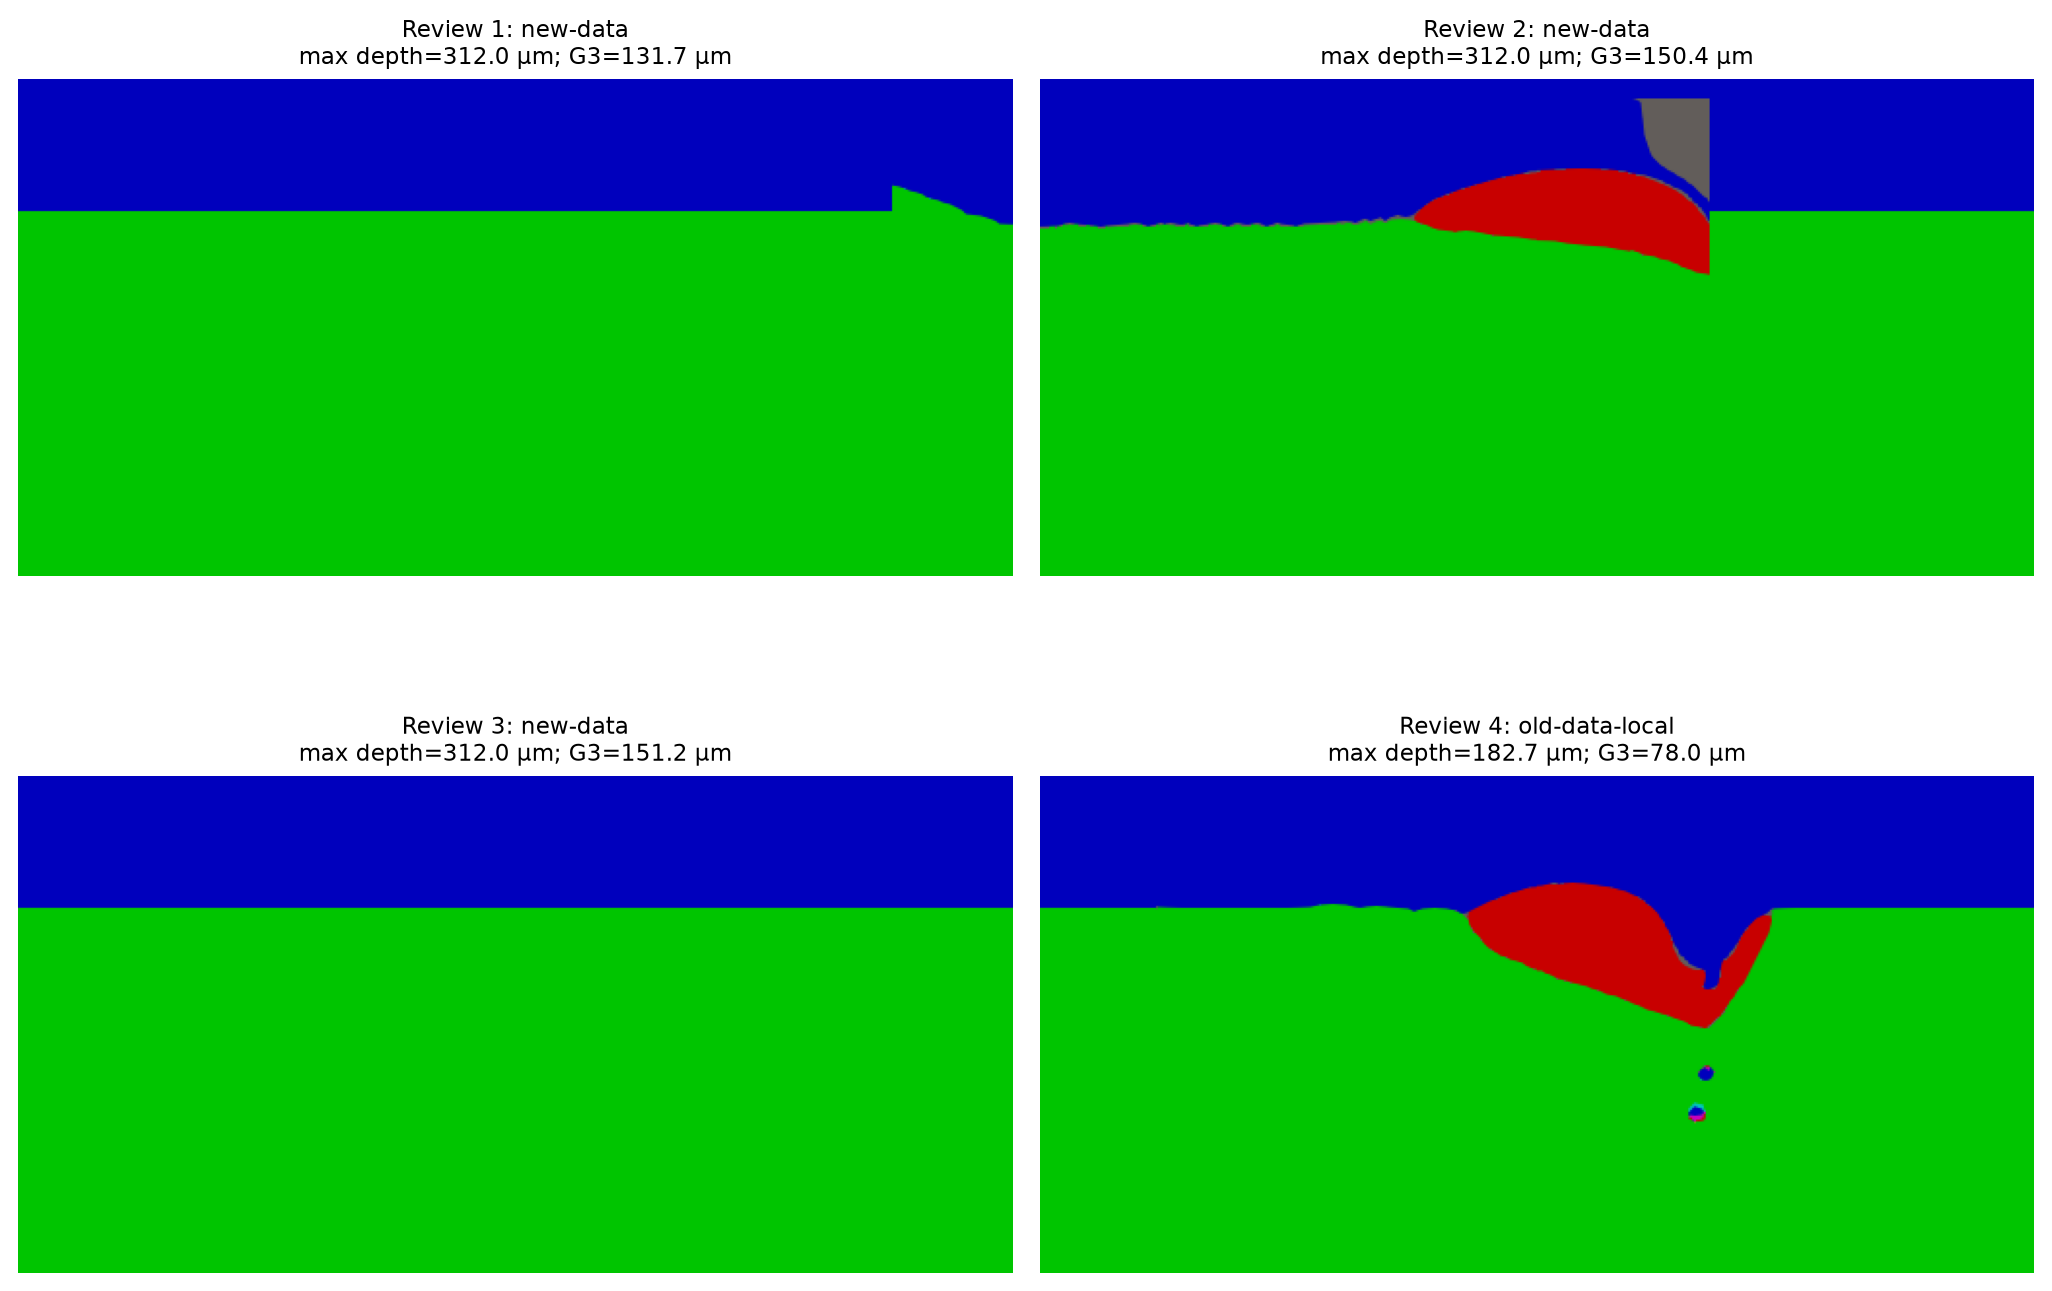

In [11]:
depth_flags = pd.read_csv(OUT / "flagged_depth_ambiguity.csv")
selected = depth_flags[depth_flags["selected_for_visual_review"]]
display(selected[[
    "visual_review_rank", "partition", "experiment_name", "has_keyhole",
    "max_depth_um", "T0_depth_um", "G3_persistent_depth_um",
    "max_depth_minus_G3_um", "max_depth_over_G3",
    "flag_depth_bounding_box_ambiguity_candidate", "nearest_saved_frame_timestep",
    "gif_path_in_repository", "visual_review_status", "visual_review_note",
    "permanently_excluded",
]])
show_figure("12_depth_visual_review_contact_sheet.png")

**Interpretation.** **8 experiments** meet the automatic spike-sensitive candidate rule; the audit selected only four ranked cases for visual inspection. **4** have completed review notes. These frames are evidence aids, not segmentation: the numerical monitor still cannot prove connectedness, and no experiment is excluded. The GIF paths remain linked for future sensitivity work.

## 11. Extraction failures and warnings

**What are we doing?** Display every failed or warning condition with experiment, partition, severity, and reason.  
**Why?** A scientifically conservative pipeline must preserve failures rather than dropping them before summary statistics.  
**Question answered.** Why is each non-successful row unusable or cautionary?  
**Suspicious result.** A mismatch between Phase 1 and Phase 2 populations, empty reasons, or unexplained row loss.

In [12]:
anomalies = pd.read_csv(OUT / "extraction_failure_anomalies.csv")
display(
    anomalies.groupby(["severity", "reason"])
    .agg(records=("experiment_name", "size"), experiments=("experiment_name", "nunique"))
    .reset_index().sort_values(["severity", "records"], ascending=[True, False])
)
display(anomalies)
display(targets[~targets["target_extraction_valid"]][[
    "partition", "experiment_name", "extraction_status", "extraction_failure_reasons",
    "source_label_modified", "simulation_silently_removed",
]])

,severity,reason,records,experiments
0,FAIL,extraction_failed,57,57
3,WARNING,recording_ends_before_90pct_domain,141,141
4,WARNING,week6_window_instability,16,16
1,WARNING,depth_bounding_box_ambiguity_candidate,8,8
2,WARNING,extraction_warning,1,1


,severity,reason,partition,experiment_name,week6_simulation_id,detail,source_data_removed
0,WARNING,recording_ends_before_90pct_domain,new-data,P-111p098510779_VX-0p492021331775_LS-4p80108469254e-05_ST-345p911753718_M-TI64_XI-0p0002_XF...,NaN,T0 ends at recording end under the exact Week 6 min rule,False
1,WARNING,recording_ends_before_90pct_domain,new-data,P-117p204089079_VX-0p299188895548_LS-6p61946140465e-05_ST-399p004242061_M-TI64_XI-0p0002_XF...,NaN,T0 ends at recording end under the exact Week 6 min rule,False
2,WARNING,recording_ends_before_90pct_domain,new-data,P-126p384227376_VX-0p205870034079_LS-4p55514058242e-05_ST-348p956388187_M-TI64_XI-0p0002_XF...,NaN,T0 ends at recording end under the exact Week 6 min rule,False
3,WARNING,recording_ends_before_90pct_domain,new-data,P-131p192514944_VX-0p432823544687_LS-6p72236683266e-05_ST-324p578264519_M-TI64_XI-0p0002_XF...,NaN,T0 ends at recording end under the exact Week 6 min rule,False
4,WARNING,recording_ends_before_90pct_domain,new-data,P-132p334528879_VX-0p441351904611_LS-8p05471929698e-05_ST-380p80221881_M-TI64_XI-0p0002_XF-...,NaN,T0 ends at recording end under the exact Week 6 min rule,False
...,...,...,...,...,...,...,...
218,WARNING,recording_ends_before_90pct_domain,old-data-remote-clean,P-228p907235932_VX-0p414638318501_LS-7p95917332413e-05_ST-340p25610662_M-TI64_XI-0p0002_XF-...,sim_00226,T0 ends at recording end under the exact Week 6 min rule,False
219,WARNING,recording_ends_before_90pct_domain,old-data-remote-clean,P-240p318887809_VX-0p361018894241_LS-4p85509578057e-05_ST-398p513006139_M-TI64_XI-0p0002_XF...,sim_00230,T0 ends at recording end under the exact Week 6 min rule,False
220,WARNING,recording_ends_before_90pct_domain,old-data-remote-clean,P-80p5741190929_VX-0p403249617425_LS-8p97039861056e-05_ST-397p637850573_M-TI64_XI-0p0002_XF...,sim_00236,T0 ends at recording end under the exact Week 6 min rule,False
221,WARNING,recording_ends_before_90pct_domain,old-data-remote-clean,P-91p4898167395_VX-0p477122889388_LS-7p769973149e-05_ST-351p010780102_M-TI64_XI-0p0002_XF-0...,sim_00237,T0 ends at recording end under the exact Week 6 min rule,False


,partition,experiment_name,extraction_status,extraction_failure_reasons,source_label_modified,simulation_silently_removed
44,new-data,P-204p165012598_VX-0p624752635414_LS-8p54709329997e-05_ST-334p626206985_M-TI64_XI-0p0002_XF...,FAIL,missing kinetic-energy_melt.dat; missing position-bounds_melt.dat,False,False
168,old-data-local,P-107p176159755_VX-0p320752066655_LS-8p75302281584e-05_ST-393p859643937_M-TI64_XI-0p0002_XF...,FAIL,missing kinetic-energy_melt.dat; missing time.dat,False,False
170,old-data-local,P-110p234671953_VX-0p866589137882_LS-8p08580037422e-05_ST-348p980680204_M-TI64_XI-0p0002_XF...,FAIL,missing kinetic-energy_melt.dat; missing time.dat,False,False
172,old-data-local,P-112p428225508_VX-0p704865651228_LS-6p30987392704e-05_ST-309p241492678_M-TI64_XI-0p0002_XF...,FAIL,missing kinetic-energy_melt.dat; missing time.dat,False,False
173,old-data-local,P-112p904894498_VX-0p537693260466_LS-4p63068354409e-05_ST-322p169166627_M-TI64_XI-0p0002_XF...,FAIL,missing kinetic-energy_melt.dat; missing time.dat,False,False
175,old-data-local,P-114p820217584_VX-0p948189613582_LS-6p03705790634e-05_ST-353p560035146_M-TI64_XI-0p0002_XF...,FAIL,missing kinetic-energy_melt.dat; missing time.dat,False,False
178,old-data-local,P-116p693370328_VX-0p231004403842_LS-8p2871053211e-05_ST-317p198938228_M-TI64_XI-0p0002_XF-...,FAIL,missing kinetic-energy_melt.dat; missing time.dat,False,False
180,old-data-local,P-119p65849417_VX-0p305673131798_LS-5p10692886867e-05_ST-393p327897391_M-TI64_XI-0p0002_XF-...,FAIL,missing kinetic-energy_melt.dat; missing time.dat,False,False
181,old-data-local,P-122p148440758_VX-0p768953415756_LS-4p5e-05_ST-300_M-TI64_XI--0p0002_XF-0p0012_XL-0p0014_T...,FAIL,missing kinetic-energy_melt.dat; missing time.dat,False,False
185,old-data-local,P-126p228008246_VX-0p201684842681_LS-4p5e-05_ST-300_M-TI64_XI--0p0002_XF-0p0012_XL-0p0014_T...,FAIL,missing kinetic-energy_melt.dat; missing time.dat,False,False


**Interpretation.** The **57 failures** correspond to missing pinned monitors or another explicitly recorded extraction condition; they are retained in both CSV and Parquet. Warning flags identify instability, early recording termination, unusual length behaviour, or depth-ambiguity candidates. No label is edited and no Phase 1 experiment disappears.

## 12. Did we satisfy Week 7 Phase 1 and Phase 2?

**What are we doing?** Display the automatic validation dashboard and every requested-item mapping.  
**Why?** Deliverable completeness, implementation correctness, and upstream data caveats are different questions.  
**Question answered.** Which checks pass, warn, or fail, and where is the evidence?  
**Suspicious result.** A blanket PASS that hides missing files, a notebook with stored errors, or evidence that modelling began.

In [13]:
validation = pd.read_csv(OUT / "validation_results.csv")
checklist = pd.read_csv(OUT / "phase2_requirement_checklist.csv")
phase1_validation_path = P1 / "validation_results.csv"
phase1_checklist_path = P1 / "phase1_requirement_checklist.csv"
display(Markdown("### Phase 1 validation and requested-item checklist"))
if phase1_validation_path.exists() and phase1_checklist_path.exists():
    display(pd.read_csv(phase1_validation_path))
    display(pd.read_csv(phase1_checklist_path))
else:
    missing_reports = [
        path.name for path in [phase1_validation_path, phase1_checklist_path]
        if not path.exists()
    ]
    display(Markdown(
        "The Phase 1 summary is present and supplies the pinned revision and experiment count, "
        f"but these local Phase 1 reporting files are absent: `{', '.join(missing_reports)}`. "
        "They are reported as unavailable here and were not regenerated during this targeted Phase 2 correction."
    ))
    display(pd.DataFrame({
        "Phase 1 summary field": ["revision", "experiment_count"],
        "value": [phase1["revision"], phase1["experiment_count"]],
    }))
display(Markdown("### Phase 2 validation and requested-item checklist"))
display(validation)
display(validation.groupby("status").size().rename("count").reset_index())
display(checklist)
assert summary["scope"]["models_fitted"] is False
assert summary["scope"]["active_learning"] is False
assert summary["scope"]["level_set_estimation"] is False
assert targets["source_label_modified"].eq(False).all()
assert targets["simulation_silently_removed"].eq(False).all()

### Phase 1 validation and requested-item checklist

The Phase 1 summary is present and supplies the pinned revision and experiment count, but these local Phase 1 reporting files are absent: `validation_results.csv`. They are reported as unavailable here and were not regenerated during this targeted Phase 2 correction.

,Phase 1 summary field,value
0,revision,d69dac5bda8b622bc0de316b112815c6056c06ec
1,experiment_count,407


### Phase 2 validation and requested-item checklist

,validation_id,requirement,status,detail
0,V01,Exact sph_v2 revision recorded on every row,PASS,d69dac5bda8b622bc0de316b112815c6056c06ec
1,V02,One target row retained per Phase 1 experiment,PASS,targets=407; labels=407
2,V03,All P/VX/LS/ST finite,PASS,all target-table input fields checked
3,V04,Every required monitor exists,WARNING,missing monitor rows=114
4,V05,All present monitor bytes match pinned Git blobs,PASS,verified=1514/1514
5,V06,All present monitor schemas compatible,PASS,compatible=1514/1514
6,V07,Every extraction failure is retained explicitly,PASS,invalid rows retained=57
7,V08,Targets finite where extraction succeeds,PASS,valid rows=350
8,V09,Physical dimensions and energy non-negative,PASS,width/depth/height/energy checked
9,V10,Total height >= penetration depth where observed melt crosses surface,PASS,violations=0


,status,count
0,PASS,29
1,WARNING,1


,requirement_id,requirement,status,notebook_section,output_artifact,validation_ids
0,P2-01,Exact Week 6 definitions traced to executable sources,PASS,Notebook §2,week6_definition_traceability.csv,V14
1,P2-02,"Monitor existence, schema, rows, units and invalid values audited",WARNING,Notebook §3,monitor_schema_compatibility.csv,V04;V05;V06
2,P2-03,Smallest domain compatibility layer verified on exact matches,PASS,Notebook §3,domain_mapping_compatibility.csv,V14
3,P2-04,Active region and T0 reconstructed without redefining T0,WARNING,Notebook §4,active_region_diagnostics.csv,V04;V07;V12;V13
4,P2-05,"Representative normal, edge and suspicious time series plotted",PASS,Notebook §5,representative_simulation_selection.csv; figures/representative_*.png,V08
5,P2-06,One-row-per-simulation target table saved as CSV and Parquet,PASS,Notebook §6,sph_v2_simulation_level_targets.csv; sph_v2_simulation_level_targets.parquet,V02;V07;V17
6,P2-07,Width/depth/height/kinetic T0 and maximum responses retained,PASS,Notebook §6,sph_v2_simulation_level_targets.csv,V08;V09;V11
7,P2-08,"Length retained as diagnostic, not promoted to primary target",PASS,Notebook §6,sph_v2_simulation_level_targets.csv,V08
8,P2-09,Exact old/new matches compared without fuzzy matching,PASS,Notebook §7,week6_exact_identifier_map.csv; exact_old_new_target_comparison.csv,V15
9,P2-10,"Target distributions audited overall, by partition and Keyhole",PASS,Notebook §8,target_distribution_summary.csv; figures/03_*.png–06_*.png,V08;V09


**Interpretation and hard stop.** The Week 6 semantics transfer exactly wherever `sph_v2` supplies the required monitors; missing upstream inputs remain explicit warnings/failures rather than being repaired from another dataset. The count/units/window/old-match/no-removal guards are automatic. Phase 2 ends here—no model, classifier, active-learning acquisition, level-set estimate, or final target selection has been started.